In [ ]:
 Esto reinicia el entorno de ejecución desde la celda
import os
os._exit(00)


In [ ]:
!pip install xarray cfgrib cartopy geopandas pandas matplotlib --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.1/56.1 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.1/49.1 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 34.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.6/91.6 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 38.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 50.0 MB/s eta 0:00:00


In [ ]:
!pip install rasterio
!pip install folium requests

In [ ]:
!apt-get install -y libeccodes-dev

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  libeccodes-data libeccodes0
The following NEW packages will be installed:
  libeccodes-data libeccodes-dev libeccodes0
0 upgraded, 3 newly installed, 0 to remove and 3 not upgraded.
Need to get 3,076 kB of archives.
After this operation, 60.8 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 libeccodes-data all 2.24.2-1 [1,592 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/universe amd64 libeccodes0 amd64 2.24.2-1 [614 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy/universe amd64 libeccodes-dev amd64 2.24.2-1 [870 kB]
Fetched 3,076 kB in 0s (31.7 MB/s)
Selecting previously unselected package libeccodes-data.
(Reading database ... 118251 files and directories currently installed.)
Preparing to unpack .../libeccodes-data_2.24.2-1_all.deb ...
Unpacking libeccodes-data (2.24.2-1) ...
S

In [ ]:
pip install ecmwf-opendata


In [ ]:
pip install s3fs

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.4/203.4 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.5/89.5 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.0/15.0 MB 82.3 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.0
    Uninstalling fsspec-2025.3.0:
      Successfully uninstalled fsspec-2025.3.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2026.4.0 which is incompatible.
datasets 4.0.0 requires fsspec[http]<=2025.3.0,>=2023.1.0, but you have fsspec 2026.4.0 which is incompatible.


In [ ]:
#conectando al drive
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import urllib.request
import xarray as xr
import os
import numpy as np
from ecmwf.opendata import Client
import s3fs
from datetime import datetime, timedelta

class MultiModeloMeteorologico:
    """
    Clase para descargar y cargar datos de múltiples modelos meteorológicos.
    Soporta: GFS, GFS-IA (GraphCast), ECMWF IFS y ECMWF AIFS
    """

    def __init__(self):
        self.fecha = None
        self.corrida = None
        self.acumulado = None
        self.lead_time = None
        self.datos = {}
        self.carpeta_base = "./datos_modelos"
        os.makedirs(self.carpeta_base, exist_ok=True)

    def configurar(self, fecha=None, corrida=None, acumulado=None):
        """
        Configura los parámetros de descarga

        Args:
            fecha: str en formato YYYYMMDD (ej: '20251016')
            corrida: str hora de corrida '00', '06', '12', '18'
            acumulado: str '12h', '24h', '5d' o rango personalizado 'f024-f036'
        """
        # Si no se proporcionan parámetros, preguntar interactivamente
        if fecha is None:
            fecha = input("Ingrese la fecha (YYYYMMDD, ej: 20251016): ").strip()

        if corrida is None:
            print("\nCorridas disponibles: 00, 06, 12, 18")
            corrida = input("Ingrese la hora de corrida (00/06/12/18): ").strip()

        if acumulado is None:
            print("\nAcumulados disponibles:")
            print("  12h - Acumulado de 12 horas")
            print("  24h - Acumulado de 24 horas")
            print("  5d  - Acumulado de 5 días (120 horas)")
            print("  Personalizado: f024-f036 (acumulado entre hora 24 y 36)")
            acumulado = input("Ingrese el acumulado deseado (12h/24h/5d/f###-f###): ").strip().lower()

        # Validaciones
        if len(fecha) != 8 or not fecha.isdigit():
            raise ValueError("Fecha debe estar en formato YYYYMMDD")

        if corrida not in ['00', '06', '12', '18']:
            raise ValueError("Corrida debe ser 00, 06, 12 o 18")

        self.fecha = fecha
        self.corrida = corrida
        self.acumulado = acumulado

        # Parsear el acumulado
        self.es_rango = False

        if acumulado in ['12h', '24h', '5d']:
            # Acumulados fijos (desde inicio)
            if acumulado == '12h':
                self.lead_time = 12
                self.step_range = "0-12"
                self.hora_inicio = 0
                self.hora_fin = 12
            elif acumulado == '24h':
                self.lead_time = 24
                self.step_range = "0-24"
                self.hora_inicio = 0
                self.hora_fin = 24
            elif acumulado == '5d':
                self.lead_time = 120
                self.step_range = "0-120"
                self.hora_inicio = 0
                self.hora_fin = 120
        else:
            # Rango personalizado: f024-f036
            import re
            match = re.match(r'f(\d+)-f(\d+)', acumulado)
            if not match:
                raise ValueError("Acumulado debe ser 12h, 24h, 5d o formato f###-f### (ej: f024-f036)")

            self.hora_inicio = int(match.group(1))
            self.hora_fin = int(match.group(2))

            if self.hora_inicio >= self.hora_fin:
                raise ValueError("La hora final debe ser mayor que la hora inicial")

            self.es_rango = True
            self.lead_time = self.hora_fin  # Para compatibilidad
            self.step_range = f"{self.hora_inicio}-{self.hora_fin}"

        print(f"\n✅ Configuración:")
        print(f"   Fecha: {self.fecha}")
        print(f"   Corrida: {self.corrida}Z")
        if self.es_rango:
            print(f"   Acumulado: {self.acumulado} (horas {self.hora_inicio}-{self.hora_fin})")
        else:
            print(f"   Acumulado: {self.acumulado} ({self.lead_time}h)")

    def descargar_gfs(self):
        """Descarga datos del modelo GFS"""
        print(f"\n🌍 Descargando GFS...")

        carpeta_gfs = os.path.join(self.carpeta_base, "gfs")
        os.makedirs(carpeta_gfs, exist_ok=True)

        base_url = f"https://nomads.ncep.noaa.gov/pub/data/nccf/com/gfs/prod/gfs.{self.fecha}/{self.corrida}/atmos/"

        if self.es_rango:
            # GFS almacena acumulados desde el inicio (0-N horas)
            # Para obtener un intervalo, necesitamos restar dos archivos
            archivo_fin = f"gfs_{self.acumulado}_{self.fecha}_{self.corrida}z_f{self.hora_fin:03d}.grib2"
            archivo_inicio = f"gfs_{self.acumulado}_{self.fecha}_{self.corrida}z_f{self.hora_inicio:03d}.grib2"

            ruta_fin = os.path.join(carpeta_gfs, archivo_fin)
            ruta_inicio = os.path.join(carpeta_gfs, archivo_inicio)

            # Descargar archivo final
            if not os.path.exists(ruta_fin):
                url = base_url + f"gfs.t{self.corrida}z.pgrb2.0p25.f{self.hora_fin:03d}"
                headers = {"User-Agent": "Mozilla/5.0"}
                req = urllib.request.Request(url, headers=headers)
                with urllib.request.urlopen(req) as response:
                    with open(ruta_fin, "wb") as f:
                        f.write(response.read())
                print(f"   ✔ Descargado: {archivo_fin}")
            else:
                print(f"   ✔ Ya existe: {archivo_fin}")

            # Cargar archivo final - buscar mensaje con acumulado desde inicio (0-N)
            ds_fin = xr.open_dataset(
                ruta_fin,
                engine="cfgrib",
                backend_kwargs={
                    "filter_by_keys": {
                        "typeOfLevel": "surface",
                        "stepType": "accum",
                        "stepRange": f"0-{self.hora_fin}"
                    },
                    "indexpath": ""
                }
            )

            # Descargar y cargar archivo inicio
            if self.hora_inicio > 0:
                if not os.path.exists(ruta_inicio):
                    url = base_url + f"gfs.t{self.corrida}z.pgrb2.0p25.f{self.hora_inicio:03d}"
                    headers = {"User-Agent": "Mozilla/5.0"}
                    req = urllib.request.Request(url, headers=headers)
                    with urllib.request.urlopen(req) as response:
                        with open(ruta_inicio, "wb") as f:
                            f.write(response.read())
                    print(f"   ✔ Descargado: {archivo_inicio}")
                else:
                    print(f"   ✔ Ya existe: {archivo_inicio}")

                ds_inicio = xr.open_dataset(
                    ruta_inicio,
                    engine="cfgrib",
                    backend_kwargs={
                        "filter_by_keys": {
                            "typeOfLevel": "surface",
                            "stepType": "accum",
                            "stepRange": f"0-{self.hora_inicio}"
                        },
                        "indexpath": ""
                    }
                )

                # Hacer la resta para obtener el intervalo
                precip = ds_fin['tp'].values - ds_inicio['tp'].values
                ds = ds_fin
            else:
                precip = ds_fin['tp'].values
                ds = ds_fin

        else:
            # Acumulado fijo (comportamiento original)
            archivo_original = f"gfs.t{self.corrida}z.pgrb2.0p25.f{self.lead_time:03d}"
            archivo = f"gfs_{self.acumulado}_{self.fecha}_{self.corrida}z.grib2"
            url = base_url + archivo_original
            ruta_local = os.path.join(carpeta_gfs, archivo)

            if not os.path.exists(ruta_local):
                headers = {"User-Agent": "Mozilla/5.0"}
                req = urllib.request.Request(url, headers=headers)
                with urllib.request.urlopen(req) as response:
                    data_bytes = response.read()
                with open(ruta_local, "wb") as f:
                    f.write(data_bytes)
                print(f"   ✔ Descargado: {archivo}")
            else:
                print(f"   ✔ Ya existe: {archivo}")

            ds = xr.open_dataset(
                ruta_local,
                engine="cfgrib",
                backend_kwargs={
                    "filter_by_keys": {
                        "typeOfLevel": "surface",
                        "stepType": "accum",
                        "stepRange": self.step_range
                    },
                    "indexpath": ""
                }
            )
            precip = ds['tp'].values

        self.datos['gfs'] = {
            'dataset': ds,
            'precipitacion': precip,
            'max_precip': np.max(precip),
            'lat': ds['latitude'].values,
            'lon': ds['longitude'].values
        }

        print(f"   📊 Precip. máxima: {self.datos['gfs']['max_precip']:.2f} mm")




    def descargar_ecmwf_ifs(self):
        """Descarga datos del modelo ECMWF IFS (físico)"""
        print(f"\n🇪🇺 Descargando ECMWF IFS (Físico)...")

        carpeta_ifs = os.path.join(self.carpeta_base, "ecmwf_ifs")
        os.makedirs(carpeta_ifs, exist_ok=True)

        client = Client(source="ecmwf")

        if self.es_rango:
            archivo_fin = f"ifs_{self.acumulado}_{self.fecha}_{self.corrida}z_f{self.hora_fin:03d}.grib"
            archivo_inicio = f"ifs_{self.acumulado}_{self.fecha}_{self.corrida}z_f{self.hora_inicio:03d}.grib"

            ruta_fin = os.path.join(carpeta_ifs, archivo_fin)
            ruta_inicio = os.path.join(carpeta_ifs, archivo_inicio)

            # Descargar archivo final
            if not os.path.exists(ruta_fin):
                client.retrieve(
                    date=self.fecha,
                    time=int(self.corrida),
                    step=self.hora_fin,
                    param="tp",
                    stream="oper",
                    target=ruta_fin
                )
                print(f"   ✔ Descargado: {archivo_fin}")
            else:
                print(f"   ✔ Ya existe: {archivo_fin}")

            # Descargar archivo inicio
            if self.hora_inicio > 0:
                if not os.path.exists(ruta_inicio):
                    client.retrieve(
                        date=self.fecha,
                        time=int(self.corrida),
                        step=self.hora_inicio,
                        param="tp",
                        stream="oper",
                        target=ruta_inicio
                    )
                    print(f"   ✔ Descargado: {archivo_inicio}")
                else:
                    print(f"   ✔ Ya existe: {archivo_inicio}")

                # Cargar y restar
                ds_fin = xr.open_dataset(ruta_fin, engine="cfgrib",
                                       backend_kwargs={"filter_by_keys": {"typeOfLevel": "surface", "stepType": "accum"}, "indexpath": ""})
                ds_inicio = xr.open_dataset(ruta_inicio, engine="cfgrib",
                                           backend_kwargs={"filter_by_keys": {"typeOfLevel": "surface", "stepType": "accum"}, "indexpath": ""})

                precip_mm = (ds_fin['tp'].values - ds_inicio['tp'].values) * 1000  # metros a mm
                ds = ds_fin
            else:
                ds = xr.open_dataset(ruta_fin, engine="cfgrib",
                                   backend_kwargs={"filter_by_keys": {"typeOfLevel": "surface", "stepType": "accum"}, "indexpath": ""})
                precip_mm = ds['tp'].values * 1000
        else:
            # Comportamiento original
            archivo = f"ifs_{self.acumulado}_{self.fecha}_{self.corrida}z.grib"
            ruta_local = os.path.join(carpeta_ifs, archivo)

            if not os.path.exists(ruta_local):
                client.retrieve(
                    date=self.fecha,
                    time=int(self.corrida),
                    step=self.lead_time,
                    param="tp",
                    stream="oper",
                    target=ruta_local
                )
                print(f"   ✔ Descargado: {archivo}")
            else:
                print(f"   ✔ Ya existe: {archivo}")

            # Cargar datos
            ds = xr.open_dataset(
                ruta_local,
                engine="cfgrib",
                backend_kwargs={
                    "filter_by_keys": {
                        "typeOfLevel": "surface",
                        "stepType": "accum"
                    },
                    "indexpath": ""
                }
            )

            precip_mm = ds['tp'].values * 1000  # metros a mm

        self.datos['ecmwf_ifs'] = {
            'dataset': ds,
            'precipitacion': precip_mm,
            'max_precip': np.max(precip_mm),
            'lat': ds['latitude'].values,
            'lon': ds['longitude'].values
        }

        print(f"   📊 Precip. máxima: {self.datos['ecmwf_ifs']['max_precip']:.2f} mm")

    def descargar_ecmwf_aifs(self):
        """Descarga datos del modelo ECMWF AIFS (IA)"""
        print(f"\n🤖 Descargando ECMWF AIFS (IA)...")

        carpeta_aifs = os.path.join(self.carpeta_base, "ecmwf_aifs")
        os.makedirs(carpeta_aifs, exist_ok=True)

        client = Client(source="ecmwf", model="aifs-single")

        if self.es_rango:
            archivo_fin = f"aifs_{self.acumulado}_{self.fecha}_{self.corrida}z_f{self.hora_fin:03d}.grib"
            archivo_inicio = f"aifs_{self.acumulado}_{self.fecha}_{self.corrida}z_f{self.hora_inicio:03d}.grib"

            ruta_fin = os.path.join(carpeta_aifs, archivo_fin)
            ruta_inicio = os.path.join(carpeta_aifs, archivo_inicio)

            # Descargar archivo final
            if not os.path.exists(ruta_fin):
                client.retrieve(
                    date=self.fecha,
                    time=int(self.corrida),
                    step=self.hora_fin,
                    type="fc",
                    param="tp",
                    target=ruta_fin
                )
                print(f"   ✔ Descargado: {archivo_fin}")
            else:
                print(f"   ✔ Ya existe: {archivo_fin}")

            # Descargar archivo inicio
            if self.hora_inicio > 0:
                if not os.path.exists(ruta_inicio):
                    client.retrieve(
                        date=self.fecha,
                        time=int(self.corrida),
                        step=self.hora_inicio,
                        type="fc",
                        param="tp",
                        target=ruta_inicio
                    )
                    print(f"   ✔ Descargado: {archivo_inicio}")
                else:
                    print(f"   ✔ Ya existe: {archivo_inicio}")

                # Cargar y restar
                ds_fin = xr.open_dataset(ruta_fin, engine="cfgrib",
                                       backend_kwargs={"filter_by_keys": {"typeOfLevel": "surface", "stepType": "accum"}, "indexpath": ""})
                ds_inicio = xr.open_dataset(ruta_inicio, engine="cfgrib",
                                           backend_kwargs={"filter_by_keys": {"typeOfLevel": "surface", "stepType": "accum"}, "indexpath": ""})

                precip = ds_fin['tp'].values - ds_inicio['tp'].values
                ds = ds_fin
            else:
                ds = xr.open_dataset(ruta_fin, engine="cfgrib",
                                   backend_kwargs={"filter_by_keys": {"typeOfLevel": "surface", "stepType": "accum"}, "indexpath": ""})
                precip = ds['tp'].values
        else:
            # Comportamiento original
            archivo = f"aifs_{self.acumulado}_{self.fecha}_{self.corrida}z.grib"
            ruta_local = os.path.join(carpeta_aifs, archivo)

            if not os.path.exists(ruta_local):
                client.retrieve(
                    date=self.fecha,
                    time=int(self.corrida),
                    step=self.lead_time,
                    type="fc",
                    param="tp",
                    target=ruta_local
                )
                print(f"   ✔ Descargado: {archivo}")
            else:
                print(f"   ✔ Ya existe: {archivo}")

            # Cargar datos
            ds = xr.open_dataset(
                ruta_local,
                engine="cfgrib",
                backend_kwargs={
                    "filter_by_keys": {
                        "typeOfLevel": "surface",
                        "stepType": "accum"
                    },
                    "indexpath": ""
                }
            )
            precip = ds['tp'].values

        self.datos['ecmwf_aifs'] = {
            'dataset': ds,
            'precipitacion': precip,
            'max_precip': np.max(precip),
            'lat': ds['latitude'].values,
            'lon': ds['longitude'].values
        }

        print(f"   📊 Precip. máxima: {self.datos['ecmwf_aifs']['max_precip']:.2f} mm")

    def descargar_gfs_graphcast(self):
        """Descarga datos del modelo GFS-GraphCast (IA)"""
        print(f"\n🤖 Descargando GFS-GraphCast (IA)...")

        carpeta_graphcast = os.path.join(self.carpeta_base, "gfs_graphcast")
        os.makedirs(carpeta_graphcast, exist_ok=True)

        fs = s3fs.S3FileSystem(anon=True)

        if self.es_rango:
            # Para GraphCast, cada archivo ya contiene el acumulado del período específico
            archivo = f"graphcast_{self.acumulado}_{self.fecha}_{self.corrida}z.grib2"
            ruta_local = os.path.join(carpeta_graphcast, archivo)

            if not os.path.exists(ruta_local):
                file_path = f'noaa-nws-graphcastgfs-pds/graphcastgfs.{self.fecha}/{self.corrida}/forecasts_13_levels/graphcastgfs.t{self.corrida}z.pgrb2.0p25.f{self.hora_fin:03d}'
                with fs.open(file_path, 'rb') as fsrc:
                    with open(ruta_local, 'wb') as fdst:
                        fdst.write(fsrc.read())
                print(f"   ✔ Descargado: {archivo}")
            else:
                print(f"   ✔ Ya existe: {archivo}")

            # Cargar datos
            ds = xr.open_dataset(
                ruta_local,
                engine='cfgrib',
                backend_kwargs={
                    "filter_by_keys": {
                        "typeOfLevel": "surface",
                        "stepType": "accum",
                        "shortName": "tp"
                    },
                    "indexpath": ""
                }
            )
            precip = ds['tp'].values

        else:
            # Comportamiento original
            archivo = f"graphcast_{self.acumulado}_{self.fecha}_{self.corrida}z.grib2"
            ruta_local = os.path.join(carpeta_graphcast, archivo)

            if not os.path.exists(ruta_local):
                file_path = f'noaa-nws-graphcastgfs-pds/graphcastgfs.{self.fecha}/{self.corrida}/forecasts_13_levels/graphcastgfs.t{self.corrida}z.pgrb2.0p25.f{self.lead_time:03d}'

                with fs.open(file_path, 'rb') as fsrc:
                    with open(ruta_local, 'wb') as fdst:
                        fdst.write(fsrc.read())
                print(f"   ✔ Descargado: {archivo}")
            else:
                print(f"   ✔ Ya existe: {archivo}")

            # Cargar datos
            ds = xr.open_dataset(
                ruta_local,
                engine='cfgrib',
                backend_kwargs={
                    "filter_by_keys": {
                        "typeOfLevel": "surface",
                        "stepType": "accum",
                        "shortName": "tp"
                    },
                    "indexpath": ""
                }
            )
            precip = ds['tp'].values

        self.datos['gfs_graphcast'] = {
            'dataset': ds,
            'precipitacion': precip,
            'max_precip': np.max(precip),
            'lat': ds['latitude'].values,
            'lon': ds['longitude'].values
        }

        print(f"   📊 Precip. máxima: {self.datos['gfs_graphcast']['max_precip']:.2f} mm")

    def cargar_todos_los_modelos(self):
        """Descarga y carga todos los modelos configurados"""
        if self.fecha is None or self.corrida is None or self.acumulado is None:
            raise ValueError("Debe configurar la clase primero usando configurar()")

        print("\n" + "="*60)
        print("🚀 INICIANDO DESCARGA DE TODOS LOS MODELOS")
        print("="*60)

        try:
            self.descargar_gfs()
        except Exception as e:
            print(f"   ❌ Error en GFS: {e}")

        try:
            self.descargar_ecmwf_ifs()
        except Exception as e:
            print(f"   ❌ Error en ECMWF IFS: {e}")

        try:
            self.descargar_ecmwf_aifs()
        except Exception as e:
            print(f"   ❌ Error en ECMWF AIFS: {e}")

        try:
            self.descargar_gfs_graphcast()
        except Exception as e:
            print(f"   ❌ Error en GFS-GraphCast: {e}")

        print("\n" + "="*60)
        print("✅ DESCARGA COMPLETADA")
        print("="*60)
        self.mostrar_resumen()

    def mostrar_resumen(self):
        """Muestra un resumen de los datos cargados"""
        print(f"\n📋 RESUMEN DE DATOS CARGADOS:")
        print(f"   Fecha: {self.fecha}")
        print(f"   Corrida: {self.corrida}Z")
        print(f"   Acumulado: {self.acumulado}")
        print(f"\n   Modelos cargados: {len(self.datos)}")

        for modelo, datos in self.datos.items():
            print(f"\n   🔹 {modelo.upper()}:")
            print(f"      Max precip: {datos['max_precip']:.2f} mm")
            print(f"      Shape: {datos['precipitacion'].shape}")

    def obtener_precipitacion(self, modelo):
        """
        Obtiene la precipitación de un modelo específico

        Args:
            modelo: str - 'gfs', 'ecmwf_ifs', 'ecmwf_aifs', 'gfs_graphcast'

        Returns:
            numpy array con valores de precipitación en mm
        """
        if modelo not in self.datos:
            raise ValueError(f"Modelo '{modelo}' no cargado. Modelos disponibles: {list(self.datos.keys())}")

        return self.datos[modelo]['precipitacion']

    def obtener_coordenadas(self, modelo):
        """Obtiene las coordenadas (lat, lon) de un modelo"""
        if modelo not in self.datos:
            raise ValueError(f"Modelo '{modelo}' no cargado")

        return self.datos[modelo]['lat'], self.datos[modelo]['lon']

    def obtener_dataset(self, modelo):
        """Obtiene el dataset completo de xarray de un modelo"""
        if modelo not in self.datos:
            raise ValueError(f"Modelo '{modelo}' no cargado")

        return self.datos[modelo]['dataset']

    def _interpolar_a_rejilla_comun(self, modelo_key, lon_common, lat_common):
        """
        Interpola los datos de precipitación de un modelo a la rejilla común.
        Usa directamente los datos ya procesados en self.datos
        """
        from scipy.interpolate import RegularGridInterpolator

        # Obtener datos ya procesados (en mm)
        precip_orig_mm = self.datos[modelo_key]['precipitacion']
        lat_orig = self.datos[modelo_key]['lat']
        lon_orig = self.datos[modelo_key]['lon']

        # Extraer datos si tienen dimensión temporal
        if precip_orig_mm.ndim == 3:
            precip_orig_mm = precip_orig_mm[0, :, :]

        # Convertir longitudes 0-360 a -180-180 si es necesario
        if lon_orig.min() >= 0 and lon_orig.max() > 180:
            lon_orig_converted = np.where(lon_orig > 180, lon_orig - 360, lon_orig)
        else:
            lon_orig_converted = lon_orig

        # Ordenar longitudes si es necesario
        if lon_orig_converted[0] > lon_orig_converted[-1]:
            idx_sort = np.argsort(lon_orig_converted)
            lon_orig_sorted = lon_orig_converted[idx_sort]
            precip_orig_mm = precip_orig_mm[:, idx_sort]
        else:
            lon_orig_sorted = lon_orig_converted

        # Verificar orden de latitudes
        if lat_orig[0] > lat_orig[-1]:
            lat_orig_sorted = lat_orig[::-1]
            precip_orig_mm = precip_orig_mm[::-1, :]
        else:
            lat_orig_sorted = lat_orig

        # Crear interpolador
        interpolador = RegularGridInterpolator(
            (lat_orig_sorted, lon_orig_sorted),
            precip_orig_mm,
            method='linear',
            bounds_error=False,
            fill_value=0.0
        )

        # Crear puntos de la rejilla común
        lat_grid_common, lon_grid_common = np.meshgrid(lat_common, lon_common, indexing='ij')
        points = np.column_stack([lat_grid_common.ravel(), lon_grid_common.ravel()])

        # Interpolar
        precip_interp = interpolador(points).reshape(len(lat_common), len(lon_common))

        # Asegurar que no hay valores negativos
        precip_interp = np.maximum(precip_interp, 0.0)

        return precip_interp

    def crear_multimodelo(self, pesos=None, factores_calibracion=None, resolucion=0.25):
        """
        Crea un multimodelo interpolando todos los modelos a una rejilla común.

        Args:
            pesos: dict con pesos para cada modelo.
                   Ej: {'gfs': 0.40, 'ecmwf_ifs': 0.35, 'ecmwf_aifs': 0.10, 'gfs_graphcast': 0.15}
            factores_calibracion: dict con factores de calibración para cada modelo.
                   Ej: {'gfs': 1.5,
                   'ecmwf_ifs': 1.5, 'ecmwf_aifs': 2.0, 'gfs_graphcast': 2.5}
            resolucion: float, resolución de la rejilla común en grados (default: 0.25)

        Returns:
            xr.DataArray con el multimodelo en rejilla común
        """
        if len(self.datos) == 0:
            raise ValueError("No hay modelos cargados. Ejecute cargar_todos_los_modelos() primero.")

        print(f"\n🔄 Creando multimodelo con rejilla común ({resolucion}°)...")

        # Definir pesos por defecto
        if pesos is None:
            pesos = {
                'gfs': 0.35,
                'ecmwf_ifs': 0.40,
                'ecmwf_aifs': 0.15,
                'gfs_graphcast': 0.10
            }

        # Definir factores de calibración por defecto
        if factores_calibracion is None:
            factores_calibracion = {
                'gfs': 1.6,
                'ecmwf_ifs': 1.6,
                'ecmwf_aifs': 2.5,
                'gfs_graphcast': 3
            }

        # Validar que la suma de pesos es 1.0
        suma_pesos = sum(pesos.get(modelo, 0) for modelo in self.datos.keys())
        if abs(suma_pesos - 1.0) > 0.001:
            print(f"⚠️  Advertencia: La suma de pesos es {suma_pesos:.3f}, se normalizará a 1.0")
            factor_norm = 1.0 / suma_pesos
            pesos = {k: v * factor_norm for k, v in pesos.items()}

        # Definir rejilla común
        lon_common = np.arange(-180, 180, resolucion)
        lat_common = np.arange(-90, 90 + resolucion, resolucion)

        print(f"   Rejilla: {len(lat_common)} × {len(lon_common)} puntos")

        # Interpolar cada modelo
        modelos_interpolados = {}

        for modelo_key in self.datos.keys():
            print(f"   📍 Interpolando {modelo_key}...")

            # Interpolar usando los datos ya procesados en mm
            precip_interp = self._interpolar_a_rejilla_comun(
                modelo_key, lon_common, lat_common
            )

            print(f"      Original - Min: {self.datos[modelo_key]['precipitacion'].min():.2f}, Max: {self.datos[modelo_key]['precipitacion'].max():.2f} mm")
            print(f"      Interpolado - Min: {precip_interp.min():.2f}, Max: {precip_interp.max():.2f} mm")

            # Aplicar factor de calibración
            factor = factores_calibracion.get(modelo_key, 1.0)
            precip_interp = precip_interp * factor

            modelos_interpolados[modelo_key] = precip_interp

        # Verificar que todos tienen el mismo shape
        shapes = [arr.shape for arr in modelos_interpolados.values()]
        if len(set(shapes)) != 1:
            raise ValueError("ERROR: Los modelos interpolados tienen diferentes shapes")

        print(f"   ✓ Todos los modelos interpolados: {shapes[0]}")

        # Crear multimodelo ponderado
        print(f"   🔢 Calculando promedio ponderado...")
        precip_multimodelo = np.zeros_like(list(modelos_interpolados.values())[0])

        for modelo_key, precip_interp in modelos_interpolados.items():
            peso = pesos.get(modelo_key, 0)
            precip_multimodelo += peso * precip_interp
            print(f"      {modelo_key}: peso={peso:.2f}, factor={factores_calibracion.get(modelo_key, 1.0):.1f}")

        # Extraer tiempo del primer modelo disponible
        primer_modelo = list(self.datos.values())[0]['dataset']
        if hasattr(primer_modelo, 'time'):
            if np.isscalar(primer_modelo.time.values) or primer_modelo.time.values.ndim == 0:
                time_value = [primer_modelo.time.values.item()]
            else:
                time_value = [primer_modelo.time.values[0]]
        else:
            time_value = [np.datetime64('2024-01-01')]

        # Crear DataArray
        ds_multimodelo = xr.DataArray(
            precip_multimodelo[np.newaxis, :, :],
            coords={
                'time': time_value,
                'latitude': lat_common,
                'longitude': lon_common
            },
            dims=['time', 'latitude', 'longitude'],
            attrs={
                'long_name': f'Precipitación acumulada {self.acumulado} - Multimodelo',
                'units': 'mm',
                'description': 'Promedio ponderado con rejilla común',
                'grid': f'Common {resolucion}° × {resolucion}° grid, -180 to 180 longitude',
                'pesos': str(pesos),
                'factores_calibracion': str(factores_calibracion)
            }
        )

        # Guardar en el objeto
        self.multimodelo = ds_multimodelo
        self.modelos_interpolados = modelos_interpolados
        self.lon_common = lon_common
        self.lat_common = lat_common

        print(f"\n   ✅ Multimodelo creado exitosamente")
        print(f"      Min: {precip_multimodelo.min():.2f} mm")
        print(f"      Max: {precip_multimodelo.max():.2f} mm")
        print(f"      Mean: {precip_multimodelo.mean():.2f} mm")

        return ds_multimodelo

    def comparar_punto(self, lat, lon):
        """
        Compara los valores de precipitación de todos los modelos en un punto específico.

        Args:
            lat: float, latitud del punto
            lon: float, longitud del punto
        """
        if not hasattr(self, 'multimodelo'):
            raise ValueError("Debe crear el multimodelo primero usando crear_multimodelo()")

        # Encontrar índice más cercano
        idx_lat = np.argmin(np.abs(self.lat_common - lat))
        idx_lon = np.argmin(np.abs(self.lon_common - lon))

        print(f"\n📍 Comparación en punto ({lat:.2f}°N, {lon:.2f}°E)")
        print(f"   Coordenadas exactas: ({self.lat_common[idx_lat]:.2f}°N, {self.lon_common[idx_lon]:.2f}°E)")
        print(f"\n   Precipitación por modelo:")

        for modelo_key, precip_interp in self.modelos_interpolados.items():
            valor = precip_interp[idx_lat, idx_lon]
            print(f"      {modelo_key:20s}: {valor:6.2f} mm")

        valor_multi = self.multimodelo.values[0, idx_lat, idx_lon]
        print(f"      {'MULTIMODELO':20s}: {valor_multi:6.2f} mm")

        return valor_multi

In [ ]:
modelo = MultiModeloMeteorologico()
# Uso con acumulado fijo (como antes)

#modelo.configurar(fecha='20260102', corrida='00', acumulado='5d')


# Uso con rango personalizado (NUEVO)

modelo.configurar(fecha='20260511', corrida='06', acumulado='f024-f144')

modelo.cargar_todos_los_modelos()

# Crear multimodelo
ds_multi = modelo.crear_multimodelo()

# Comparar en un punto
modelo.comparar_punto(lat=40.0, lon=-100.0)


✅ Configuración:
   Fecha: 20260511
   Corrida: 06Z
   Acumulado: f024-f144 (horas 24-144)

🚀 INICIANDO DESCARGA DE TODOS LOS MODELOS

🌍 Descargando GFS...
   ✔ Descargado: gfs_f024-f144_20260511_06z_f144.grib2
   ✔ Descargado: gfs_f024-f144_20260511_06z_f024.grib2


   📊 Precip. máxima: 679.69 mm

🇪🇺 Descargando ECMWF IFS (Físico)...


20260511060000-144h-scda-fc.grib2:   0%|          | 0.00/988k [00:00<?, ?B/s]

By downloading data from the ECMWF open data dataset, you agree to the terms: Attribution 4.0 International (CC BY 4.0). Please attribute ECMWF when downloading this data.
   ✔ Descargado: ifs_f024-f144_20260511_06z_f144.grib


20260511060000-24h-scda-fc.grib2:   0%|          | 0.00/908k [00:00<?, ?B/s]

...

20260511060000-144h-oper-fc.grib2:   0%|          | 0.00/925k [00:00<?, ?B/s]

   ✔ Descargado: aifs_f024-f144_20260511_06z_f144.grib


20260511060000-24h-oper-fc.grib2:   0%|          | 0.00/755k [00:00<?, ?B/s]

   ✔ Descargado: aifs_f024-f144_20260511_06z_f024.grib
   📊 Precip. máxima: 251.56 mm

🤖 Descargando GFS-GraphCast (IA)...
   ❌ Error en GFS-GraphCast: noaa-nws-graphcastgfs-pds/graphcastgfs.20260511/06/forecasts_13_levels/graphcastgfs.t06z.pgrb2.0p25.f144

✅ DESCARGA COMPLETADA

📋 RESUMEN DE DATOS CARGADOS:
   Fecha: 20260511
   Corrida: 06Z
   Acumulado: f024-f144

   Modelos cargados: 3

   🔹 GFS:
      Max precip: 679.69 mm
      Shape: (721, 1440)

   🔹 ECMWF_IFS:
      Max precip: 632.80 mm
      Shape: (721, 1440)

   🔹 ECMWF_AIFS:
      Max precip: 251.56 mm
      Shape: (721, 1440)

🔄 Creando multimodelo con rejilla común (0.25°)...
⚠️  Advertencia: La suma de pesos es 0.900, se normalizará a 1.0
   Rejilla: 721 × 1440 puntos
   📍 Interpolando gfs...
      Original - Min: 0.00, Max: 679.69 mm
      Interpolado - Min: 0.00, Max: 679.69 mm
   📍 Interpolando ecmwf_ifs...
      Original - Min: -0.02, Max: 632.80 mm
      Interpolado - Min: 0.00, Max: 632.80 mm
   📍 Interpolando ec

np.float64(4.483376736111111)

In [ ]:
#shapefile con los estados de mexico

import requests
import json
import geopandas as gpd
from shapely.affinity import translate

ruta = "/content/drive/MyDrive/Colab Notebooks/ne_10m_admin_1_states_provinces/ne_10m_admin_1_states_provinces.shp"
gdf_estados = gpd.read_file(ruta)



# --- Cargar geometrías de países y fronteras ---
shapefile_path = "/content/drive/MyDrive/Colab Notebooks/ne_110m_admin_0_countries/ne_110m_admin_0_countries.shp"
countries = gpd.read_file(shapefile_path)




Coordenadas originales:
  LON: [-180.00, 179.75] - 1440 puntos
  LAT: [-90.00, 90.00] - 721 puntos
  Orden LAT: Ascendente (S→N)

Área seleccionada:
  LON: [-87.00, -73.00] - 57 puntos
  LAT: [18.00, 25.00] - 29 puntos
  Precipitación: Min=0.88, Max=109.44, Mean=16.37 mm
107.48183437506839


/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_ocean.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_lakes.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


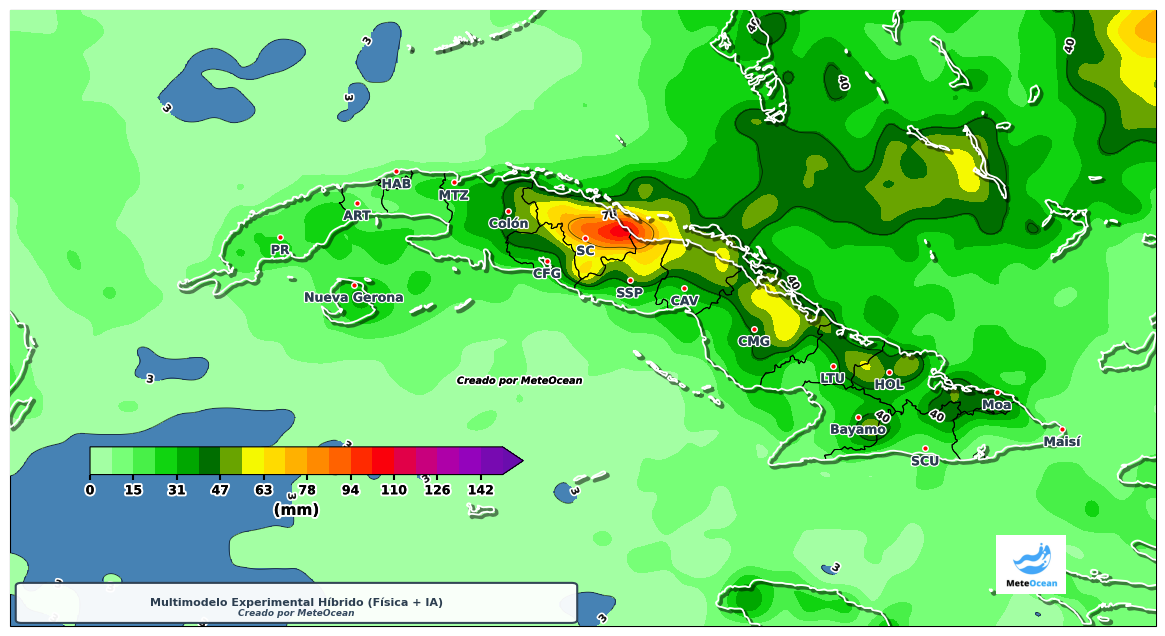

In [ ]:
#-----CUBA - PRECIPITACIÓN MULTIMODELO - REJILLA COMÚN ----#
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import geopandas as gpd
from shapely.geometry import Point
from scipy.interpolate import griddata
from scipy.spatial import KDTree
import matplotlib.patheffects as PathEffects
import matplotlib.colors as mcolors
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.image as mpimg
from scipy.ndimage import gaussian_filter
import os
import xarray as xr
from matplotlib.patches import FancyBboxPatch
from IPython.display import display

def graficar_precipitacion_dataarray(precip_dataarray, cuba=None, gdf_estados=None, mostrar_logo=True):
    """
    Grafica precipitación acumulada para Cuba y muestra automáticamente la figura en Colab.
    Ajusta dinámicamente el rango de colores según el valor máximo de precipitación.
    """
    # --- PARÁMETROS DE ÁREA ---
    lon_min_deg, lon_max_deg = -87, -73
    lat_min, lat_max = 18, 25


    # --- VERIFICAR COORDENADAS ---
    if 'longitude' not in precip_dataarray.coords or 'latitude' not in precip_dataarray.coords:
        raise ValueError("Input DataArray must have 'longitude' and 'latitude' coordinates.")

    # --- EXTRAER COORDENADAS ---
    lon_orig = precip_dataarray.longitude.values
    lat_orig = precip_dataarray.latitude.values

    print(f"Coordenadas originales:")
    print(f"  LON: [{lon_orig.min():.2f}, {lon_orig.max():.2f}] - {len(lon_orig)} puntos")
    print(f"  LAT: [{lat_orig.min():.2f}, {lat_orig.max():.2f}] - {len(lat_orig)} puntos")
    print(f"  Orden LAT: {'Descendente (N→S)' if lat_orig[0] > lat_orig[-1] else 'Ascendente (S→N)'}")

    precip_corrected = precip_dataarray

    # --- SELECCIONAR ÁREA ---
    if lat_orig[0] > lat_orig[-1]:
        precip_area = precip_corrected.sel(latitude=slice(lat_max, lat_min),
                                           longitude=slice(lon_min_deg, lon_max_deg))
    else:
        precip_area = precip_corrected.sel(latitude=slice(lat_min, lat_max),
                                           longitude=slice(lon_min_deg, lon_max_deg))

    lat = precip_area.latitude.values
    lon = precip_area.longitude.values

    print(f"\nÁrea seleccionada:")
    print(f"  LON: [{lon.min():.2f}, {lon.max():.2f}] - {len(lon)} puntos")
    print(f"  LAT: [{lat.min():.2f}, {lat.max():.2f}] - {len(lat)} puntos")

    if len(lon) == 0 or len(lat) == 0:
        raise ValueError(f"El área seleccionada está vacía. Verifica los límites: LON[{lon_min_deg},{lon_max_deg}], LAT[{lat_min},{lat_max}]")

    precip_vals = precip_area.values[0, :, :] if precip_area.values.ndim == 3 else precip_area.values
    print(f"  Precipitación: Min={precip_vals.min():.2f}, Max={precip_vals.max():.2f}, Mean={precip_vals.mean():.2f} mm")

    # --- MALLA ORIGINAL ---
    lon2d, lat2d = np.meshgrid(lon, lat)

    # --- INTERPOLACIÓN A REJILLA MÁS FINA ---
    lon_fine = np.linspace(lon.min(), lon.max(), 500)
    lat_fine = np.linspace(lat.min(), lat.max(), 500)
    lon2d_fine, lat2d_fine = np.meshgrid(lon_fine, lat_fine)
    points_orig = np.column_stack((lon2d.ravel(), lat2d.ravel()))
    values_orig = precip_vals.ravel()
    precip_fine = griddata(points_orig, values_orig, (lon2d_fine, lat2d_fine), method='cubic')

    # --- SUAVIZADO GAUSSIANO ---
    precip_fine_smooth = gaussian_filter(precip_fine, sigma=2)

    # --- MÁSCARA ---
    umbral_precip = 3
    precip_masked_fine = np.where(precip_fine_smooth > umbral_precip, precip_fine_smooth, np.nan)

    # --- RANGO DE COLOR DINÁMICO ---
    precip_max = np.nanmax(precip_fine_smooth)
    print(precip_max)
    if precip_max < 50:
        vmin_colorbar, vmax_colorbar = 1, 50
    elif 50 <= precip_max < 100:
        vmin_colorbar, vmax_colorbar = 0, 100
    else:
        vmin_colorbar, vmax_colorbar = 0, 150

    levels = np.linspace(vmin_colorbar, vmax_colorbar, 20)

    # --- CREAR FIGURA ---
    fig = plt.figure(figsize=(16, 8))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.set_extent([lon_min_deg, lon_max_deg, lat_min, lat_max], crs=ccrs.PlateCarree())

    # --- TERRITORIO ---
    ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=1)
    ax.add_feature(cfeature.OCEAN, facecolor='steelblue', zorder=1)
    lakes_feature = cfeature.NaturalEarthFeature('physical', 'lakes', '10m', edgecolor='black', facecolor='steelblue')
    ax.add_feature(lakes_feature, linewidth=0.5, zorder=2)

    if cuba is None and gdf_estados is not None:
        cuba = gdf_estados[gdf_estados['admin'] == 'Cuba'].copy()
    elif cuba is None:
        raise ValueError("Debe proporcionar 'cuba' o 'gdf_estados'")
    cuba.boundary.plot(ax=ax, edgecolor='black', linewidth=0.7, zorder=5)

    # --- COLORES ---
    colors_precip = [
        '#b6ffb6', '#66ff66', '#00cc00', '#006400', '#ffff00', '#ffb300',
        '#ff6600', '#ff0000', '#d00070', '#a000c0', '#6a0dad'
    ]
    cmap_precip = mcolors.LinearSegmentedColormap.from_list('precipitacion', colors_precip)

    # --- CONTORNO DE PRECIPITACIÓN ---
    cf = ax.contourf(
        lon2d_fine, lat2d_fine, precip_masked_fine,
        levels=levels, cmap=cmap_precip, extend='max',
        transform=ccrs.PlateCarree(), zorder=3
    )

    # --- ISOLÍNEAS ---
    contour_levels = np.unique(np.round(np.linspace(max(umbral_precip, vmin_colorbar), vmax_colorbar, 5)).astype(int))
    cs = ax.contour(
        lon2d_fine, lat2d_fine, precip_fine_smooth,
        levels=contour_levels, colors='black', linewidths=0.6,
        alpha=0.7, transform=ccrs.PlateCarree(), zorder=4
    )
    labels = ax.clabel(cs, inline=True, fontsize=7.5, fmt='%d', inline_spacing=8)
    for label in labels:
        label.set_fontweight('bold')
        label.set_path_effects([
            PathEffects.withStroke(linewidth=2.5, foreground='white'),
            PathEffects.Normal()
        ])

    # --- COSTA CON SOMBRA ---
    coastline_feature = cfeature.NaturalEarthFeature('physical', 'coastline', '10m')
    coastline_geoms = list(coastline_feature.geometries())
    ax.add_geometries(coastline_geoms, crs=ccrs.PlateCarree(),
                      edgecolor='black', facecolor='none', linewidth=2.5, alpha=0.3,
                      path_effects=[PathEffects.SimpleLineShadow(offset=(2, -2), alpha=0.5)],
                      zorder=6)
    ax.add_geometries(coastline_geoms, crs=ccrs.PlateCarree(),
                      edgecolor='white', facecolor='none', linewidth=1.3,
                      path_effects=[PathEffects.Normal()], zorder=7)

    # --- BARRA DE COLOR ---
    cax = inset_axes(ax, width="42%", height="5%", loc='lower left',
                     bbox_to_anchor=(-0.015, 0.088, 0.9, 0.9),
                     bbox_transform=ax.transAxes, borderpad=7)
    cbar = plt.colorbar(cf, cax=cax, orientation='horizontal')
    cbar.set_label("(mm)", fontsize=11, weight='bold')
    label_obj = cbar.ax.xaxis.get_label()
    label_obj.set_path_effects([
        PathEffects.withStroke(linewidth=3, foreground='white'),
        PathEffects.Normal()
    ])
    cbar.ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x)}'))
    cbar.ax.tick_params(labelsize=9, colors='black', width=1.5)
    for label in cbar.ax.get_xticklabels():
        label.set_fontweight('bold')
        label.set_path_effects([
            PathEffects.withStroke(linewidth=3, foreground='white'),
            PathEffects.Normal()
        ])

    # --- CIUDADES ---
    ciudades_principales = {
    "PR": {'lat': 22.42, 'lon': -83.70},
    "HAB": {'lat': 23.17, 'lon': -82.28},
    "MTZ": {'lat': 23.04, 'lon': -81.58},
    "Nueva Gerona": {'lat': 21.88, 'lon': -82.80},
    "Colón": {'lat': 22.72, 'lon': -80.91},
    "SC": {'lat': 22.41, 'lon': -79.97},
    "SSP": {'lat': 21.93, 'lon': -79.43},
    "CAV": {'lat': 21.84, 'lon': -78.76},
    "CMG": {'lat': 21.38, 'lon': -77.91},
    "Moa": {'lat': 20.66, 'lon': -74.945},
    "HOL": {'lat': 20.89, 'lon': -76.26},
    "Bayamo": {'lat': 20.38, 'lon': -76.64},
    "SCU": {'lat': 20.02, 'lon': -75.82},
    "Maisí": {'lat': 20.24, 'lon': -74.15},
    "LTU": {'lat': 20.96, 'lon': -76.95},
    "CFG": {'lat': 22.15, 'lon': -80.44},
    "ART": {'lat': 22.81, 'lon': -82.76},

}

    flat_points = np.column_stack((lat2d_fine.ravel(), lon2d_fine.ravel()))
    tree = KDTree(flat_points)
    precip_values = precip_fine_smooth.ravel()

    for nombre, datos in ciudades_principales.items():
        lat_ci, lon_ci = datos['lat'], datos['lon']
        _, idx = tree.query([lat_ci, lon_ci])
        precip = precip_values[idx]

        ax.plot(lon_ci, lat_ci, 'o',
                color='red', markersize=4,
                markeredgecolor='white', markeredgewidth=1,
                transform=ccrs.PlateCarree(), zorder=12)

        ax.text(
            lon_ci, lat_ci - 0.08, nombre,
            fontsize=9, color='#2C3E50', weight='bold',
            ha='center', va='top', zorder=15,
            transform=ccrs.PlateCarree(),
            path_effects=[
                PathEffects.withStroke(linewidth=2, foreground='white'),
                PathEffects.SimpleLineShadow(offset=(1, -1), alpha=0.3),
                PathEffects.Normal()
            ]
        )

    # --- LOGO ---
    if mostrar_logo:
        try:
            logo_img = mpimg.imread("/content/drive/My Drive/Logo.png")
            axins_logo = inset_axes(ax, width="9.5%", height="9.5%", loc='lower right',
                                    bbox_to_anchor=(-0.05, 0.03, 1, 1),
                                    bbox_transform=ax.transAxes, borderpad=1)
            axins_logo.imshow(logo_img)
            axins_logo.axis('off')
        except:
            print("Logo no encontrado")

    # Crédito
    ax.text(0.5, 0.39, 'Creado por MeteOcean',
            transform=ax.transAxes, fontsize=7, ha='right', va='bottom',
            color='black', fontstyle='italic', fontweight='bold',
            path_effects=[
                PathEffects.withStroke(linewidth=2.5, foreground='white'),
                PathEffects.Normal()
            ])

    # --- BANNER ---
    banner_box = FancyBboxPatch(
        (0.01, 0.01), 0.48, 0.055,
        boxstyle="round,pad=0.005",
        transform=ax.transAxes,
        facecolor='white',
        edgecolor='#2C3E50',
        linewidth=1.5,
        alpha=0.95,
        zorder=20
    )
    ax.add_patch(banner_box)
    ax.text(0.25, 0.0375, 'Multimodelo Experimental Híbrido (Física + IA)',
            transform=ax.transAxes, fontsize=8, ha='center', va='center',
            color='#2C3E50', fontweight='bold', zorder=21)
    ax.text(0.25, 0.02, 'Creado por MeteOcean',
            transform=ax.transAxes, fontsize=6.5, ha='center', va='center',
            color='#34495E', fontstyle='italic', fontweight='semibold', zorder=21)

    # --- GUARDAR ---
    output_dir = "/content/drive/My Drive/Colab Notebooks/mapas/precipitacion"
    os.makedirs(output_dir, exist_ok=True)
    plt.savefig(f"{output_dir}/cuba_mapa_precipitacion_multimodelo.png", dpi=800, bbox_inches='tight')

    # --- MOSTRAR AUTOMÁTICAMENTE EN COLAB ---
    plt.show()

    return fig, ax

# --- USO ---
cuba = gdf_estados[gdf_estados['admin'] == 'Cuba'].copy()
fig, ax = graficar_precipitacion_dataarray(ds_multi, cuba=cuba)


Coordenadas originales:
 LON: [-180.00, 179.75] - 1440 puntos
 LAT: [-90.00, 90.00] - 721 puntos
 Orden LAT: Ascendente (S→N)

Área seleccionada:
 LON: [-94.00, -74.00] - 81 puntos
 LAT: [7.00, 19.50] - 51 puntos
 Precipitación: Min=0.03, Max=153.48, Mean=23.92 mm


/tmp/ipykernel_8442/2381842980.py:176: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  fronteras = gdf_pais.unary_union.boundary
/tmp/ipykernel_8442/2381842980.py:176: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  fronteras = gdf_pais.unary_union.boundary
/tmp/ipykernel_8442/2381842980.py:176: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  fronteras = gdf_pais.unary_union.boundary
/tmp/ipykernel_8442/2381842980.py:176: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  fronteras = gdf_pais.unary_union.boundary
/tmp/ipykernel_8442/2381842980.py:176: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  fronteras = gdf_pais.unary_union.boundary
/tmp/ipykernel_8442/2381842980.py:176: DeprecationWarning: The 'unary_union' att

✅ Mapa guardado: /content/drive/My Drive/Colab Notebooks/mapas/precipitacion/centroamerica_mapa_precipitacion_multimodelo.png


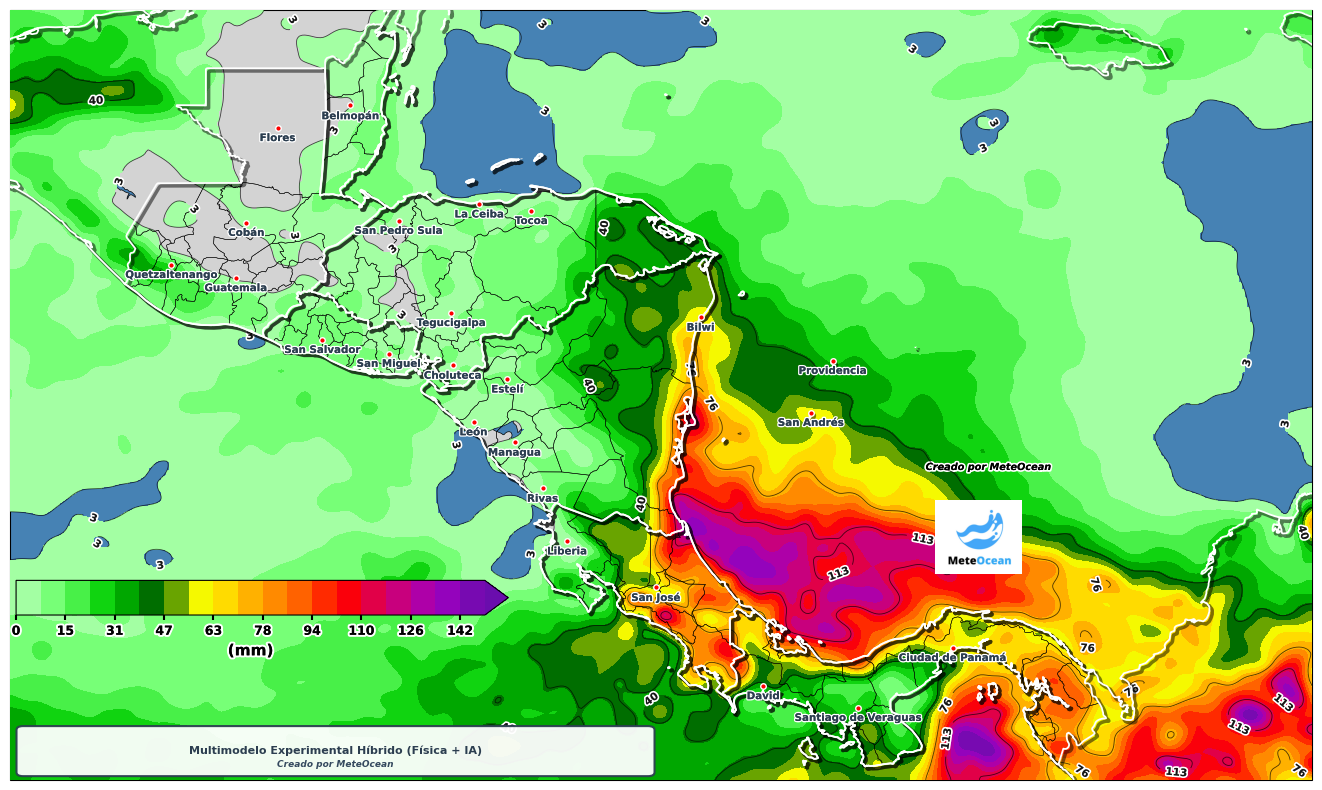

In [ ]:
#-----CENTROAMÉRICA - PRECIPITACIÓN MULTIMODELO - REJILLA COMÚN ----#
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import geopandas as gpd
from shapely.geometry import Point
from scipy.interpolate import griddata
from scipy.spatial import KDTree
import matplotlib.patheffects as PathEffects
import matplotlib.colors as mcolors
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.image as mpimg
from scipy.ndimage import gaussian_filter
import os
import xarray as xr
from matplotlib.patches import FancyBboxPatch

def graficar_precipitacion_centroamerica(precip_dataarray, gdf_estados=None, mostrar_logo=True):
    """
    Grafica precipitación acumulada para Centroamérica y muestra automáticamente la figura.
    Ajusta dinámicamente el rango de colores según el valor máximo de precipitación.

    Parámetros:
    -----------
    precip_dataarray : xarray.DataArray
        DataArray con precipitación en mm con coordenadas 'longitude' y 'latitude'
    gdf_estados : GeoDataFrame
        GeoDataFrame con todos los estados
    mostrar_logo : bool
        Si se muestra el logo (default: True)
    """

    if gdf_estados is None:
        raise ValueError("Debe proporcionar 'gdf_estados'")

    # Filtrar países de Centroamérica
    paises = ['Guatemala', 'Belize', 'Honduras', 'El Salvador', 'Nicaragua', 'Costa Rica', 'Panama']
    gdf_ca = gdf_estados[gdf_estados['admin'].isin(paises)].copy()

    # --- PARÁMETROS DE ÁREA ---
    lon_min_deg, lon_max_deg = -94, -74
    lat_min, lat_max = 7, 18.7

    # --- VERIFICAR COORDENADAS ---
    if 'longitude' not in precip_dataarray.coords or 'latitude' not in precip_dataarray.coords:
        raise ValueError("Input DataArray must have 'longitude' and 'latitude' coordinates.")

    # --- EXTRAER COORDENADAS ---
    lon_orig = precip_dataarray.longitude.values
    lat_orig = precip_dataarray.latitude.values

    print(f"Coordenadas originales:")
    print(f" LON: [{lon_orig.min():.2f}, {lon_orig.max():.2f}] - {len(lon_orig)} puntos")
    print(f" LAT: [{lat_orig.min():.2f}, {lat_orig.max():.2f}] - {len(lat_orig)} puntos")
    print(f" Orden LAT: {'Descendente (N→S)' if lat_orig[0] > lat_orig[-1] else 'Ascendente (S→N)'}")

    precip_corrected = precip_dataarray

    # --- SELECCIONAR ÁREA ---
    if lat_orig[0] > lat_orig[-1]:
        precip_area = precip_corrected.sel(
            latitude=slice(lat_max+1, lat_min),
            longitude=slice(lon_min_deg, lon_max_deg)
        )
    else:
        precip_area = precip_corrected.sel(
            latitude=slice(lat_min, lat_max+1),
            longitude=slice(lon_min_deg, lon_max_deg)
        )

    lat = precip_area.latitude.values
    lon = precip_area.longitude.values

    print(f"\nÁrea seleccionada:")
    print(f" LON: [{lon.min():.2f}, {lon.max():.2f}] - {len(lon)} puntos")
    print(f" LAT: [{lat.min():.2f}, {lat.max():.2f}] - {len(lat)} puntos")

    if len(lon) == 0 or len(lat) == 0:
        raise ValueError(f"El área seleccionada está vacía. Verifica los límites: LON[{lon_min_deg},{lon_max_deg}], LAT[{lat_min},{lat_max}]")

    precip_vals = precip_area.values[0, :, :] if precip_area.values.ndim == 3 else precip_area.values
    print(f" Precipitación: Min={precip_vals.min():.2f}, Max={precip_vals.max():.2f}, Mean={precip_vals.mean():.2f} mm")

    # --- MALLA ORIGINAL ---
    lon2d, lat2d = np.meshgrid(lon, lat)

    # --- INTERPOLACIÓN A REJILLA MÁS FINA ---
    lon_fine = np.linspace(lon.min(), lon.max(), 500)
    lat_fine = np.linspace(lat.min(), lat.max(), 500)
    lon2d_fine, lat2d_fine = np.meshgrid(lon_fine, lat_fine)

    points_orig = np.column_stack((lon2d.ravel(), lat2d.ravel()))
    values_orig = precip_vals.ravel()
    precip_fine = griddata(points_orig, values_orig, (lon2d_fine, lat2d_fine), method='cubic')

    # --- SUAVIZADO GAUSSIANO ---
    precip_fine_smooth = gaussian_filter(precip_fine, sigma=2)

    # --- MÁSCARA SOLO POR UMBRAL (sin restringir a tierra) ---
    umbral_precip = 3
    precip_masked_fine = np.where(precip_fine_smooth > umbral_precip, precip_fine_smooth, np.nan)

    # --- RANGO DE COLOR DINÁMICO ---
    precip_max = np.nanmax(precip_masked_fine)

    if precip_max < 50:
        vmin_colorbar, vmax_colorbar = 1, 50
    elif 50 <= precip_max < 100:
        vmin_colorbar, vmax_colorbar = 0, 100
    elif 100 <= precip_max < 150:
        vmin_colorbar, vmax_colorbar = 0, 150
    else:
        vmin_colorbar, vmax_colorbar = 1, 250

    levels = np.linspace(vmin_colorbar, vmax_colorbar, 20)

    # --- CREAR FIGURA ---
    fig = plt.figure(figsize=(18, 10))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.set_extent([lon_min_deg, lon_max_deg, lat_min, lat_max], crs=ccrs.PlateCarree())

    # --- TERRITORIO ---
    ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=1)
    ax.add_feature(cfeature.OCEAN, facecolor='steelblue', zorder=1)

    lakes_feature = cfeature.NaturalEarthFeature('physical', 'lakes', '10m',
                                                   edgecolor='black', facecolor='steelblue')
    ax.add_feature(lakes_feature, linewidth=0.5, zorder=2)

    # --- COLORES DE PRECIPITACIÓN ---
    colors_precip = [
        '#b6ffb6', '#66ff66', '#00cc00', '#006400', '#ffff00', '#ffb300',
        '#ff6600', '#ff0000', '#d00070', '#a000c0', '#6a0dad'
    ]
    cmap_precip = mcolors.LinearSegmentedColormap.from_list('precipitacion', colors_precip)

    # --- CONTORNO DE PRECIPITACIÓN ---
    cf = ax.contourf(
        lon2d_fine, lat2d_fine, precip_masked_fine,
        levels=levels, cmap=cmap_precip, extend='max',
        transform=ccrs.PlateCarree(), zorder=3
    )

    # --- ISOLÍNEAS ---
    contour_levels = np.unique(np.round(np.linspace(max(umbral_precip, vmin_colorbar), vmax_colorbar, 5)).astype(int))
    cs = ax.contour(
        lon2d_fine, lat2d_fine, precip_fine_smooth,
        levels=contour_levels, colors='black', linewidths=0.6,
        alpha=0.7, transform=ccrs.PlateCarree(), zorder=4
    )

    labels = ax.clabel(cs, inline=True, fontsize=7.5, fmt='%d', inline_spacing=8)
    for label in labels:
        label.set_fontweight('bold')
        label.set_path_effects([
            PathEffects.withStroke(linewidth=2.5, foreground='white'),
            PathEffects.Normal()
        ])

    # --- COSTAS CON SOMBRA 3D ---
    coastline_feature = cfeature.NaturalEarthFeature('physical', 'coastline', '10m')
    coastline_geoms = list(coastline_feature.geometries())
    ax.add_geometries(coastline_geoms, crs=ccrs.PlateCarree(),
                      edgecolor='black', facecolor='none', linewidth=2.5, alpha=0.3,
                      path_effects=[PathEffects.SimpleLineShadow(offset=(2, -2), alpha=0.5)],
                      zorder=6)
    ax.add_geometries(coastline_geoms, crs=ccrs.PlateCarree(),
                      edgecolor='white', facecolor='none', linewidth=1.3,
                      path_effects=[PathEffects.Normal()], zorder=7)

    # --- FRONTERAS PAÍSES CON EFECTO 3D ---
    for pais in paises:
        gdf_pais = gdf_ca[gdf_ca['admin'] == pais]
        if len(gdf_pais) > 0:
            fronteras = gdf_pais.unary_union.boundary
            ax.add_geometries([fronteras], crs=ccrs.PlateCarree(),
                              edgecolor='black', facecolor='none', linewidth=2.5, alpha=0.3,
                              path_effects=[PathEffects.SimpleLineShadow(offset=(2, -2), alpha=0.5)],
                              zorder=6)
            ax.add_geometries([fronteras], crs=ccrs.PlateCarree(),
                              edgecolor='white', facecolor='none', linewidth=1.3,
                              path_effects=[PathEffects.Normal()], zorder=7)

    # --- PROVINCIAS INTERNAS ---
    for pais in paises:
        provincias = gdf_ca[(gdf_ca['admin'] == pais) & (gdf_ca['type'] != 'Country')]
        if len(provincias) > 0:
            provincias.boundary.plot(ax=ax, edgecolor='black', linewidth=0.35,
                                      zorder=4, transform=ccrs.PlateCarree())

    # --- BARRA DE COLOR ---
    cax = inset_axes(ax, width="42%", height="5%", loc='lower left',
                     bbox_to_anchor=(-0.07, 0.088, 0.9, 0.9),
                     bbox_transform=ax.transAxes, borderpad=7)
    cbar = plt.colorbar(cf, cax=cax, orientation='horizontal')
    cbar.set_label("(mm)", fontsize=11, weight='bold')

    label_obj = cbar.ax.xaxis.get_label()
    label_obj.set_path_effects([
        PathEffects.withStroke(linewidth=3, foreground='white'),
        PathEffects.Normal()
    ])

    cbar.ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x)}'))
    cbar.ax.tick_params(labelsize=9, colors='black', width=1.5)

    for label in cbar.ax.get_xticklabels():
        label.set_fontweight('bold')
        label.set_path_effects([
            PathEffects.withStroke(linewidth=3, foreground='white'),
            PathEffects.Normal()
        ])

    # --- CIUDADES PRINCIPALES DE CENTROAMÉRICA ---
    ciudades_principales = {
        # Guatemala
        "Guatemala": {'lat': 14.63, 'lon': -90.53},
        "Quetzaltenango": {'lat': 14.83, 'lon': -91.52},
        "Cobán": {'lat': 15.47, 'lon': -90.37},
        "Flores": {'lat': 16.91, 'lon': -89.89},

        # Honduras
        "Tegucigalpa": {'lat': 14.10, 'lon': -87.22},
        "San Pedro Sula": {'lat': 15.50, 'lon': -88.03},
        "La Ceiba": {'lat': 15.75, 'lon': -86.79},
        "Choluteca": {'lat': 13.30, 'lon': -87.20},
        "Tocoa": {'lat': 15.65, 'lon': -85.99},

        # El Salvador
        "San Salvador": {'lat': 13.69, 'lon': -89.20},
        "San Miguel": {'lat': 13.48, 'lon': -88.18},

        # Nicaragua
        "Managua": {'lat': 12.13, 'lon': -86.25},
        "León": {'lat': 12.44, 'lon': -86.88},
        "Estelí": {'lat': 13.09, 'lon': -86.36},
        "Rivas": {'lat': 11.43, 'lon': -85.82},
        "Bilwi": {'lat': 14.03, 'lon': -83.39},
        "San Andrés": {'lat': 12.5830, 'lon': -81.7},
        "Providencia": {'lat': 13.3733, 'lon': -81.3627},

        # Costa Rica
        "San José": {'lat': 9.93, 'lon': -84.08},
        "Liberia": {'lat': 10.63, 'lon': -85.44},

        # Panamá
        "Ciudad de Panamá": {'lat': 9.01, 'lon': -79.52},
        "David": {'lat': 8.43, 'lon': -82.43},
        "Santiago de Veraguas": {'lat': 8.10, 'lon': -80.97},

        # Belice
        "Belmopán": {'lat': 17.25, 'lon': -88.77}
    }

    flat_points = np.column_stack((lat2d_fine.ravel(), lon2d_fine.ravel()))
    tree = KDTree(flat_points)
    precip_values = precip_fine_smooth.ravel()

    for nombre, datos in ciudades_principales.items():
        lat_ci, lon_ci = datos['lat'], datos['lon']
        _, idx = tree.query([lat_ci, lon_ci])
        precip = precip_values[idx]

        ax.plot(lon_ci, lat_ci, 'o',
                color='red', markersize=4,
                markeredgecolor='white', markeredgewidth=1,
                transform=ccrs.PlateCarree(), zorder=12)

        ax.text(
            lon_ci, lat_ci - 0.08, nombre,
            fontsize=7.4, color='#2C3E50', weight='bold',
            ha='center', va='top', zorder=15,
            transform=ccrs.PlateCarree(),
            path_effects=[
                PathEffects.withStroke(linewidth=2, foreground='white'),
                PathEffects.SimpleLineShadow(offset=(1, -1), alpha=0.3),
                PathEffects.Normal()
            ]
        )

    # --- LOGO ---
    if mostrar_logo:
        try:
            logo_img = mpimg.imread("/content/drive/My Drive/Logo.png")
            axins_logo = inset_axes(ax, width="9.5%", height="9.5%", loc='lower right',
                                    bbox_to_anchor=(-0.198, 0.25, 1, 1),
                                    bbox_transform=ax.transAxes, borderpad=1)
            axins_logo.imshow(logo_img)
            axins_logo.axis('off')
        except:
            print("⚠️ Logo no encontrado en /content/drive/My Drive/Logo.png")

    # Crédito
    ax.text(0.8, 0.4, 'Creado por MeteOcean',
            transform=ax.transAxes, fontsize=7, ha='right', va='bottom',
            color='black', fontstyle='italic', fontweight='bold',
            path_effects=[
                PathEffects.withStroke(linewidth=2.5, foreground='white'),
                PathEffects.Normal()
            ])

    # --- BANNER ---
    banner_box = FancyBboxPatch(
        (0.01, 0.01), 0.48, 0.055,
        boxstyle="round,pad=0.005",
        transform=ax.transAxes,
        facecolor='white',
        edgecolor='#2C3E50',
        linewidth=1.5,
        alpha=0.95,
        zorder=20
    )
    ax.add_patch(banner_box)

    ax.text(0.25, 0.0375, 'Multimodelo Experimental Híbrido (Física + IA)',
            transform=ax.transAxes, fontsize=8, ha='center', va='center',
            color='#2C3E50', fontweight='bold', zorder=21)

    ax.text(0.25, 0.02, 'Creado por MeteOcean',
            transform=ax.transAxes, fontsize=6.5, ha='center', va='center',
            color='#34495E', fontstyle='italic', fontweight='semibold', zorder=21)

    # --- GUARDAR ---
    output_dir = "/content/drive/My Drive/Colab Notebooks/mapas/precipitacion"
    os.makedirs(output_dir, exist_ok=True)
    plt.savefig(f"{output_dir}/centroamerica_mapa_precipitacion_multimodelo.png",
                dpi=800, bbox_inches='tight')
    print(f"✅ Mapa guardado: {output_dir}/centroamerica_mapa_precipitacion_multimodelo.png")

    # --- MOSTRAR AUTOMÁTICAMENTE EN COLAB ---
    plt.show()

    return fig, ax


# --- USO ---
# Asegúrate de tener cargado gdf_estados y ds_multimodelo de tu clase MultiModeloMeteorologico
fig, ax = graficar_precipitacion_centroamerica(ds_multi, gdf_estados=gdf_estados)

Coordenadas originales:
 LON: [-180.00, 179.75] - 1440 puntos
 LAT: [-90.00, 90.00] - 721 puntos
 Orden LAT: Ascendente (S→N)

Área seleccionada:
 LON: [-76.00, -67.00] - 37 puntos
 LAT: [16.00, 21.75] - 24 puntos
 Precipitación: Min=0.69, Max=59.72, Mean=11.13 mm


/tmp/ipykernel_8442/4163524912.py:177: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  frontera_internacional = haiti.unary_union.intersection(republica_dominicana.unary_union)


✅ Mapa guardado: /content/drive/My Drive/Colab Notebooks/mapas/precipitacion/hispaniola_mapa_precipitacion_multimodelo.png


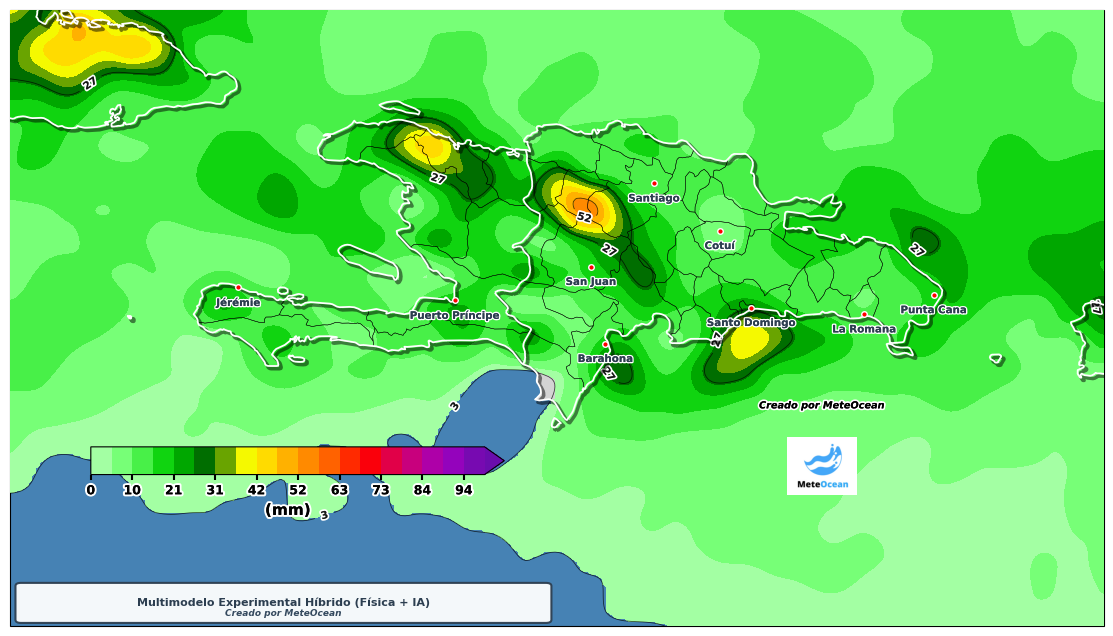

In [ ]:
#-----LA ESPAÑOLA (HAITÍ Y REPÚBLICA DOMINICANA) - PRECIPITACIÓN MULTIMODELO----#
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import geopandas as gpd
import pandas as pd
from shapely.geometry import Point
from scipy.interpolate import griddata
from scipy.spatial import KDTree
import matplotlib.patheffects as PathEffects
import matplotlib.colors as mcolors
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.image as mpimg
from scipy.ndimage import gaussian_filter
import os
from matplotlib.patches import FancyBboxPatch

def graficar_precipitacion_hispaniola(precip_dataarray, gdf_estados=None, mostrar_logo=True):
    """
    Grafica precipitación acumulada para La Española (Haití y República Dominicana).
    Ajusta dinámicamente el rango de colores según el valor máximo de precipitación.
    La precipitación se muestra tanto sobre tierra como sobre el mar.

    Parámetros:
    -----------
    precip_dataarray : xarray.DataArray
        DataArray con precipitación en mm con coordenadas 'longitude' y 'latitude'
    gdf_estados : GeoDataFrame
        GeoDataFrame con todos los estados
    mostrar_logo : bool
        Si se muestra el logo (default: True)
    """

    if gdf_estados is None:
        raise ValueError("Debe proporcionar 'gdf_estados'")

    # --- FILTRAR HAITÍ Y REPÚBLICA DOMINICANA ---
    haiti = gdf_estados[gdf_estados['admin'] == 'Haiti'].copy()
    republica_dominicana = gdf_estados[gdf_estados['admin'] == 'Dominican Republic'].copy()
    hispaniola = pd.concat([haiti, republica_dominicana])

    # --- PARÁMETROS DE ÁREA ---
    lon_min_deg = -76
    lon_max_deg = -67
    lat_min = 16
    lat_max = 20.8

    # --- VERIFICAR COORDENADAS ---
    if 'longitude' not in precip_dataarray.coords or 'latitude' not in precip_dataarray.coords:
        raise ValueError("Input DataArray must have 'longitude' and 'latitude' coordinates.")

    # --- EXTRAER COORDENADAS ---
    lon_orig = precip_dataarray.longitude.values
    lat_orig = precip_dataarray.latitude.values

    print(f"Coordenadas originales:")
    print(f" LON: [{lon_orig.min():.2f}, {lon_orig.max():.2f}] - {len(lon_orig)} puntos")
    print(f" LAT: [{lat_orig.min():.2f}, {lat_orig.max():.2f}] - {len(lat_orig)} puntos")
    print(f" Orden LAT: {'Descendente (N→S)' if lat_orig[0] > lat_orig[-1] else 'Ascendente (S→N)'}")

    precip_corrected = precip_dataarray

    # --- SELECCIONAR ÁREA ---
    if lat_orig[0] > lat_orig[-1]:
        precip_area = precip_corrected.sel(
            latitude=slice(lat_max+1, lat_min),
            longitude=slice(lon_min_deg, lon_max_deg)
        )
    else:
        precip_area = precip_corrected.sel(
            latitude=slice(lat_min, lat_max+1),
            longitude=slice(lon_min_deg, lon_max_deg)
        )

    lat = precip_area.latitude.values
    lon = precip_area.longitude.values

    print(f"\nÁrea seleccionada:")
    print(f" LON: [{lon.min():.2f}, {lon.max():.2f}] - {len(lon)} puntos")
    print(f" LAT: [{lat.min():.2f}, {lat.max():.2f}] - {len(lat)} puntos")

    if len(lon) == 0 or len(lat) == 0:
        raise ValueError(f"El área seleccionada está vacía. Verifica los límites: LON[{lon_min_deg},{lon_max_deg}], LAT[{lat_min},{lat_max}]")

    precip_vals = precip_area.values[0, :, :] if precip_area.values.ndim == 3 else precip_area.values
    print(f" Precipitación: Min={precip_vals.min():.2f}, Max={precip_vals.max():.2f}, Mean={precip_vals.mean():.2f} mm")

    # --- MALLA ORIGINAL ---
    lon2d, lat2d = np.meshgrid(lon, lat)

    # --- INTERPOLACIÓN A REJILLA MÁS FINA ---
    lon_fine = np.linspace(lon.min(), lon.max(), 300)
    lat_fine = np.linspace(lat.min(), lat.max(), 300)
    lon2d_fine, lat2d_fine = np.meshgrid(lon_fine, lat_fine)

    points_orig = np.column_stack((lon2d.ravel(), lat2d.ravel()))
    values_orig = precip_vals.ravel()
    precip_fine = griddata(points_orig, values_orig, (lon2d_fine, lat2d_fine), method='cubic')

    # --- SUAVIZADO GAUSSIANO ---
    precip_fine_smooth = gaussian_filter(precip_fine, sigma=2)

    # --- MÁSCARA SOLO POR UMBRAL (sin restringir a tierra) ---
    umbral_precip = 3
    precip_masked_fine = np.where(precip_fine_smooth > umbral_precip, precip_fine_smooth, np.nan)

    # --- RANGO DE COLOR DINÁMICO ---
    precip_max = np.nanmax(precip_masked_fine)

    if precip_max < 50:
        vmin_colorbar, vmax_colorbar = 1, 50
    elif 50 <= precip_max < 100:
        vmin_colorbar, vmax_colorbar = 0, 100
    elif 100 <= precip_max < 150:
        vmin_colorbar, vmax_colorbar = 0, 150
    else:
        vmin_colorbar, vmax_colorbar = 1, 200

    levels = np.linspace(vmin_colorbar, vmax_colorbar, 20)

    # --- CREAR FIGURA ---
    fig = plt.figure(figsize=(16, 8))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.set_extent([lon_min_deg, lon_max_deg, lat_min, lat_max], crs=ccrs.PlateCarree())

    # --- TERRITORIO ---
    ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=1)
    ax.add_feature(cfeature.OCEAN, facecolor='steelblue', zorder=1)

    lakes_feature = cfeature.NaturalEarthFeature('physical', 'lakes', '10m',
                                                   edgecolor='black', facecolor='steelblue')
    ax.add_feature(lakes_feature, linewidth=0.5, zorder=2)

    # --- COLORES DE PRECIPITACIÓN ---
    colors_precip = [
        '#b6ffb6', '#66ff66', '#00cc00', '#006400', '#ffff00', '#ffb300',
        '#ff6600', '#ff0000', '#d00070', '#a000c0', '#6a0dad'
    ]
    cmap_precip = mcolors.LinearSegmentedColormap.from_list('precipitacion', colors_precip)

    # --- CONTORNO DE PRECIPITACIÓN (SOBRE TIERRA Y MAR) ---
    cf = ax.contourf(
        lon2d_fine, lat2d_fine, precip_masked_fine,
        levels=levels, cmap=cmap_precip, extend='max',
        transform=ccrs.PlateCarree(), zorder=3
    )

    # --- ISOLÍNEAS ---
    contour_levels = np.unique(np.round(np.linspace(max(umbral_precip, vmin_colorbar), vmax_colorbar, 5)).astype(int))
    cs = ax.contour(
        lon2d_fine, lat2d_fine, precip_fine_smooth,
        levels=contour_levels, colors='black', linewidths=0.6,
        alpha=0.7, transform=ccrs.PlateCarree(), zorder=4
    )

    labels = ax.clabel(cs, inline=True, fontsize=7.5, fmt='%d', inline_spacing=8)
    for label in labels:
        label.set_fontweight('bold')
        label.set_path_effects([
            PathEffects.withStroke(linewidth=2.5, foreground='white'),
            PathEffects.Normal()
        ])

    # --- COSTAS CON SOMBRA 3D ---
    coastline_feature = cfeature.NaturalEarthFeature('physical', 'coastline', '10m')
    coastline_geoms = list(coastline_feature.geometries())
    ax.add_geometries(coastline_geoms, crs=ccrs.PlateCarree(),
                      edgecolor='black', facecolor='none', linewidth=2.5, alpha=0.3,
                      path_effects=[PathEffects.SimpleLineShadow(offset=(2, -2), alpha=0.5)],
                      zorder=6)
    ax.add_geometries(coastline_geoms, crs=ccrs.PlateCarree(),
                      edgecolor='white', facecolor='none', linewidth=1.3,
                      path_effects=[PathEffects.Normal()], zorder=7)

    # --- FRONTERA INTERNACIONAL ENTRE HAITÍ Y RD ---
    frontera_internacional = haiti.unary_union.intersection(republica_dominicana.unary_union)
    ax.add_geometries([frontera_internacional], crs=ccrs.PlateCarree(),
                      edgecolor='black', facecolor='none', linewidth=2.5, alpha=0.3,
                      path_effects=[PathEffects.SimpleLineShadow(offset=(2, -2), alpha=0.5)],
                      zorder=6)
    ax.add_geometries([frontera_internacional], crs=ccrs.PlateCarree(),
                      edgecolor='white', facecolor='none', linewidth=1.3,
                      path_effects=[PathEffects.Normal()], zorder=7)

    # --- PROVINCIAS INTERNAS ---
    # Provincias de Haití
    provincias_haiti = gdf_estados[(gdf_estados['admin'] == 'Haiti') & (gdf_estados['type'] != 'Country')]
    provincias_haiti.boundary.plot(ax=ax, edgecolor='black', linewidth=0.3, zorder=4, transform=ccrs.PlateCarree())

    # Provincias de República Dominicana
    provincias_rd = gdf_estados[(gdf_estados['admin'] == 'Dominican Republic') & (gdf_estados['type'] != 'Country')]
    provincias_rd.boundary.plot(ax=ax, edgecolor='black', linewidth=0.3, zorder=4, transform=ccrs.PlateCarree())

    # --- BARRA DE COLOR ---
    cax = inset_axes(ax, width="42%", height="5%", loc='lower left',
                     bbox_to_anchor=(-0.015, 0.088, 0.9, 0.9),
                     bbox_transform=ax.transAxes, borderpad=7)
    cbar = plt.colorbar(cf, cax=cax, orientation='horizontal')
    cbar.set_label("(mm)", fontsize=11, weight='bold')

    label_obj = cbar.ax.xaxis.get_label()
    label_obj.set_path_effects([
        PathEffects.withStroke(linewidth=3, foreground='white'),
        PathEffects.Normal()
    ])

    cbar.ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x)}'))
    cbar.ax.tick_params(labelsize=9, colors='black', width=1.5)

    for label in cbar.ax.get_xticklabels():
        label.set_fontweight('bold')
        label.set_path_effects([
            PathEffects.withStroke(linewidth=3, foreground='white'),
            PathEffects.Normal()
        ])

    # --- CIUDADES PRINCIPALES DE LA ESPAÑOLA ---
    ciudades_principales = {
        "Puerto Príncipe": {'lat': 18.54, 'lon': -72.34},
        "Santiago": {'lat': 19.45, 'lon': -70.70},
        "Santo Domingo": {'lat': 18.48, 'lon': -69.90},
        "Cotuí": {'lat': 19.08, 'lon': -70.16},
        "San Juan": {'lat': 18.80, 'lon': -71.22},
        "Barahona": {'lat': 18.20, 'lon': -71.10},
        "Punta Cana": {'lat': 18.58, 'lon': -68.40},
        "Jérémie": {'lat': 18.64, 'lon': -74.12},
        "La Romana": {'lat': 18.43, 'lon': -68.97},
    }

    flat_points = np.column_stack((lat2d_fine.ravel(), lon2d_fine.ravel()))
    tree = KDTree(flat_points)
    precip_values = precip_fine_smooth.ravel()

    for nombre, datos in ciudades_principales.items():
        lat_ci, lon_ci = datos['lat'], datos['lon']
        _, idx = tree.query([lat_ci, lon_ci])
        precip = precip_values[idx]

        ax.plot(lon_ci, lat_ci, 'o',
                color='red', markersize=4,
                markeredgecolor='white', markeredgewidth=1,
                transform=ccrs.PlateCarree(), zorder=12)

        ax.text(
            lon_ci, lat_ci - 0.08, nombre,
            fontsize=7.4, color='#2C3E50', weight='bold',
            ha='center', va='top', zorder=15,
            transform=ccrs.PlateCarree(),
            path_effects=[
                PathEffects.withStroke(linewidth=2, foreground='white'),
                PathEffects.SimpleLineShadow(offset=(1, -1), alpha=0.3),
                PathEffects.Normal()
            ]
        )

    # --- LOGO ---
    if mostrar_logo:
        try:
            logo_img = mpimg.imread("/content/drive/My Drive/Logo.png")
            axins_logo = inset_axes(ax, width="9.5%", height="9.5%", loc='lower right',
                                    bbox_to_anchor=(-0.198, 0.19, 1, 1),
                                    bbox_transform=ax.transAxes, borderpad=1)
            axins_logo.imshow(logo_img)
            axins_logo.axis('off')
        except:
            print("⚠️ Logo no encontrado en /content/drive/My Drive/Logo.png")

    # Crédito
    ax.text(0.8, 0.35, 'Creado por MeteOcean',
            transform=ax.transAxes, fontsize=7, ha='right', va='bottom',
            color='black', fontstyle='italic', fontweight='bold',
            path_effects=[
                PathEffects.withStroke(linewidth=2.5, foreground='white'),
                PathEffects.Normal()
            ])

    # --- BANNER ---
    banner_box = FancyBboxPatch(
        (0.01, 0.01), 0.48, 0.055,
        boxstyle="round,pad=0.005",
        transform=ax.transAxes,
        facecolor='white',
        edgecolor='#2C3E50',
        linewidth=1.5,
        alpha=0.95,
        zorder=20
    )
    ax.add_patch(banner_box)

    ax.text(0.25, 0.0375, 'Multimodelo Experimental Híbrido (Física + IA)',
            transform=ax.transAxes, fontsize=8, ha='center', va='center',
            color='#2C3E50', fontweight='bold', zorder=21)

    ax.text(0.25, 0.02, 'Creado por MeteOcean',
            transform=ax.transAxes, fontsize=6.5, ha='center', va='center',
            color='#34495E', fontstyle='italic', fontweight='semibold', zorder=21)

    # --- GUARDAR ---
    output_dir = "/content/drive/My Drive/Colab Notebooks/mapas/precipitacion"
    os.makedirs(output_dir, exist_ok=True)
    plt.savefig(f"{output_dir}/hispaniola_mapa_precipitacion_multimodelo.png",
                dpi=800, bbox_inches='tight')
    print(f"✅ Mapa guardado: {output_dir}/hispaniola_mapa_precipitacion_multimodelo.png")

    # --- MOSTRAR AUTOMÁTICAMENTE EN COLAB ---
    plt.show()

    return fig, ax


# --- USO ---
# Asegúrate de tener cargado gdf_estados y ds_multimodelo de tu clase MultiModeloMeteorologico
fig, ax = graficar_precipitacion_hispaniola(ds_multi, gdf_estados=gdf_estados)

🌧️ Generando mapa de PRECIPITACIÓN para las Antillas Menores...
Coordenadas originales:
  LON: [-180.00, 179.75] - 1440 puntos
  LAT: [-90.00, 90.00] - 721 puntos
  Orden LAT: Ascendente (S→N)

Área seleccionada:
  LON: [-71.00, -57.00] - 57 puntos
  LAT: [9.50, 19.00] - 39 puntos
  Precipitación: Min=0.08, Max=162.88, Mean=12.19 mm
Precipitación máxima: 151.47 mm


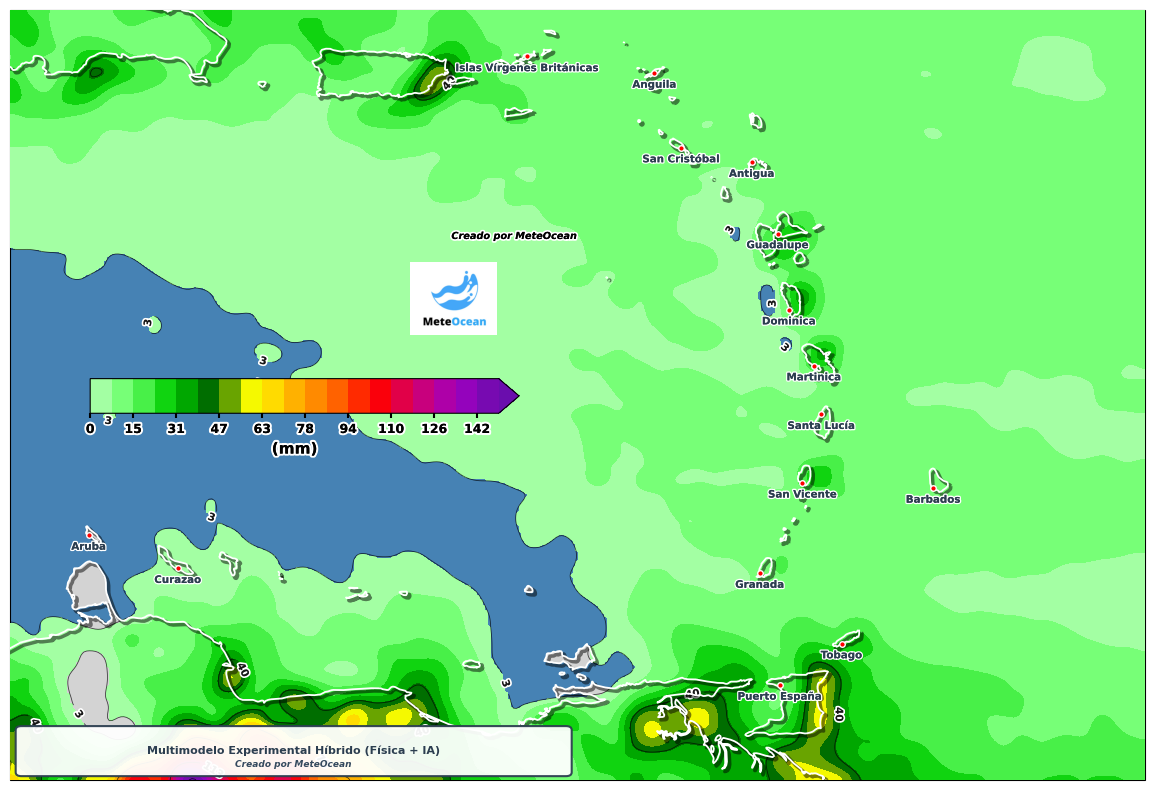

In [ ]:
#-----ANTILLAS MENORES - PRECIPITACIÓN MULTIMODELO----#
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import geopandas as gpd
import pandas as pd
from shapely.geometry import Point
from scipy.interpolate import griddata
from scipy.spatial import KDTree
import matplotlib.patheffects as PathEffects
import matplotlib.colors as mcolors
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.image as mpimg
from scipy.ndimage import gaussian_filter
import os
from matplotlib.patches import FancyBboxPatch

def graficar_precipitacion_dataarray(precip_dataarray, gdf_estados=None, mostrar_logo=True):
    """
    Grafica precipitación acumulada para las Antillas Menores y muestra automáticamente la figura en Colab.
    Ajusta dinámicamente el rango de colores según el valor máximo de precipitación.
    """
    if gdf_estados is None:
        raise ValueError("Debe proporcionar 'gdf_estados'")

    # Filtrar países de las Antillas Menores
    paises = ['Antigua and Barbuda', 'Dominica', 'Saint Lucia', 'Saint Vincent and the Grenadines',
              'Grenada', 'Barbados', 'Trinidad and Tobago', 'Saint Kitts and Nevis',
              'Martinique', 'Guadeloupe', 'Montserrat', 'Anguilla',
              'British Virgin Islands', 'United States Virgin Islands', 'Aruba',
              'Curaçao', 'Sint Maarten', 'Saint Barthélemy', 'Bonaire',
              'France']  # Agregar Francia para territorios franceses

    antillas_menores = gdf_estados[gdf_estados['admin'].isin(paises)].copy()

    # --- PARÁMETROS DE ÁREA ---
    lon_min_deg = -71
    lon_max_deg = -57
    lat_min = 9.5
    lat_max = 19

    # --- VERIFICAR COORDENADAS ---
    if 'longitude' not in precip_dataarray.coords or 'latitude' not in precip_dataarray.coords:
        raise ValueError("Input DataArray must have 'longitude' and 'latitude' coordinates.")

    # --- EXTRAER COORDENADAS ---
    lon_orig = precip_dataarray.longitude.values
    lat_orig = precip_dataarray.latitude.values

    print(f"Coordenadas originales:")
    print(f"  LON: [{lon_orig.min():.2f}, {lon_orig.max():.2f}] - {len(lon_orig)} puntos")
    print(f"  LAT: [{lat_orig.min():.2f}, {lat_orig.max():.2f}] - {len(lat_orig)} puntos")
    print(f"  Orden LAT: {'Descendente (N→S)' if lat_orig[0] > lat_orig[-1] else 'Ascendente (S→N)'}")

    precip_corrected = precip_dataarray

    # --- SELECCIONAR ÁREA ---
    if lat_orig[0] > lat_orig[-1]:
        precip_area = precip_corrected.sel(latitude=slice(lat_max, lat_min),
                                           longitude=slice(lon_min_deg, lon_max_deg))
    else:
        precip_area = precip_corrected.sel(latitude=slice(lat_min, lat_max),
                                           longitude=slice(lon_min_deg, lon_max_deg))

    lat = precip_area.latitude.values
    lon = precip_area.longitude.values

    print(f"\nÁrea seleccionada:")
    print(f"  LON: [{lon.min():.2f}, {lon.max():.2f}] - {len(lon)} puntos")
    print(f"  LAT: [{lat.min():.2f}, {lat.max():.2f}] - {len(lat)} puntos")

    if len(lon) == 0 or len(lat) == 0:
        raise ValueError(f"El área seleccionada está vacía. Verifica los límites: LON[{lon_min_deg},{lon_max_deg}], LAT[{lat_min},{lat_max}]")

    precip_vals = precip_area.values[0, :, :] if precip_area.values.ndim == 3 else precip_area.values
    print(f"  Precipitación: Min={precip_vals.min():.2f}, Max={precip_vals.max():.2f}, Mean={precip_vals.mean():.2f} mm")

    # --- MALLA ORIGINAL ---
    lon2d, lat2d = np.meshgrid(lon, lat)

    # --- INTERPOLACIÓN A REJILLA MÁS FINA ---
    lon_fine = np.linspace(lon.min(), lon.max(), 400)
    lat_fine = np.linspace(lat.min(), lat.max(), 400)
    lon2d_fine, lat2d_fine = np.meshgrid(lon_fine, lat_fine)
    points_orig = np.column_stack((lon2d.ravel(), lat2d.ravel()))
    values_orig = precip_vals.ravel()
    precip_fine = griddata(points_orig, values_orig, (lon2d_fine, lat2d_fine), method='cubic')

    # --- SUAVIZADO GAUSSIANO ---
    precip_fine_smooth = gaussian_filter(precip_fine, sigma=2)

    # --- MÁSCARA ---
    umbral_precip = 3
    precip_masked_fine = np.where(precip_fine_smooth > umbral_precip, precip_fine_smooth, np.nan)

    # --- RANGO DE COLOR DINÁMICO ---
    precip_max = np.nanmax(precip_fine_smooth)
    print(f"Precipitación máxima: {precip_max:.2f} mm")

    if precip_max < 50:
        vmin_colorbar, vmax_colorbar = 1, 50
    elif 50 <= precip_max < 100:
        vmin_colorbar, vmax_colorbar = 0, 100
    else:
        vmin_colorbar, vmax_colorbar = 0, 150

    levels = np.linspace(vmin_colorbar, vmax_colorbar, 20)

    # --- CREAR FIGURA ---
    fig = plt.figure(figsize=(18, 10))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.set_extent([lon_min_deg, lon_max_deg, lat_min, lat_max], crs=ccrs.PlateCarree())

    # --- TERRITORIO ---
    ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=1)
    ax.add_feature(cfeature.OCEAN, facecolor='steelblue', zorder=1)
    lakes_feature = cfeature.NaturalEarthFeature('physical', 'lakes', '10m', edgecolor='black', facecolor='steelblue')
    ax.add_feature(lakes_feature, linewidth=0.5, zorder=2)

    # No dibujar fronteras internas, solo costas

    # --- COLORES ---
    colors_precip = [
        '#b6ffb6', '#66ff66', '#00cc00', '#006400', '#ffff00', '#ffb300',
        '#ff6600', '#ff0000', '#d00070', '#a000c0', '#6a0dad'
    ]
    cmap_precip = mcolors.LinearSegmentedColormap.from_list('precipitacion', colors_precip)

    # --- CONTORNO DE PRECIPITACIÓN ---
    cf = ax.contourf(
        lon2d_fine, lat2d_fine, precip_masked_fine,
        levels=levels, cmap=cmap_precip, extend='max',
        transform=ccrs.PlateCarree(), zorder=3
    )

    # --- ISOLÍNEAS ---
    contour_levels = np.unique(np.round(np.linspace(max(umbral_precip, vmin_colorbar), vmax_colorbar, 5)).astype(int))
    cs = ax.contour(
        lon2d_fine, lat2d_fine, precip_fine_smooth,
        levels=contour_levels, colors='black', linewidths=0.6,
        alpha=0.7, transform=ccrs.PlateCarree(), zorder=4
    )
    labels = ax.clabel(cs, inline=True, fontsize=7.5, fmt='%d', inline_spacing=8)
    for label in labels:
        label.set_fontweight('bold')
        label.set_path_effects([
            PathEffects.withStroke(linewidth=2.5, foreground='white'),
            PathEffects.Normal()
        ])

    # --- COSTA CON SOMBRA ---
    coastline_feature = cfeature.NaturalEarthFeature('physical', 'coastline', '10m')
    coastline_geoms = list(coastline_feature.geometries())
    ax.add_geometries(coastline_geoms, crs=ccrs.PlateCarree(),
                      edgecolor='black', facecolor='none', linewidth=2.5, alpha=0.3,
                      path_effects=[PathEffects.SimpleLineShadow(offset=(2, -2), alpha=0.5)],
                      zorder=6)
    ax.add_geometries(coastline_geoms, crs=ccrs.PlateCarree(),
                      edgecolor='white', facecolor='none', linewidth=1.3,
                      path_effects=[PathEffects.Normal()], zorder=7)

    # --- BARRA DE COLOR ---
    cax = inset_axes(ax, width="42%", height="5%", loc='lower left',
                     bbox_to_anchor=(-0.015, 0.35, 0.9, 0.9),
                     bbox_transform=ax.transAxes, borderpad=7)
    cbar = plt.colorbar(cf, cax=cax, orientation='horizontal')
    cbar.set_label("(mm)", fontsize=11, weight='bold')
    label_obj = cbar.ax.xaxis.get_label()
    label_obj.set_path_effects([
        PathEffects.withStroke(linewidth=3, foreground='white'),
        PathEffects.Normal()
    ])
    cbar.ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x)}'))
    cbar.ax.tick_params(labelsize=9, colors='black', width=1.5)
    for label in cbar.ax.get_xticklabels():
        label.set_fontweight('bold')
        label.set_path_effects([
            PathEffects.withStroke(linewidth=3, foreground='white'),
            PathEffects.Normal()
        ])

    # --- CIUDADES ---
    ciudades_principales = {
        # Islas Vírgenes
        "Islas Vírgenes Británicas": {'lat': 18.43, 'lon': -64.62},

        # Islas de Sotavento (Norte)
        "Anguila": {'lat': 18.22, 'lon': -63.05},

        # Saint Kitts y Nevis
        "San Cristóbal": {'lat': 17.30, 'lon': -62.72},

        # Antigua y Barbuda
        "Antigua": {'lat': 17.12, 'lon': -61.85},

        # Guadeloupe
        "Guadalupe": {'lat': 16.24, 'lon': -61.53},

        # Dominica
        "Dominica": {'lat': 15.30, 'lon': -61.39},

        # Martinique
        "Martinica": {'lat': 14.61, 'lon': -61.08},

        # Saint Lucia
        "Santa Lucía": {'lat': 14.01, 'lon': -60.99},

        # Saint Vincent y Grenadinas
        "San Vicente": {'lat': 13.1633, 'lon': -61.2233},

        # Barbados
        "Barbados": {'lat': 13.10, 'lon': -59.61},

        # Grenada
        "Granada": {'lat': 12.05, 'lon': -61.75},

        # Trinidad y Tobago
        "Puerto España": {'lat': 10.6702, 'lon': -61.5038},
        "Tobago": {'lat': 11.18, 'lon': -60.74},

        # Islas ABC (Antillas Neerlandesas)
        "Aruba": {'lat': 12.52, 'lon': -70.03},
        "Curazao": {'lat': 12.11, 'lon': -68.93}
    }

    flat_points = np.column_stack((lat2d_fine.ravel(), lon2d_fine.ravel()))
    tree = KDTree(flat_points)
    precip_values = precip_fine_smooth.ravel()

    for nombre, datos in ciudades_principales.items():
        lat_ci, lon_ci = datos['lat'], datos['lon']
        _, idx = tree.query([lat_ci, lon_ci])
        precip = precip_values[idx]

        ax.plot(lon_ci, lat_ci, 'o',
                color='red', markersize=4,
                markeredgecolor='white', markeredgewidth=1,
                transform=ccrs.PlateCarree(), zorder=12)

        ax.text(
            lon_ci, lat_ci - 0.08, nombre,
            fontsize=7.4, color='#2C3E50', weight='bold',
            ha='center', va='top', zorder=15,
            transform=ccrs.PlateCarree(),
            path_effects=[
                PathEffects.withStroke(linewidth=2, foreground='white'),
                PathEffects.SimpleLineShadow(offset=(1, -1), alpha=0.3),
                PathEffects.Normal()
            ]
        )

    # --- LOGO ---
    if mostrar_logo:
        try:
            logo_img = mpimg.imread("/content/drive/My Drive/Logo.png")
            axins_logo = inset_axes(ax, width="9.5%", height="9.5%", loc='lower right',
                                    bbox_to_anchor=(-0.55, 0.56, 1, 1),
                                    bbox_transform=ax.transAxes, borderpad=1)
            axins_logo.imshow(logo_img)
            axins_logo.axis('off')
        except:
            print("Logo no encontrado")

    # Crédito
    ax.text(0.5, 0.7, 'Creado por MeteOcean',
            transform=ax.transAxes, fontsize=7, ha='right', va='bottom',
            color='black', fontstyle='italic', fontweight='bold',
            path_effects=[
                PathEffects.withStroke(linewidth=2.5, foreground='white'),
                PathEffects.Normal()
            ])

    # --- BANNER ---
    banner_box = FancyBboxPatch(
        (0.01, 0.01), 0.48, 0.055,
        boxstyle="round,pad=0.005",
        transform=ax.transAxes,
        facecolor='white',
        edgecolor='#2C3E50',
        linewidth=1.5,
        alpha=0.95,
        zorder=20
    )
    ax.add_patch(banner_box)
    ax.text(0.25, 0.0375, 'Multimodelo Experimental Híbrido (Física + IA)',
            transform=ax.transAxes, fontsize=8, ha='center', va='center',
            color='#2C3E50', fontweight='bold', zorder=21)
    ax.text(0.25, 0.02, 'Creado por MeteOcean',
            transform=ax.transAxes, fontsize=6.5, ha='center', va='center',
            color='#34495E', fontstyle='italic', fontweight='semibold', zorder=21)

    # --- GUARDAR ---
    output_dir = "/content/drive/My Drive/Colab Notebooks/mapas/precipitacion"
    os.makedirs(output_dir, exist_ok=True)
    plt.savefig(f"{output_dir}/antillas_menores_mapa_precipitacion_multimodelo.png", dpi=800, bbox_inches='tight')

    # --- MOSTRAR AUTOMÁTICAMENTE EN COLAB ---
    plt.show()

    return fig, ax

# --- USO ---
print("🌧️ Generando mapa de PRECIPITACIÓN para las Antillas Menores...")
fig, ax = graficar_precipitacion_dataarray(ds_multi, gdf_estados=gdf_estados)

✅ Municipios de Puerto Rico cargados
Coordenadas originales:
 LON: [-180.00, 179.75] - 1440 puntos
 LAT: [-90.00, 90.00] - 721 puntos
 Orden LAT: Ascendente (S→N)

Área seleccionada:
 LON: [-68.00, -65.00] - 13 puntos
 LAT: [17.25, 20.00] - 12 puntos
 Precipitación (en pulgadas): Min=0.20, Max=2.11, Mean=0.58
✅ Mapa guardado: /content/drive/My Drive/Colab Notebooks/mapas/precipitacion/puerto_rico_mapa_precipitacion_multimodelo_pulgadas.png


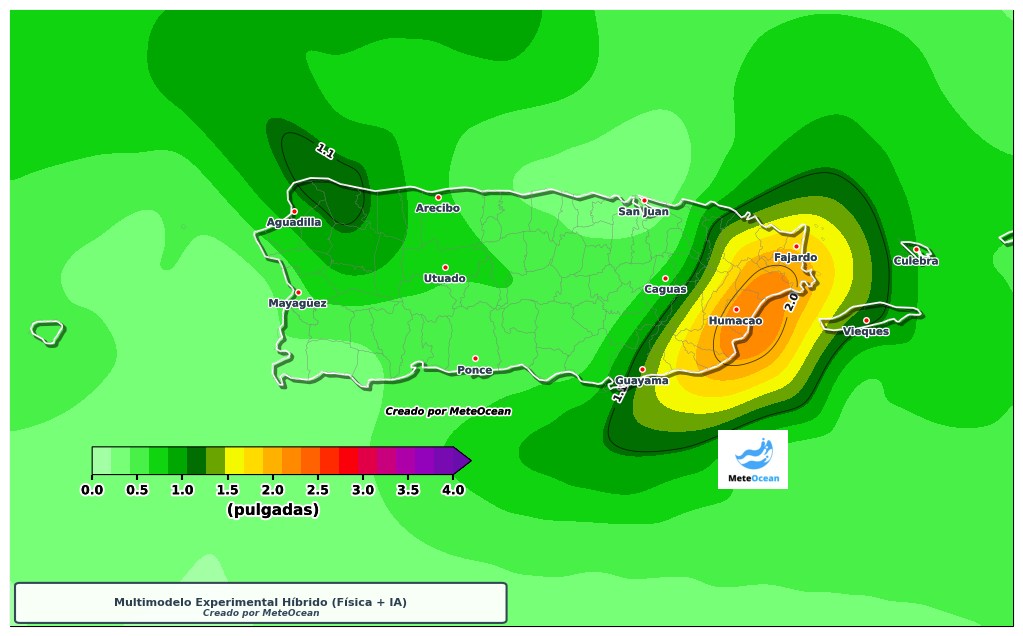

In [ ]:
#----PUERTO RICO - PRECIPITACIÓN MULTIMODELO (EN PULGADAS)----#
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import geopandas as gpd
from shapely.geometry import Point
from scipy.interpolate import griddata
from scipy.spatial import KDTree
import matplotlib.patheffects as PathEffects
import matplotlib.colors as mcolors
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.image as mpimg
from scipy.ndimage import gaussian_filter
import os
from matplotlib.patches import FancyBboxPatch

def graficar_precipitacion_puerto_rico(precip_dataarray, gdf_estados=None, municipios_pr=None, mostrar_logo=True):
    """
    Grafica precipitación acumulada para Puerto Rico.
    Ajusta dinámicamente el rango de colores según el valor máximo de precipitación.
    La precipitación se muestra tanto sobre tierra como sobre el mar.
    (Conversión de mm a pulgadas)

    Parámetros:
    -----------
    precip_dataarray : xarray.DataArray
        DataArray con precipitación en mm con coordenadas 'longitude' y 'latitude'
    gdf_estados : GeoDataFrame
        GeoDataFrame con todos los estados
    municipios_pr : GeoDataFrame
        GeoDataFrame con municipios de Puerto Rico (opcional)
    mostrar_logo : bool
        Si se muestra el logo (default: True)
    """

    if gdf_estados is None:
        raise ValueError("Debe proporcionar 'gdf_estados'")

    # --- FILTRAR PUERTO RICO ---
    puerto_rico = gdf_estados[gdf_estados['admin'] == 'Puerto Rico'].copy()

    # --- PARÁMETROS DE ÁREA (PUERTO RICO) ---
    lon_min_deg = -68.0
    lon_max_deg = -65
    lat_min = 17.25
    lat_max = 19.0

    # --- VERIFICAR COORDENADAS ---
    if 'longitude' not in precip_dataarray.coords or 'latitude' not in precip_dataarray.coords:
        raise ValueError("Input DataArray must have 'longitude' and 'latitude' coordinates.")

    # --- EXTRAER COORDENADAS ---
    lon_orig = precip_dataarray.longitude.values
    lat_orig = precip_dataarray.latitude.values

    print(f"Coordenadas originales:")
    print(f" LON: [{lon_orig.min():.2f}, {lon_orig.max():.2f}] - {len(lon_orig)} puntos")
    print(f" LAT: [{lat_orig.min():.2f}, {lat_orig.max():.2f}] - {len(lat_orig)} puntos")
    print(f" Orden LAT: {'Descendente (N→S)' if lat_orig[0] > lat_orig[-1] else 'Ascendente (S→N)'}")

    precip_corrected = precip_dataarray

    # --- SELECCIONAR ÁREA ---
    if lat_orig[0] > lat_orig[-1]:
        precip_area = precip_corrected.sel(
            latitude=slice(lat_max, lat_min),
            longitude=slice(lon_min_deg, lon_max_deg)
        )
    else:
        precip_area = precip_corrected.sel(
            latitude=slice(lat_min, lat_max+1),
            longitude=slice(lon_min_deg, lon_max_deg)
        )

    lat = precip_area.latitude.values
    lon = precip_area.longitude.values

    print(f"\nÁrea seleccionada:")
    print(f" LON: [{lon.min():.2f}, {lon.max():.2f}] - {len(lon)} puntos")
    print(f" LAT: [{lat.min():.2f}, {lat.max():.2f}] - {len(lat)} puntos")

    if len(lon) == 0 or len(lat) == 0:
        raise ValueError(f"El área seleccionada está vacía. Verifica los límites: LON[{lon_min_deg},{lon_max_deg}], LAT[{lat_min},{lat_max}]")

    precip_vals = precip_area.values[0, :, :] if precip_area.values.ndim == 3 else precip_area.values

    # --- CONVERTIR DE mm A PULGADAS ---
    precip_vals = precip_vals / 25.4

    print(f" Precipitación (en pulgadas): Min={precip_vals.min():.2f}, Max={precip_vals.max():.2f}, Mean={precip_vals.mean():.2f}")

    # --- MALLA ORIGINAL ---
    lon2d, lat2d = np.meshgrid(lon, lat)

    # --- INTERPOLACIÓN A REJILLA MÁS FINA ---
    lon_fine = np.linspace(lon.min(), lon.max(), 300)
    lat_fine = np.linspace(lat.min(), lat.max(), 300)
    lon2d_fine, lat2d_fine = np.meshgrid(lon_fine, lat_fine)

    points_orig = np.column_stack((lon2d.ravel(), lat2d.ravel()))
    values_orig = precip_vals.ravel()
    precip_fine = griddata(points_orig, values_orig, (lon2d_fine, lat2d_fine), method='cubic')

    # --- SUAVIZADO GAUSSIANO ---
    precip_fine_smooth = gaussian_filter(precip_fine, sigma=2)

    # --- MÁSCARA SOLO POR UMBRAL (sin restringir a tierra) ---
    umbral_precip = 0.1  #
    precip_masked_fine = np.where(precip_fine_smooth > umbral_precip, precip_fine_smooth, np.nan)

    # --- RANGO DE COLOR DINÁMICO (en pulgadas) ---
    precip_max = np.nanmax(precip_masked_fine)

    if precip_max < 2:
        vmin_colorbar, vmax_colorbar = 0, 2
    elif 2 <= precip_max < 4:
        vmin_colorbar, vmax_colorbar = 0, 4
    else:
        vmin_colorbar, vmax_colorbar = 0, 6

    levels = np.linspace(vmin_colorbar, vmax_colorbar, 20)

    # --- CREAR FIGURA ---
    fig = plt.figure(figsize=(16, 8))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.set_extent([lon_min_deg, lon_max_deg, lat_min, lat_max], crs=ccrs.PlateCarree())

    # --- TERRITORIO ---
    ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=1)
    ax.add_feature(cfeature.OCEAN, facecolor='steelblue', zorder=1)

    lakes_feature = cfeature.NaturalEarthFeature('physical', 'lakes', '10m',
                                                   edgecolor='black', facecolor='steelblue')
    ax.add_feature(lakes_feature, linewidth=0.5, zorder=2)

    # --- COLORES DE PRECIPITACIÓN ---
    colors_precip = [
        '#b6ffb6', '#66ff66', '#00cc00', '#006400', '#ffff00', '#ffb300',
        '#ff6600', '#ff0000', '#d00070', '#a000c0', '#6a0dad'
    ]
    cmap_precip = mcolors.LinearSegmentedColormap.from_list('precipitacion', colors_precip)

    # --- CONTORNO DE PRECIPITACIÓN ---
    cf = ax.contourf(
        lon2d_fine, lat2d_fine, precip_masked_fine,
        levels=levels, cmap=cmap_precip, extend='max',
        transform=ccrs.PlateCarree(), zorder=3
    )

    # --- ISOLÍNEAS ---
    contour_levels = np.unique(np.round(np.linspace(max(umbral_precip, vmin_colorbar), vmax_colorbar, 5), 2))
    cs = ax.contour(
        lon2d_fine, lat2d_fine, precip_fine_smooth,
        levels=contour_levels, colors='black', linewidths=0.6,
        alpha=0.7, transform=ccrs.PlateCarree(), zorder=4
    )

    labels = ax.clabel(cs, inline=True, fontsize=7.5, fmt='%.1f', inline_spacing=8)
    for label in labels:
        label.set_fontweight('bold')
        label.set_path_effects([
            PathEffects.withStroke(linewidth=2.5, foreground='white'),
            PathEffects.Normal()
        ])

    # --- COSTAS CON SOMBRA ---
    coastline_feature = cfeature.NaturalEarthFeature('physical', 'coastline', '10m')
    coastline_geoms = list(coastline_feature.geometries())
    ax.add_geometries(coastline_geoms, crs=ccrs.PlateCarree(),
                      edgecolor='black', facecolor='none', linewidth=2.5, alpha=0.3,
                      path_effects=[PathEffects.SimpleLineShadow(offset=(2, -2), alpha=0.5)],
                      zorder=6)
    ax.add_geometries(coastline_geoms, crs=ccrs.PlateCarree(),
                      edgecolor='white', facecolor='none', linewidth=1.3,
                      path_effects=[PathEffects.Normal()], zorder=7)

    # --- FRONTERA DE PUERTO RICO ---
    puerto_rico.boundary.plot(ax=ax, edgecolor='black', linewidth=0.7, zorder=5, transform=ccrs.PlateCarree())

    # --- MUNICIPIOS (si están disponibles) ---
    if municipios_pr is not None:
        municipios_pr.boundary.plot(ax=ax, edgecolor='grey', linewidth=0.2, alpha=0.8, zorder=8, transform=ccrs.PlateCarree())

    # --- BARRA DE COLOR ---
    cax = inset_axes(ax, width="42%", height="5%", loc='lower left',
                     bbox_to_anchor=(-0.015, 0.088, 0.9, 0.9),
                     bbox_transform=ax.transAxes, borderpad=7)
    cbar = plt.colorbar(
    cf, cax=cax, orientation='horizontal',
    ticks=np.arange(vmin_colorbar, vmax_colorbar + 0.5, 0.5)
)

    cbar.set_label("(pulgadas)", fontsize=11, weight='bold')

    label_obj = cbar.ax.xaxis.get_label()
    label_obj.set_path_effects([
        PathEffects.withStroke(linewidth=3, foreground='white'),
        PathEffects.Normal()
    ])

    cbar.ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1f}'))
    cbar.ax.tick_params(labelsize=9, colors='black', width=1.5)

    for label in cbar.ax.get_xticklabels():
        label.set_fontweight('bold')
        label.set_path_effects([
            PathEffects.withStroke(linewidth=3, foreground='white'),
            PathEffects.Normal()
        ])

    # --- CIUDADES PRINCIPALES DE PUERTO RICO ---
    ciudades_principales = {
        "San Juan": {'lat': 18.46, 'lon': -66.105},
        "Ponce": {'lat': 18.01, 'lon': -66.61},
        "Caguas": {'lat': 18.24, 'lon': -66.04},
        "Mayagüez": {'lat': 18.20, 'lon': -67.14},
        "Arecibo": {'lat': 18.47, 'lon': -66.72},
        "Fajardo": {'lat': 18.33, 'lon': -65.65},
        "Aguadilla": {'lat': 18.43, 'lon': -67.15},
        "Humacao": {'lat': 18.15, 'lon': -65.83},
        "Utuado": {'lat': 18.27, 'lon': -66.70},
        "Guayama": {'lat': 17.98, 'lon': -66.11},
        "Vieques": {'lat': 18.12, 'lon': -65.44},
        "Culebra": {'lat': 18.32, 'lon': -65.29},
    }

    flat_points = np.column_stack((lat2d_fine.ravel(), lon2d_fine.ravel()))
    tree = KDTree(flat_points)
    precip_values = precip_fine_smooth.ravel()

    for nombre, datos in ciudades_principales.items():
        lat_ci, lon_ci = datos['lat'], datos['lon']
        _, idx = tree.query([lat_ci, lon_ci])
        precip = precip_values[idx]

        ax.plot(lon_ci, lat_ci, 'o',
                color='red', markersize=4,
                markeredgecolor='white', markeredgewidth=1,
                transform=ccrs.PlateCarree(), zorder=12)

        ax.text(
            lon_ci, lat_ci - 0.02, nombre,
            fontsize=7.4, color='#2C3E50', weight='bold',
            ha='center', va='top', zorder=15,
            transform=ccrs.PlateCarree(),
            path_effects=[
                PathEffects.withStroke(linewidth=2, foreground='white'),
                PathEffects.SimpleLineShadow(offset=(1, -1), alpha=0.3),
                PathEffects.Normal()
            ]
        )

    # --- LOGO ---
    if mostrar_logo:
        try:
            logo_img = mpimg.imread("/content/drive/My Drive/Logo.png")
            axins_logo = inset_axes(ax, width="9.5%", height="9.5%", loc='lower right',
                                    bbox_to_anchor=(-0.198, 0.2, 1, 1),
                                    bbox_transform=ax.transAxes, borderpad=1)
            axins_logo.imshow(logo_img)
            axins_logo.axis('off')
        except:
            print("⚠️ Logo no encontrado en /content/drive/My Drive/Logo.png")

    # Crédito
    ax.text(0.5, 0.34, 'Creado por MeteOcean',
            transform=ax.transAxes, fontsize=7, ha='right', va='bottom',
            color='black', fontstyle='italic', fontweight='bold',
            path_effects=[
                PathEffects.withStroke(linewidth=2.5, foreground='white'),
                PathEffects.Normal()
            ])

    # --- BANNER ---
    banner_box = FancyBboxPatch(
        (0.01, 0.01), 0.48, 0.055,
        boxstyle="round,pad=0.005",
        transform=ax.transAxes,
        facecolor='white',
        edgecolor='#2C3E50',
        linewidth=1.5,
        alpha=0.95,
        zorder=20
    )
    ax.add_patch(banner_box)

    ax.text(0.25, 0.0375, 'Multimodelo Experimental Híbrido (Física + IA)',
            transform=ax.transAxes, fontsize=8, ha='center', va='center',
            color='#2C3E50', fontweight='bold', zorder=21)

    ax.text(0.25, 0.02, 'Creado por MeteOcean',
            transform=ax.transAxes, fontsize=6.5, ha='center', va='center',
            color='#34495E', fontstyle='italic', fontweight='semibold', zorder=21)

    # --- GUARDAR ---
    output_dir = "/content/drive/My Drive/Colab Notebooks/mapas/precipitacion"
    os.makedirs(output_dir, exist_ok=True)
    plt.savefig(f"{output_dir}/puerto_rico_mapa_precipitacion_multimodelo_pulgadas.png",
                dpi=800, bbox_inches='tight')
    print(f"✅ Mapa guardado: {output_dir}/puerto_rico_mapa_precipitacion_multimodelo_pulgadas.png")

    plt.show()

    return fig, ax


# --- CARGAR MUNICIPIOS (OPCIONAL) ---
try:
    municipios_pr = gpd.read_file("/content/drive/MyDrive/Colab Notebooks/cb_2018_us_county_500k/cb_2018_us_county_500k.shp")
    municipios_pr = municipios_pr[municipios_pr['STATEFP'] == '72']
    print("✅ Municipios de Puerto Rico cargados")
except:
    print("⚠️ Municipios no encontrados, se continuará sin ellos")
    municipios_pr = None

# --- USO ---
# Asegúrate de tener cargado gdf_estados y ds_multimodelo de tu clase MultiModeloMeteorologico
fig, ax = graficar_precipitacion_puerto_rico(ds_multi, gdf_estados=gdf_estados, municipios_pr=municipios_pr)


Coordenadas originales:
 LON: [-180.00, 179.75] - 1440 puntos
 LAT: [-90.00, 90.00] - 721 puntos
 Orden LAT: Ascendente (S→N)

Área seleccionada:
 LON: [-80.00, -58.00] - 89 puntos
 LAT: [0.50, 14.00] - 55 puntos
 Precipitación: Min=0.08, Max=304.73, Mean=73.62 mm


/tmp/ipykernel_8442/1707912405.py:179: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  fronteras = gdf_pais.unary_union.boundary
/tmp/ipykernel_8442/1707912405.py:179: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  fronteras = gdf_pais.unary_union.boundary


✅ Mapa guardado: /content/drive/My Drive/Colab Notebooks/mapas/precipitacion/colombia_venezuela_mapa_precipitacion_multimodelo.png


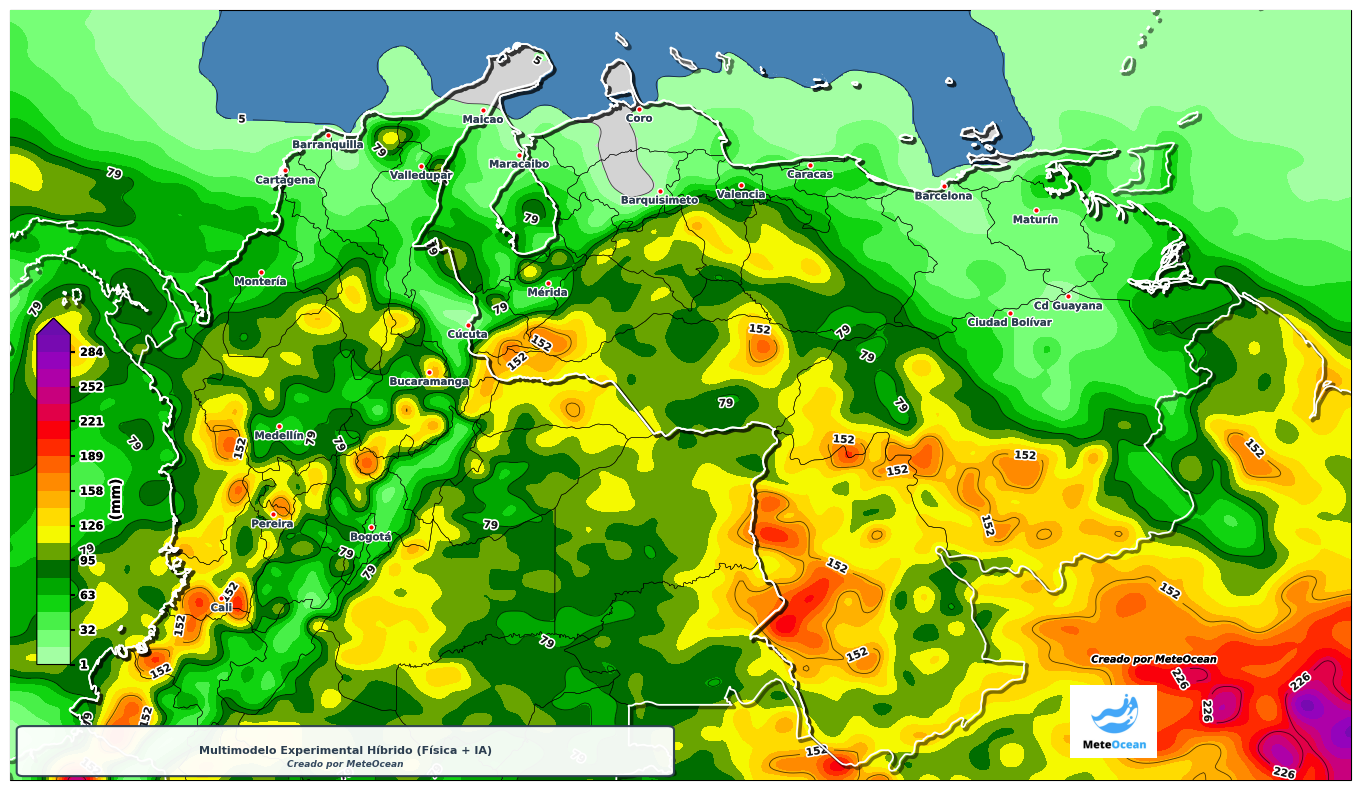

In [ ]:
#-----COLOMBIA Y VENEZUELA - PRECIPITACIÓN MULTIMODELO----#
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import geopandas as gpd
import pandas as pd
from shapely.geometry import Point
from scipy.interpolate import griddata
from scipy.spatial import KDTree
import matplotlib.patheffects as PathEffects
import matplotlib.colors as mcolors
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.image as mpimg
from scipy.ndimage import gaussian_filter
import os
from matplotlib.patches import FancyBboxPatch

def graficar_precipitacion_colombia_venezuela(precip_dataarray, gdf_estados=None, mostrar_logo=True):
    """
    Grafica precipitación acumulada para Colombia y Venezuela.
    Ajusta dinámicamente el rango de colores según el valor máximo de precipitación.
    La precipitación se muestra tanto sobre tierra como sobre el mar.

    Parámetros:
    -----------
    precip_dataarray : xarray.DataArray
        DataArray con precipitación en mm con coordenadas 'longitude' y 'latitude'
    gdf_estados : GeoDataFrame
        GeoDataFrame con todos los estados
    mostrar_logo : bool
        Si se muestra el logo (default: True)
    """

    if gdf_estados is None:
        raise ValueError("Debe proporcionar 'gdf_estados'")

    # Filtrar países de Colombia y Venezuela
    paises = ['Colombia', 'Venezuela']
    gdf_cv = gdf_estados[gdf_estados['admin'].isin(paises)].copy()

    # --- PARÁMETROS DE ÁREA ---
    lon_min_deg = -80
    lon_max_deg = -58
    lat_min = 0.5
    lat_max = 13

    # --- VERIFICAR COORDENADAS ---
    if 'longitude' not in precip_dataarray.coords or 'latitude' not in precip_dataarray.coords:
        raise ValueError("Input DataArray must have 'longitude' and 'latitude' coordinates.")

    # --- EXTRAER COORDENADAS ---
    lon_orig = precip_dataarray.longitude.values
    lat_orig = precip_dataarray.latitude.values

    print(f"Coordenadas originales:")
    print(f" LON: [{lon_orig.min():.2f}, {lon_orig.max():.2f}] - {len(lon_orig)} puntos")
    print(f" LAT: [{lat_orig.min():.2f}, {lat_orig.max():.2f}] - {len(lat_orig)} puntos")
    print(f" Orden LAT: {'Descendente (N→S)' if lat_orig[0] > lat_orig[-1] else 'Ascendente (S→N)'}")

    precip_corrected = precip_dataarray

    # --- SELECCIONAR ÁREA ---
    if lat_orig[0] > lat_orig[-1]:
        precip_area = precip_corrected.sel(
            latitude=slice(lat_max+1, lat_min),
            longitude=slice(lon_min_deg, lon_max_deg)
        )
    else:
        precip_area = precip_corrected.sel(
            latitude=slice(lat_min, lat_max+1),
            longitude=slice(lon_min_deg, lon_max_deg)
        )

    lat = precip_area.latitude.values
    lon = precip_area.longitude.values

    print(f"\nÁrea seleccionada:")
    print(f" LON: [{lon.min():.2f}, {lon.max():.2f}] - {len(lon)} puntos")
    print(f" LAT: [{lat.min():.2f}, {lat.max():.2f}] - {len(lat)} puntos")

    if len(lon) == 0 or len(lat) == 0:
        raise ValueError(f"El área seleccionada está vacía. Verifica los límites: LON[{lon_min_deg},{lon_max_deg}], LAT[{lat_min},{lat_max}]")

    precip_vals = precip_area.values[0, :, :] if precip_area.values.ndim == 3 else precip_area.values
    print(f" Precipitación: Min={precip_vals.min():.2f}, Max={precip_vals.max():.2f}, Mean={precip_vals.mean():.2f} mm")

    # --- MALLA ORIGINAL ---
    lon2d, lat2d = np.meshgrid(lon, lat)

    # --- INTERPOLACIÓN A REJILLA MÁS FINA ---
    lon_fine = np.linspace(lon.min(), lon.max(), 400)
    lat_fine = np.linspace(lat.min(), lat.max(), 400)
    lon2d_fine, lat2d_fine = np.meshgrid(lon_fine, lat_fine)

    points_orig = np.column_stack((lon2d.ravel(), lat2d.ravel()))
    values_orig = precip_vals.ravel()
    precip_fine = griddata(points_orig, values_orig, (lon2d_fine, lat2d_fine), method='cubic')

    # --- SUAVIZADO GAUSSIANO ---
    precip_fine_smooth = gaussian_filter(precip_fine, sigma=2)

    # --- MÁSCARA SOLO POR UMBRAL (sin restringir a tierra) ---
    umbral_precip = 5
    precip_masked_fine = np.where(precip_fine_smooth > umbral_precip, precip_fine_smooth, np.nan)

    # --- RANGO DE COLOR DINÁMICO ---
    precip_max = np.nanmax(precip_masked_fine)

    if precip_max < 50:
        vmin_colorbar, vmax_colorbar = 1, 50
    elif 50 <= precip_max < 100:
        vmin_colorbar, vmax_colorbar = 0, 100
    elif 100 <= precip_max < 150:
        vmin_colorbar, vmax_colorbar = 0, 200
    else:
        vmin_colorbar, vmax_colorbar = 1, 300

    levels = np.linspace(vmin_colorbar, vmax_colorbar, 20)

    # --- CREAR FIGURA ---
    fig = plt.figure(figsize=(18, 10))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.set_extent([lon_min_deg, lon_max_deg, lat_min, lat_max], crs=ccrs.PlateCarree())

    # --- TERRITORIO ---
    ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=1)
    ax.add_feature(cfeature.OCEAN, facecolor='steelblue', zorder=1)

    lakes_feature = cfeature.NaturalEarthFeature('physical', 'lakes', '10m',
                                                   edgecolor='black', facecolor='steelblue')
    ax.add_feature(lakes_feature, linewidth=0.5, zorder=2)

    # --- COLORES DE PRECIPITACIÓN ---
    colors_precip = [
        '#b6ffb6', '#66ff66', '#00cc00', '#006400', '#ffff00', '#ffb300',
        '#ff6600', '#ff0000', '#d00070', '#a000c0', '#6a0dad'
    ]
    cmap_precip = mcolors.LinearSegmentedColormap.from_list('precipitacion', colors_precip)

    # --- CONTORNO DE PRECIPITACIÓN (SOBRE TIERRA Y MAR) ---
    cf = ax.contourf(
        lon2d_fine, lat2d_fine, precip_masked_fine,
        levels=levels, cmap=cmap_precip, extend='max',
        transform=ccrs.PlateCarree(), zorder=3
    )

    # --- ISOLÍNEAS ---
    contour_levels = np.unique(np.round(np.linspace(max(umbral_precip, vmin_colorbar), vmax_colorbar, 5)).astype(int))
    cs = ax.contour(
        lon2d_fine, lat2d_fine, precip_fine_smooth,
        levels=contour_levels, colors='black', linewidths=0.6,
        alpha=0.7, transform=ccrs.PlateCarree(), zorder=4
    )

    labels = ax.clabel(cs, inline=True, fontsize=7.5, fmt='%d', inline_spacing=8)
    for label in labels:
        label.set_fontweight('bold')
        label.set_path_effects([
            PathEffects.withStroke(linewidth=2.5, foreground='white'),
            PathEffects.Normal()
        ])

    # --- COSTAS CON SOMBRA 3D ---
    coastline_feature = cfeature.NaturalEarthFeature('physical', 'coastline', '10m')
    coastline_geoms = list(coastline_feature.geometries())
    ax.add_geometries(coastline_geoms, crs=ccrs.PlateCarree(),
                      edgecolor='black', facecolor='none', linewidth=2.5, alpha=0.3,
                      path_effects=[PathEffects.SimpleLineShadow(offset=(2, -2), alpha=0.5)],
                      zorder=6)
    ax.add_geometries(coastline_geoms, crs=ccrs.PlateCarree(),
                      edgecolor='white', facecolor='none', linewidth=1.3,
                      path_effects=[PathEffects.Normal()], zorder=7)

    # --- FRONTERAS PAÍSES CON EFECTO 3D ---
    for pais in paises:
        gdf_pais = gdf_cv[gdf_cv['admin'] == pais]
        if len(gdf_pais) > 0:
            fronteras = gdf_pais.unary_union.boundary
            ax.add_geometries([fronteras], crs=ccrs.PlateCarree(),
                              edgecolor='black', facecolor='none', linewidth=2.5, alpha=0.3,
                              path_effects=[PathEffects.SimpleLineShadow(offset=(2, -2), alpha=0.5)],
                              zorder=6)
            ax.add_geometries([fronteras], crs=ccrs.PlateCarree(),
                              edgecolor='white', facecolor='none', linewidth=1.3,
                              path_effects=[PathEffects.Normal()], zorder=7)

    # --- PROVINCIAS INTERNAS ---
    for pais in paises:
        provincias = gdf_cv[(gdf_cv['admin'] == pais) & (gdf_cv['type'] != 'Country')]
        if len(provincias) > 0:
            provincias.boundary.plot(ax=ax, edgecolor='black', linewidth=0.35,
                                      zorder=4, transform=ccrs.PlateCarree())

    # --- BARRA DE COLOR (VERTICAL, ESQUINA INFERIOR IZQUIERDA) ---
    cax = inset_axes(ax, width="2.5%", height="45%", loc='lower left',
                     bbox_to_anchor=(0.02, 0.15, 1, 1),
                     bbox_transform=ax.transAxes, borderpad=0)
    cbar = plt.colorbar(cf, cax=cax, orientation='vertical')
    cbar.set_label("(mm)", fontsize=10, weight='bold')

    label_obj = cbar.ax.yaxis.get_label()
    label_obj.set_path_effects([
        PathEffects.withStroke(linewidth=3, foreground='white'),
        PathEffects.Normal()
    ])

    cbar.ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x)}'))
    cbar.ax.tick_params(labelsize=8, colors='black', width=1.5)

    for label in cbar.ax.get_yticklabels():
        label.set_fontweight('bold')
        label.set_path_effects([
            PathEffects.withStroke(linewidth=3, foreground='white'),
            PathEffects.Normal()
        ])

    # --- CIUDADES PRINCIPALES DE COLOMBIA Y VENEZUELA ---
    ciudades_principales = {
        # Colombia
        "Bogotá": {'lat': 4.60971, 'lon': -74.08175},
        "Medellín": {'lat': 6.2442, 'lon': -75.5812},
        "Cali": {'lat': 3.4516, 'lon': -76.5320},
        "Barranquilla": {'lat': 10.9685, 'lon': -74.7813},
        "Montería": {'lat': 8.7471, 'lon': -75.8894},
        "Pereira": {'lat': 4.8143, 'lon': -75.6946},
        "Cúcuta": {'lat': 7.89, 'lon': -72.4963},
        "Cartagena": {'lat': 10.395, 'lon': -75.4833},
        "Valledupar": {'lat': 10.4719, 'lon': -73.2527},
        "Maicao": {'lat': 11.3775, 'lon': -72.2383},
        "Bucaramanga": {'lat': 7.1238, 'lon': -73.1216},
        # Venezuela
        "Caracas": {'lat': 10.4880, 'lon': -66.8792},
        "Maracaibo": {'lat': 10.6539, 'lon': -71.64597},
        "Valencia": {'lat': 10.1620, 'lon': -68.0077},
        "Maturín": {'lat': 9.7500, 'lon': -63.1800},
        "Barcelona": {'lat': 10.1363, 'lon': -64.6862},
        "Ciudad Bolívar": {'lat': 8.0833, 'lon': -63.6000},
        "Mérida": {'lat': 8.57, 'lon': -71.18},
        "Barquisimeto": {'lat': 10.0683, 'lon': -69.3452},
        "Coro": {'lat': 11.3980, 'lon': -69.6794},
        "Cd Guayana": {'lat': 8.3525, 'lon': -62.6430},
    }

    flat_points = np.column_stack((lat2d_fine.ravel(), lon2d_fine.ravel()))
    tree = KDTree(flat_points)
    precip_values = precip_fine_smooth.ravel()

    for nombre, datos in ciudades_principales.items():
        lat_ci, lon_ci = datos['lat'], datos['lon']
        _, idx = tree.query([lat_ci, lon_ci])
        precip = precip_values[idx]

        ax.plot(lon_ci, lat_ci, 'o',
                color='red', markersize=4,
                markeredgecolor='white', markeredgewidth=1,
                transform=ccrs.PlateCarree(), zorder=12)

        ax.text(
            lon_ci, lat_ci - 0.08, nombre,
            fontsize=7.4, color='#2C3E50', weight='bold',
            ha='center', va='top', zorder=15,
            transform=ccrs.PlateCarree(),
            path_effects=[
                PathEffects.withStroke(linewidth=2, foreground='white'),
                PathEffects.SimpleLineShadow(offset=(1, -1), alpha=0.3),
                PathEffects.Normal()
            ]
        )

    # --- LOGO ---
    if mostrar_logo:
        try:
            logo_img = mpimg.imread("/content/drive/My Drive/Logo.png")
            axins_logo = inset_axes(ax, width="9.5%", height="9.5%", loc='lower right',
                                    bbox_to_anchor=(-0.12, 0.01, 1, 1),
                                    bbox_transform=ax.transAxes, borderpad=1)
            axins_logo.imshow(logo_img)
            axins_logo.axis('off')
        except:
            print("⚠️ Logo no encontrado en /content/drive/My Drive/Logo.png")

    # Crédito
    ax.text(0.9, 0.15, 'Creado por MeteOcean',
            transform=ax.transAxes, fontsize=7, ha='right', va='bottom',
            color='black', fontstyle='italic', fontweight='bold',
            path_effects=[
                PathEffects.withStroke(linewidth=2.5, foreground='white'),
                PathEffects.Normal()
            ])

    # --- BANNER ---
    banner_box = FancyBboxPatch(
        (0.01, 0.01), 0.48, 0.055,
        boxstyle="round,pad=0.005",
        transform=ax.transAxes,
        facecolor='white',
        edgecolor='#2C3E50',
        linewidth=1.5,
        alpha=0.95,
        zorder=20
    )
    ax.add_patch(banner_box)

    ax.text(0.25, 0.0375, 'Multimodelo Experimental Híbrido (Física + IA)',
            transform=ax.transAxes, fontsize=8, ha='center', va='center',
            color='#2C3E50', fontweight='bold', zorder=21)

    ax.text(0.25, 0.02, 'Creado por MeteOcean',
            transform=ax.transAxes, fontsize=6.5, ha='center', va='center',
            color='#34495E', fontstyle='italic', fontweight='semibold', zorder=21)

    # --- GUARDAR ---
    output_dir = "/content/drive/My Drive/Colab Notebooks/mapas/precipitacion"
    os.makedirs(output_dir, exist_ok=True)
    plt.savefig(f"{output_dir}/colombia_venezuela_mapa_precipitacion_multimodelo.png",
                dpi=800, bbox_inches='tight')
    print(f"✅ Mapa guardado: {output_dir}/colombia_venezuela_mapa_precipitacion_multimodelo.png")

    # --- MOSTRAR AUTOMÁTICAMENTE EN COLAB ---
    plt.show()

    return fig, ax


# --- USO ---
# Asegúrate de tener cargado gdf_estados y ds_multimodelo de tu clase MultiModeloMeteorologico
fig, ax = graficar_precipitacion_colombia_venezuela(ds_multi, gdf_estados=gdf_estados)

Coordenadas originales:
 LON: [-180.00, 179.75] - 1440 puntos
 LAT: [-90.00, 90.00] - 721 puntos
 Orden LAT: Ascendente (S→N)

Área seleccionada:
 LON: [-125.00, -66.00] - 237 puntos
 LAT: [24.00, 51.00] - 109 puntos
 Precipitación: Min=0.00, Max=9.84, Mean=0.65 in


/tmp/ipykernel_8442/2225583217.py:182: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  fronteras = gdf_pais.unary_union.boundary
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_ocean.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


✅ Mapa guardado: /content/drive/My Drive/Colab Notebooks/mapas/precipitacion/estados_unidos_mapa_precipitacion_multimodelo.png


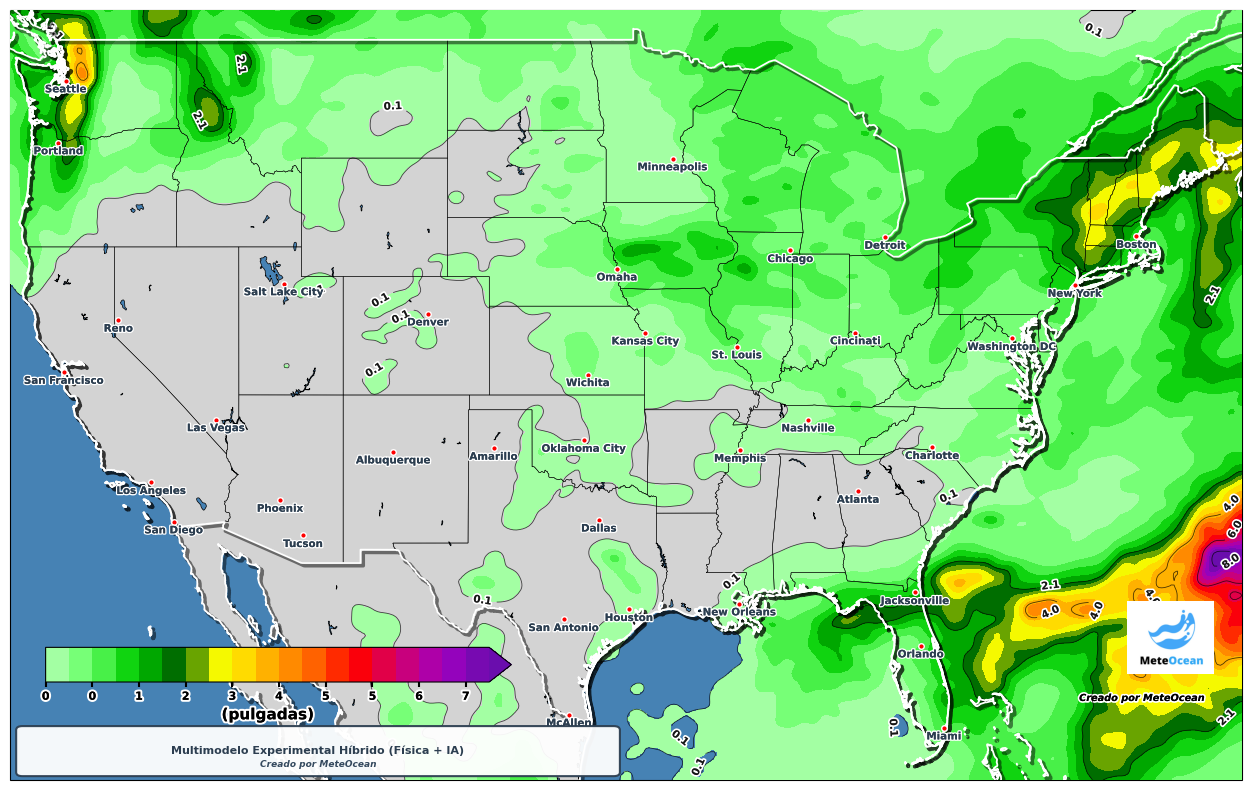

In [ ]:
#-----ESTADOS UNIDOS - PRECIPITACIÓN MULTIMODELO----#
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import geopandas as gpd
import pandas as pd
from shapely.geometry import Point
from scipy.interpolate import griddata
from scipy.spatial import KDTree
import matplotlib.patheffects as PathEffects
import matplotlib.colors as mcolors
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.image as mpimg
from scipy.ndimage import gaussian_filter
import os
from matplotlib.patches import FancyBboxPatch

def graficar_precipitacion_estados_unidos(precip_dataarray, gdf_estados=None, mostrar_logo=True):
    """
    Grafica precipitación acumulada para Estados Unidos.
    Ajusta dinámicamente el rango de colores según el valor máximo de precipitación.
    La precipitación se muestra tanto sobre tierra como sobre el mar.

    Parámetros:
    -----------
    precip_dataarray : xarray.DataArray
        DataArray con precipitación en mm con coordenadas 'longitude' y 'latitude'
    gdf_estados : GeoDataFrame
        GeoDataFrame con todos los estados
    mostrar_logo : bool
        Si se muestra el logo (default: True)
    """

    if gdf_estados is None:
        raise ValueError("Debe proporcionar 'gdf_estados'")

    # Filtrar Estados Unidos
    paises = ['United States of America']
    gdf_usa = gdf_estados[gdf_estados['admin'].isin(paises)].copy()

    # --- PARÁMETROS DE ÁREA (ESTADOS UNIDOS CONTINENTAL) ---
    lon_min_deg = -125
    lon_max_deg = -66
    lat_min = 24
    lat_max = 50

    # --- VERIFICAR COORDENADAS ---
    if 'longitude' not in precip_dataarray.coords or 'latitude' not in precip_dataarray.coords:
        raise ValueError("Input DataArray must have 'longitude' and 'latitude' coordinates.")

    # --- EXTRAER COORDENADAS ---
    lon_orig = precip_dataarray.longitude.values
    lat_orig = precip_dataarray.latitude.values

    print(f"Coordenadas originales:")
    print(f" LON: [{lon_orig.min():.2f}, {lon_orig.max():.2f}] - {len(lon_orig)} puntos")
    print(f" LAT: [{lat_orig.min():.2f}, {lat_orig.max():.2f}] - {len(lat_orig)} puntos")
    print(f" Orden LAT: {'Descendente (N→S)' if lat_orig[0] > lat_orig[-1] else 'Ascendente (S→N)'}")

    precip_corrected = precip_dataarray

    # --- SELECCIONAR ÁREA ---
    if lat_orig[0] > lat_orig[-1]:
        precip_area = precip_corrected.sel(
            latitude=slice(lat_max+1, lat_min),
            longitude=slice(lon_min_deg, lon_max_deg)
        )
    else:
        precip_area = precip_corrected.sel(
            latitude=slice(lat_min, lat_max+1),
            longitude=slice(lon_min_deg, lon_max_deg)
        )

    lat = precip_area.latitude.values
    lon = precip_area.longitude.values

    print(f"\nÁrea seleccionada:")
    print(f" LON: [{lon.min():.2f}, {lon.max():.2f}] - {len(lon)} puntos")
    print(f" LAT: [{lat.min():.2f}, {lat.max():.2f}] - {len(lat)} puntos")

    if len(lon) == 0 or len(lat) == 0:
        raise ValueError(f"El área seleccionada está vacía. Verifica los límites: LON[{lon_min_deg},{lon_max_deg}], LAT[{lat_min},{lat_max}]")

    precip_vals = precip_area.values[0, :, :] if precip_area.values.ndim == 3 else precip_area.values

    # --- CONVERTIR DE MILÍMETROS A PULGADAS ---
    precip_vals_inches = precip_vals / 25.4

    print(f" Precipitación: Min={precip_vals_inches.min():.2f}, Max={precip_vals_inches.max():.2f}, Mean={precip_vals_inches.mean():.2f} in")

    # --- MALLA ORIGINAL ---
    lon2d, lat2d = np.meshgrid(lon, lat)

    # --- INTERPOLACIÓN A REJILLA MÁS FINA ---
    lon_fine = np.linspace(lon.min(), lon.max(), 400)
    lat_fine = np.linspace(lat.min(), lat.max(), 400)
    lon2d_fine, lat2d_fine = np.meshgrid(lon_fine, lat_fine)

    points_orig = np.column_stack((lon2d.ravel(), lat2d.ravel()))
    values_orig = precip_vals_inches.ravel()
    precip_fine = griddata(points_orig, values_orig, (lon2d_fine, lat2d_fine), method='cubic')

    # --- SUAVIZADO GAUSSIANO ---
    precip_fine_smooth = gaussian_filter(precip_fine, sigma=2)

    # --- MÁSCARA SOLO POR UMBRAL (sin restringir a tierra) ---
    umbral_precip = 0.1      # 0.2 pulgadas (equivalente a 5 mm)
    precip_masked_fine = np.where(precip_fine_smooth > umbral_precip, precip_fine_smooth, np.nan)

    # --- RANGO DE COLOR DINÁMICO ---
    precip_max = np.nanmax(precip_masked_fine)

    if precip_max < 2:
        vmin_colorbar, vmax_colorbar = 0, 2
    elif 2 <= precip_max < 4:
        vmin_colorbar, vmax_colorbar = 0, 4
    else:
        vmin_colorbar, vmax_colorbar = 0, 8

    levels = np.linspace(vmin_colorbar, vmax_colorbar, 20)

    # --- CREAR FIGURA ---
    fig = plt.figure(figsize=(18, 10))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.set_extent([lon_min_deg, lon_max_deg, lat_min, lat_max], crs=ccrs.PlateCarree())

    # --- TERRITORIO ---
    ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=1)
    ax.add_feature(cfeature.OCEAN, facecolor='steelblue', zorder=1)

    # AGREGAR LAGOS
    lakes_feature = cfeature.NaturalEarthFeature('physical', 'lakes', '10m',
                                                   edgecolor='black', facecolor='steelblue')
    ax.add_feature(lakes_feature, linewidth=0.5, zorder=2)

    # --- COLORES DE PRECIPITACIÓN ---
    colors_precip = [
        '#b6ffb6', '#66ff66', '#00cc00', '#006400', '#ffff00', '#ffb300',
        '#ff6600', '#ff0000', '#d00070', '#a000c0', '#6a0dad'
    ]
    cmap_precip = mcolors.LinearSegmentedColormap.from_list('precipitacion', colors_precip)

    # --- CONTORNO DE PRECIPITACIÓN (SOBRE TIERRA Y MAR) ---
    cf = ax.contourf(
        lon2d_fine, lat2d_fine, precip_masked_fine,
        levels=levels, cmap=cmap_precip, extend='max',
        transform=ccrs.PlateCarree(), zorder=3
    )

    # --- ISOLÍNEAS ---
    contour_levels = np.unique(np.round(np.linspace(max(umbral_precip, vmin_colorbar), vmax_colorbar, 5), 1))
    cs = ax.contour(
        lon2d_fine, lat2d_fine, precip_fine_smooth,
        levels=contour_levels, colors='black', linewidths=0.6,
        alpha=0.7, transform=ccrs.PlateCarree(), zorder=4
    )

    labels = ax.clabel(cs, inline=True, fontsize=7.5, fmt='%.1f', inline_spacing=8)
    for label in labels:
        label.set_fontweight('bold')
        label.set_path_effects([
            PathEffects.withStroke(linewidth=2.5, foreground='white'),
            PathEffects.Normal()
        ])

    # --- COSTAS CON SOMBRA 3D ---
    coastline_feature = cfeature.NaturalEarthFeature('physical', 'coastline', '10m')
    coastline_geoms = list(coastline_feature.geometries())
    ax.add_geometries(coastline_geoms, crs=ccrs.PlateCarree(),
                      edgecolor='black', facecolor='none', linewidth=2.5, alpha=0.3,
                      path_effects=[PathEffects.SimpleLineShadow(offset=(2, -2), alpha=0.5)],
                      zorder=6)
    ax.add_geometries(coastline_geoms, crs=ccrs.PlateCarree(),
                      edgecolor='white', facecolor='none', linewidth=1.3,
                      path_effects=[PathEffects.Normal()], zorder=7)

    # --- FRONTERAS PAÍSES CON EFECTO 3D ---
    for pais in paises:
        gdf_pais = gdf_usa[gdf_usa['admin'] == pais]
        if len(gdf_pais) > 0:
            fronteras = gdf_pais.unary_union.boundary
            ax.add_geometries([fronteras], crs=ccrs.PlateCarree(),
                              edgecolor='black', facecolor='none', linewidth=2.5, alpha=0.3,
                              path_effects=[PathEffects.SimpleLineShadow(offset=(2, -2), alpha=0.5)],
                              zorder=6)
            ax.add_geometries([fronteras], crs=ccrs.PlateCarree(),
                              edgecolor='white', facecolor='none', linewidth=1.3,
                              path_effects=[PathEffects.Normal()], zorder=7)

    # --- ESTADOS INTERNOS ---
    for pais in paises:
        estados = gdf_usa[(gdf_usa['admin'] == pais) & (gdf_usa['type'] != 'Country')]
        if len(estados) > 0:
            estados.boundary.plot(ax=ax, edgecolor='black', linewidth=0.35,
                                      zorder=4, transform=ccrs.PlateCarree())

    # --- BARRA DE COLOR (HORIZONTAL) ---
    cax = inset_axes(ax, width="42%", height="5%", loc='lower left',
                     bbox_to_anchor=(-0.05, 0.001, 0.9, 0.9),
                     bbox_transform=ax.transAxes, borderpad=7)
    cbar = plt.colorbar(cf, cax=cax, orientation='horizontal')
    cbar.set_label("(pulgadas)", fontsize=11, weight='bold')

    label_obj = cbar.ax.xaxis.get_label()
    label_obj.set_path_effects([
        PathEffects.withStroke(linewidth=3, foreground='white'),
        PathEffects.Normal()
    ])

    cbar.ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x)}'))
    cbar.ax.tick_params(labelsize=8, colors='black', width=1.5)

    for label in cbar.ax.get_xticklabels():
        label.set_fontweight('bold')
        label.set_path_effects([
            PathEffects.withStroke(linewidth=3, foreground='white'),
            PathEffects.Normal()
        ])

    # --- CIUDADES PRINCIPALES DE ESTADOS UNIDOS ---
    ciudades_principales = {
        # Costa Oeste
        "Los Angeles": {'lat': 34.05, 'lon': -118.24},
        "San Francisco": {'lat': 37.77, 'lon': -122.42},
        "Seattle": {'lat': 47.61, 'lon': -122.33},
        "Portland": {'lat': 45.52, 'lon': -122.68},
        "San Diego": {'lat': 32.72, 'lon': -117.16},
        "Las Vegas": {'lat': 36.17, 'lon': -115.14},
        "Reno": {'lat': 39.5305, 'lon': -119.8130},
        # Suroeste
        "Phoenix": {'lat': 33.45, 'lon': -112.07},
        "Tucson": {'lat': 32.2566, 'lon': -110.9697},
        "Denver": {'lat': 39.74, 'lon': -104.99},
        "Albuquerque": {'lat': 35.08, 'lon': -106.65},
        "Salt Lake City": {'lat': 40.76, 'lon': -111.89},
        # Texas
        "Houston": {'lat': 29.76, 'lon': -95.37},
        "Dallas": {'lat': 32.78, 'lon': -96.80},
        "San Antonio": {'lat': 29.42, 'lon': -98.49},
        "McAllen": {'lat': 26.2066, 'lon': -98.2325},
        "Amarillo": {'lat': 35.205, 'lon': -101.8369},
        # Oklahoma
        "Oklahoma City": {'lat': 35.4738, 'lon': -97.5205},
        # Sureste
        "Miami": {'lat': 25.76, 'lon': -80.27},
        "Orlando": {'lat': 28.5308, 'lon': -81.3825},
        "Jacksonville": {'lat': 30.3316, 'lon': -81.6577},
        "Atlanta": {'lat': 33.75, 'lon': -84.39},
        "New Orleans": {'lat': 29.95, 'lon': -90.07},
        "Nashville": {'lat': 36.16, 'lon': -86.78},
        "Charlotte": {'lat': 35.23, 'lon': -80.84},
        # Costa Este
        "New York": {'lat': 40.71, 'lon': -74.01},
        "Boston": {'lat': 42.36, 'lon': -71.06},
        "Washington DC": {'lat': 38.91, 'lon': -77.04},
        # Medio Oeste
        "Chicago": {'lat': 41.88, 'lon': -87.63},
        "Detroit": {'lat': 42.33, 'lon': -83.1},
        "Minneapolis": {'lat': 44.98, 'lon': -93.27},
        "Kansas City": {'lat': 39.10, 'lon': -94.58},
        "Wichita": {'lat': 37.6916, 'lon': -97.3286},
        "Omaha": {'lat': 41.2591, 'lon': -95.9347},
        "Memphis": {'lat': 35.1402, 'lon': -90.0355},
        "Cincinati": {'lat': 39.1058, 'lon': -84.5141},
        "St. Louis": {'lat': 38.63, 'lon': -90.20}
    }

    flat_points = np.column_stack((lat2d_fine.ravel(), lon2d_fine.ravel()))
    tree = KDTree(flat_points)
    precip_values = precip_fine_smooth.ravel()

    for nombre, datos in ciudades_principales.items():
        lat_ci, lon_ci = datos['lat'], datos['lon']
        _, idx = tree.query([lat_ci, lon_ci])
        precip = precip_values[idx]

        ax.plot(lon_ci, lat_ci, 'o',
                color='red', markersize=4,
                markeredgecolor='white', markeredgewidth=1,
                transform=ccrs.PlateCarree(), zorder=12)

        ax.text(
            lon_ci, lat_ci - 0.12, nombre,
            fontsize=7.4, color='#2C3E50', weight='bold',
            ha='center', va='top', zorder=15,
            transform=ccrs.PlateCarree(),
            path_effects=[
                PathEffects.withStroke(linewidth=2, foreground='white'),
                PathEffects.SimpleLineShadow(offset=(1, -1), alpha=0.3),
                PathEffects.Normal()
            ]
        )

    # --- LOGO ---
    if mostrar_logo:
        try:
            logo_img = mpimg.imread("/content/drive/My Drive/Logo.png")
            axins_logo = inset_axes(ax, width="9.5%", height="9.5%", loc='lower right',
                                    bbox_to_anchor=(-0.0, 0.12, 1, 1),
                                    bbox_transform=ax.transAxes, borderpad=1)
            axins_logo.imshow(logo_img)
            axins_logo.axis('off')
        except:
            print("⚠️ Logo no encontrado en /content/drive/My Drive/Logo.png")

    # Crédito
    ax.text(0.97, 0.1, 'Creado por MeteOcean',
            transform=ax.transAxes, fontsize=7, ha='right', va='bottom',
            color='black', fontstyle='italic', fontweight='bold',
            path_effects=[
                PathEffects.withStroke(linewidth=2.5, foreground='white'),
                PathEffects.Normal()
            ])

    # --- BANNER ---
    banner_box = FancyBboxPatch(
        (0.01, 0.01), 0.48, 0.055,
        boxstyle="round,pad=0.005",
        transform=ax.transAxes,
        facecolor='white',
        edgecolor='#2C3E50',
        linewidth=1.5,
        alpha=0.95,
        zorder=20
    )
    ax.add_patch(banner_box)

    ax.text(0.25, 0.0375, 'Multimodelo Experimental Híbrido (Física + IA)',
            transform=ax.transAxes, fontsize=8, ha='center', va='center',
            color='#2C3E50', fontweight='bold', zorder=21)

    ax.text(0.25, 0.02, 'Creado por MeteOcean',
            transform=ax.transAxes, fontsize=6.5, ha='center', va='center',
            color='#34495E', fontstyle='italic', fontweight='semibold', zorder=21)

    # --- GUARDAR ---
    output_dir = "/content/drive/My Drive/Colab Notebooks/mapas/precipitacion"
    os.makedirs(output_dir, exist_ok=True)
    plt.savefig(f"{output_dir}/estados_unidos_mapa_precipitacion_multimodelo.png",
                dpi=800, bbox_inches='tight')
    print(f"✅ Mapa guardado: {output_dir}/estados_unidos_mapa_precipitacion_multimodelo.png")

    # --- MOSTRAR AUTOMÁTICAMENTE EN COLAB ---
    plt.show()

    return fig, ax


# --- USO ---
# Asegúrate de tener cargado gdf_estados y ds_multimodelo de tu clase MultiModeloMeteorologico
fig, ax = graficar_precipitacion_estados_unidos(ds_multi, gdf_estados=gdf_estados)

✅ 67 condados de Florida cargados
Coordenadas originales:
 LON: [-180.00, 179.75] - 1440 puntos
 LAT: [-90.00, 90.00] - 721 puntos
 Orden LAT: Ascendente (S→N)

Área seleccionada:
 LON: [-88.50, -77.50] - 45 puntos
 LAT: [23.50, 32.50] - 37 puntos
 Precipitación: Min=0.02, Max=4.46, Mean=0.95 in


/tmp/ipykernel_8442/2774852640.py:184: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  fronteras = gdf_florida.unary_union.boundary


✅ Dibujando 67 condados de Florida
✅ Mapa guardado: /content/drive/My Drive/Colab Notebooks/mapas/precipitacion/florida_mapa_precipitacion_multimodelo.png


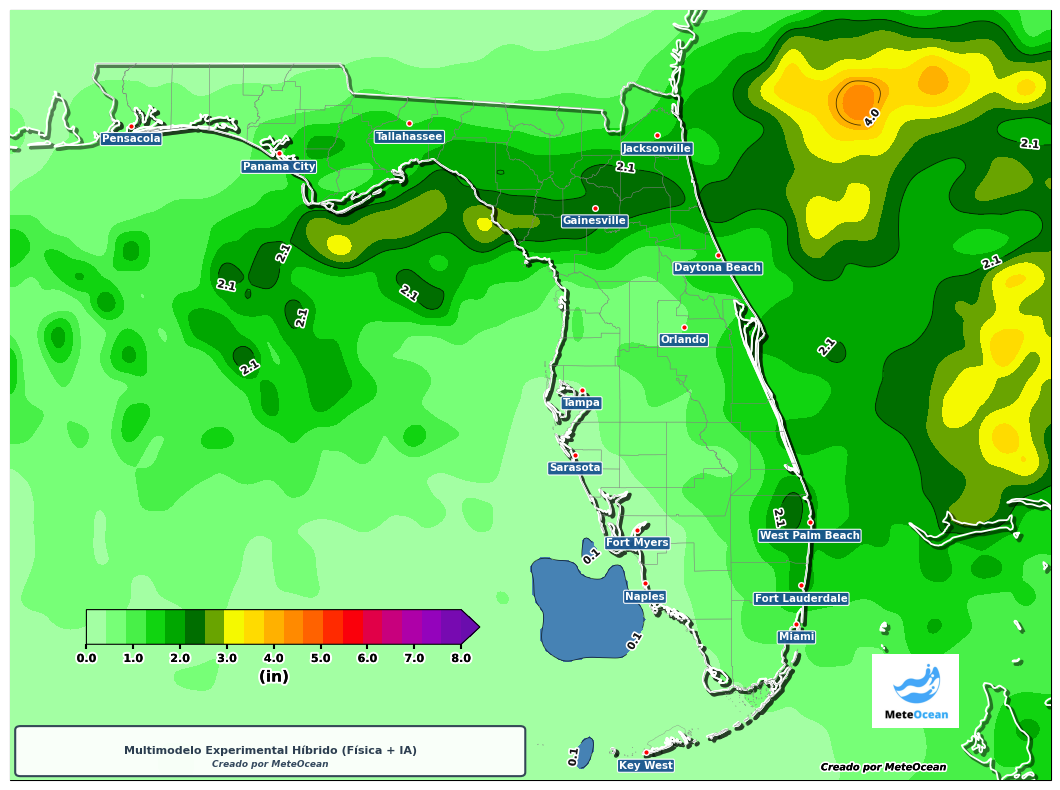

In [ ]:
#-----FLORIDA - PRECIPITACIÓN MULTIMODELO----#
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import geopandas as gpd
import pandas as pd
from shapely.geometry import Point
from scipy.interpolate import griddata
from scipy.spatial import KDTree
import matplotlib.patheffects as PathEffects
import matplotlib.colors as mcolors
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.image as mpimg
from scipy.ndimage import gaussian_filter
import os
from matplotlib.patches import FancyBboxPatch

def graficar_precipitacion_florida(precip_dataarray, gdf_estados=None, condados_florida=None, mostrar_logo=True):
    """
    Grafica precipitación acumulada para Florida en PULGADAS.
    Ajusta dinámicamente el rango de colores según el valor máximo de precipitación.
    La precipitación se muestra tanto sobre tierra como sobre el mar.

    Parámetros:
    -----------
    precip_dataarray : xarray.DataArray
        DataArray con precipitación en mm con coordenadas 'longitude' y 'latitude'
    gdf_estados : GeoDataFrame
        GeoDataFrame con todos los estados
    condados_florida : GeoDataFrame
        GeoDataFrame con condados de Florida (opcional)
    mostrar_logo : bool
        Si se muestra el logo (default: True)
    """

    if gdf_estados is None:
        raise ValueError("Debe proporcionar 'gdf_estados'")

    # Filtrar Florida
    gdf_florida = gdf_estados[
        (gdf_estados['admin'] == 'United States of America') &
        (gdf_estados['name'] == 'Florida')
    ].copy()

    # --- PARÁMETROS DE ÁREA (FLORIDA) ---
    lon_min_deg = -88.5
    lon_max_deg = -77.5
    lat_min = 24.3
    lat_max = 31.5

    # --- VERIFICAR COORDENADAS ---
    if 'longitude' not in precip_dataarray.coords or 'latitude' not in precip_dataarray.coords:
        raise ValueError("Input DataArray must have 'longitude' and 'latitude' coordinates.")

    # --- EXTRAER COORDENADAS ---
    lon_orig = precip_dataarray.longitude.values
    lat_orig = precip_dataarray.latitude.values

    print(f"Coordenadas originales:")
    print(f" LON: [{lon_orig.min():.2f}, {lon_orig.max():.2f}] - {len(lon_orig)} puntos")
    print(f" LAT: [{lat_orig.min():.2f}, {lat_orig.max():.2f}] - {len(lat_orig)} puntos")
    print(f" Orden LAT: {'Descendente (N→S)' if lat_orig[0] > lat_orig[-1] else 'Ascendente (S→N)'}")

    precip_corrected = precip_dataarray

    # --- SELECCIONAR ÁREA (EXTENDER 1 GRADO HACIA ABAJO) ---
    if lat_orig[0] > lat_orig[-1]:
        precip_area = precip_corrected.sel(
            latitude=slice(lat_max+1, lat_min-1),  # Extender 1 grado hacia abajo
            longitude=slice(lon_min_deg, lon_max_deg)
        )
    else:
        precip_area = precip_corrected.sel(
            latitude=slice(lat_min-1, lat_max+1),  # Extender 1 grado hacia abajo
            longitude=slice(lon_min_deg, lon_max_deg)
        )

    lat = precip_area.latitude.values
    lon = precip_area.longitude.values

    print(f"\nÁrea seleccionada:")
    print(f" LON: [{lon.min():.2f}, {lon.max():.2f}] - {len(lon)} puntos")
    print(f" LAT: [{lat.min():.2f}, {lat.max():.2f}] - {len(lat)} puntos")

    if len(lon) == 0 or len(lat) == 0:
        raise ValueError(f"El área seleccionada está vacía. Verifica los límites: LON[{lon_min_deg},{lon_max_deg}], LAT[{lat_min},{lat_max}]")

    precip_vals = precip_area.values[0, :, :] if precip_area.values.ndim == 3 else precip_area.values

    # --- CONVERTIR DE MILÍMETROS A PULGADAS ---
    precip_vals_inches = precip_vals / 25.4

    print(f" Precipitación: Min={precip_vals_inches.min():.2f}, Max={precip_vals_inches.max():.2f}, Mean={precip_vals_inches.mean():.2f} in")

    # --- MALLA ORIGINAL ---
    lon2d, lat2d = np.meshgrid(lon, lat)

    # --- INTERPOLACIÓN A REJILLA MÁS FINA ---
    lon_fine = np.linspace(lon.min(), lon.max(), 400)
    lat_fine = np.linspace(lat.min(), lat.max(), 400)
    lon2d_fine, lat2d_fine = np.meshgrid(lon_fine, lat_fine)

    points_orig = np.column_stack((lon2d.ravel(), lat2d.ravel()))
    values_orig = precip_vals_inches.ravel()
    precip_fine = griddata(points_orig, values_orig, (lon2d_fine, lat2d_fine), method='cubic')

    # --- SUAVIZADO GAUSSIANO ---
    precip_fine_smooth = gaussian_filter(precip_fine, sigma=2)

    # --- MÁSCARA SOLO POR UMBRAL (sin restringir a tierra) ---
    umbral_precip = 0.1  # 0.2 pulgadas (equivalente a ~5mm)
    precip_masked_fine = np.where(precip_fine_smooth > umbral_precip, precip_fine_smooth, np.nan)

    # --- RANGO DE COLOR DINÁMICO EN PULGADAS ---
    precip_max = np.nanmax(precip_masked_fine)

    if precip_max < 2:
        vmin_colorbar, vmax_colorbar = 0, 2
    elif 2 <= precip_max < 4:
        vmin_colorbar, vmax_colorbar = 0, 4
    else:
        vmin_colorbar, vmax_colorbar = 0, 8

    levels = np.linspace(vmin_colorbar, vmax_colorbar, 20)

    # --- CREAR FIGURA ---
    fig = plt.figure(figsize=(16, 10))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.set_extent([lon_min_deg, lon_max_deg, lat_min, lat_max], crs=ccrs.PlateCarree())

    # --- TERRITORIO ---
    ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=1)
    ax.add_feature(cfeature.OCEAN, facecolor='steelblue', zorder=1)

    # AGREGAR LAGOS
    lakes_feature = cfeature.NaturalEarthFeature('physical', 'lakes', '10m',
                                                   edgecolor='black', facecolor='steelblue')
    ax.add_feature(lakes_feature, linewidth=0.5, zorder=2)

    # --- COLORES DE PRECIPITACIÓN ---
    colors_precip = [
        '#b6ffb6', '#66ff66', '#00cc00', '#006400', '#ffff00', '#ffb300',
        '#ff6600', '#ff0000', '#d00070', '#a000c0', '#6a0dad'
    ]
    cmap_precip = mcolors.LinearSegmentedColormap.from_list('precipitacion', colors_precip)

    # --- CONTORNO DE PRECIPITACIÓN (SOBRE TIERRA Y MAR) ---
    cf = ax.contourf(
        lon2d_fine, lat2d_fine, precip_masked_fine,
        levels=levels, cmap=cmap_precip, extend='max',
        transform=ccrs.PlateCarree(), zorder=3
    )

    # --- ISOLÍNEAS ---
    contour_levels = np.unique(np.round(np.linspace(max(umbral_precip, vmin_colorbar), vmax_colorbar, 5), 1))
    cs = ax.contour(
        lon2d_fine, lat2d_fine, precip_fine_smooth,
        levels=contour_levels, colors='black', linewidths=0.6,
        alpha=0.7, transform=ccrs.PlateCarree(), zorder=4
    )

    labels = ax.clabel(cs, inline=True, fontsize=7.5, fmt='%.1f', inline_spacing=8)
    for label in labels:
        label.set_fontweight('bold')
        label.set_path_effects([
            PathEffects.withStroke(linewidth=2.5, foreground='white'),
            PathEffects.Normal()
        ])

    # --- COSTAS CON SOMBRA 3D ---
    coastline_feature = cfeature.NaturalEarthFeature('physical', 'coastline', '10m')
    coastline_geoms = list(coastline_feature.geometries())
    ax.add_geometries(coastline_geoms, crs=ccrs.PlateCarree(),
                      edgecolor='black', facecolor='none', linewidth=2.5, alpha=0.3,
                      path_effects=[PathEffects.SimpleLineShadow(offset=(2, -2), alpha=0.5)],
                      zorder=6)
    ax.add_geometries(coastline_geoms, crs=ccrs.PlateCarree(),
                      edgecolor='white', facecolor='none', linewidth=1.3,
                      path_effects=[PathEffects.Normal()], zorder=7)

    # --- FRONTERA DE FLORIDA CON EFECTO 3D ---
    if len(gdf_florida) > 0:
        fronteras = gdf_florida.unary_union.boundary
        ax.add_geometries([fronteras], crs=ccrs.PlateCarree(),
                          edgecolor='black', facecolor='none', linewidth=2.5, alpha=0.3,
                          path_effects=[PathEffects.SimpleLineShadow(offset=(2, -2), alpha=0.5)],
                          zorder=6)
        ax.add_geometries([fronteras], crs=ccrs.PlateCarree(),
                          edgecolor='white', facecolor='none', linewidth=1.3,
                          path_effects=[PathEffects.Normal()], zorder=7)

    # --- CONDADOS DE FLORIDA ---
    if condados_florida is not None:
        print(f"✅ Dibujando {len(condados_florida)} condados de Florida")
        condados_florida.boundary.plot(ax=ax, edgecolor='grey', linewidth=0.3, alpha=0.8,
                                       zorder=8, transform=ccrs.PlateCarree())
    else:
        print("⚠️ No se proporcionaron condados de Florida")

    # --- BARRA DE COLOR (HORIZONTAL) CON TICKS CADA 0.5 ---
    cax = inset_axes(ax, width="42%", height="5%", loc='lower left',
                     bbox_to_anchor=(-0.02, 0.05, 0.9, 0.9),
                     bbox_transform=ax.transAxes, borderpad=7)
    cbar = plt.colorbar(cf, cax=cax, orientation='horizontal')
    cbar.set_label("(in)", fontsize=11, weight='bold')

    label_obj = cbar.ax.xaxis.get_label()
    label_obj.set_path_effects([
        PathEffects.withStroke(linewidth=3, foreground='white'),
        PathEffects.Normal()
    ])

    # Configurar ticks cada 0.5 pulgadas
    tick_values = np.arange(0, vmax_colorbar + 0.5, 1)
    cbar.set_ticks(tick_values)
    cbar.ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1f}'))
    cbar.ax.tick_params(labelsize=8, colors='black', width=1.5)

    for label in cbar.ax.get_xticklabels():
        label.set_fontweight('bold')
        label.set_path_effects([
            PathEffects.withStroke(linewidth=3, foreground='white'),
            PathEffects.Normal()
        ])

    # --- CIUDADES PRINCIPALES DE FLORIDA ---
    ciudades_principales = {
        "Miami": {'lat': 25.76, 'lon': -80.19},
        "Tampa": {'lat': 27.95, 'lon': -82.46},
        "Orlando": {'lat': 28.54, 'lon': -81.38},
        "Jacksonville": {'lat': 30.33, 'lon': -81.66},
        "Tallahassee": {'lat': 30.44, 'lon': -84.28},
        "Fort Lauderdale": {'lat': 26.12, 'lon': -80.14},
        "West Palm Beach": {'lat': 26.71, 'lon': -80.05},
        "Naples": {'lat': 26.14, 'lon': -81.79},
        "Fort Myers": {'lat': 26.64, 'lon': -81.87},
        "Sarasota": {'lat': 27.34, 'lon': -82.53},
        "Pensacola": {'lat': 30.42, 'lon': -87.22},
        "Gainesville": {'lat': 29.65, 'lon': -82.32},
        "Daytona Beach": {'lat': 29.21, 'lon': -81.02},
        "Key West": {'lat': 24.56, 'lon': -81.78},
        "Panama City": {'lat': 30.16, 'lon': -85.66},
    }

    flat_points = np.column_stack((lat2d_fine.ravel(), lon2d_fine.ravel()))
    tree = KDTree(flat_points)
    precip_values = precip_fine_smooth.ravel()

    for nombre, datos in ciudades_principales.items():
        lat_ci, lon_ci = datos['lat'], datos['lon']
        _, idx = tree.query([lat_ci, lon_ci])
        precip = precip_values[idx]

        ax.plot(lon_ci, lat_ci, 'o',
                color='red', markersize=4,
                markeredgecolor='white', markeredgewidth=1,
                transform=ccrs.PlateCarree(), zorder=12)

        # BANNER AZUL AJUSTADO PARA EL NOMBRE DE LA CIUDAD
        ax.text(
            lon_ci, lat_ci - 0.08, nombre,
            fontsize=7.4, color='white', weight='bold',
            ha='center', va='top', zorder=15,
            transform=ccrs.PlateCarree(),
            bbox=dict(boxstyle="round,pad=0.15", facecolor='#1a5490',
                      edgecolor='white', linewidth=0.8, alpha=0.95)
        )

    # --- LOGO ---
    if mostrar_logo:
        try:
            logo_img = mpimg.imread("/content/drive/My Drive/Logo.png")
            axins_logo = inset_axes(ax, width="9.5%", height="9.5%", loc='lower right',
                                    bbox_to_anchor=(-0.07, 0.05, 1, 1),
                                    bbox_transform=ax.transAxes, borderpad=1)
            axins_logo.imshow(logo_img)
            axins_logo.axis('off')
        except:
            print("⚠️ Logo no encontrado en /content/drive/My Drive/Logo.png")

    # Crédito
    ax.text(0.90, 0.01, 'Creado por MeteOcean',
            transform=ax.transAxes, fontsize=7, ha='right', va='bottom',
            color='black', fontstyle='italic', fontweight='bold',
            path_effects=[
                PathEffects.withStroke(linewidth=2.5, foreground='white'),
                PathEffects.Normal()
            ])

    # --- BANNER ---
    banner_box = FancyBboxPatch(
        (0.01, 0.01), 0.48, 0.055,
        boxstyle="round,pad=0.005",
        transform=ax.transAxes,
        facecolor='white',
        edgecolor='#2C3E50',
        linewidth=1.5,
        alpha=0.95,
        zorder=20
    )
    ax.add_patch(banner_box)

    ax.text(0.25, 0.0375, 'Multimodelo Experimental Híbrido (Física + IA)',
            transform=ax.transAxes, fontsize=8, ha='center', va='center',
            color='#2C3E50', fontweight='bold', zorder=21)

    ax.text(0.25, 0.02, 'Creado por MeteOcean',
            transform=ax.transAxes, fontsize=6.5, ha='center', va='center',
            color='#34495E', fontstyle='italic', fontweight='semibold', zorder=21)

    # --- GUARDAR ---
    output_dir = "/content/drive/My Drive/Colab Notebooks/mapas/precipitacion"
    os.makedirs(output_dir, exist_ok=True)
    plt.savefig(f"{output_dir}/florida_mapa_precipitacion_multimodelo.png",
                dpi=800, bbox_inches='tight')
    print(f"✅ Mapa guardado: {output_dir}/florida_mapa_precipitacion_multimodelo.png")

    # --- MOSTRAR AUTOMÁTICAMENTE EN COLAB ---
    plt.show()

    return fig, ax


# --- CARGAR CONDADOS DE FLORIDA ---
try:
    condados_florida = gpd.read_file("/content/drive/MyDrive/Colab Notebooks/cb_2018_us_county_500k/cb_2018_us_county_500k.shp")
    condados_florida = condados_florida[condados_florida['STATEFP'] == '12']  # FIPS code 12 = Florida
    print(f"✅ {len(condados_florida)} condados de Florida cargados")
except:
    print("⚠️ Condados no encontrados, se continuará sin ellos")
    condados_florida = None

# --- USO ---
# Asegúrate de tener cargado gdf_estados y ds_multimodelo de tu clase MultiModeloMeteorologico
fig, ax = graficar_precipitacion_florida(ds_multi, gdf_estados=gdf_estados, condados_florida=condados_florida)

✅ 254 condados de Texas cargados
🌧️ Generando mapa de PRECIPITACIÓN para Texas...
Coordenadas originales:
  LON: [-180.00, 179.75] - 1440 puntos
  LAT: [-90.00, 90.00] - 721 puntos
  Orden LAT: Ascendente (S→N)

Área seleccionada:
  LON: [-108.00, -92.00] - 65 puntos
  LAT: [24.50, 38.00] - 55 puntos
  Precipitación: Min=0.00, Max=4.07, Mean=0.81 in
Precipitación máxima: 4.05 in
✅ Dibujando 254 condados de Texas


/tmp/ipykernel_9271/1689043546.py:181: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  fronteras = gdf_texas.unary_union.boundary


✅ Mapa guardado: /content/drive/My Drive/Colab Notebooks/mapas/precipitacion/texas_mapa_precipitacion_multimodelo.png


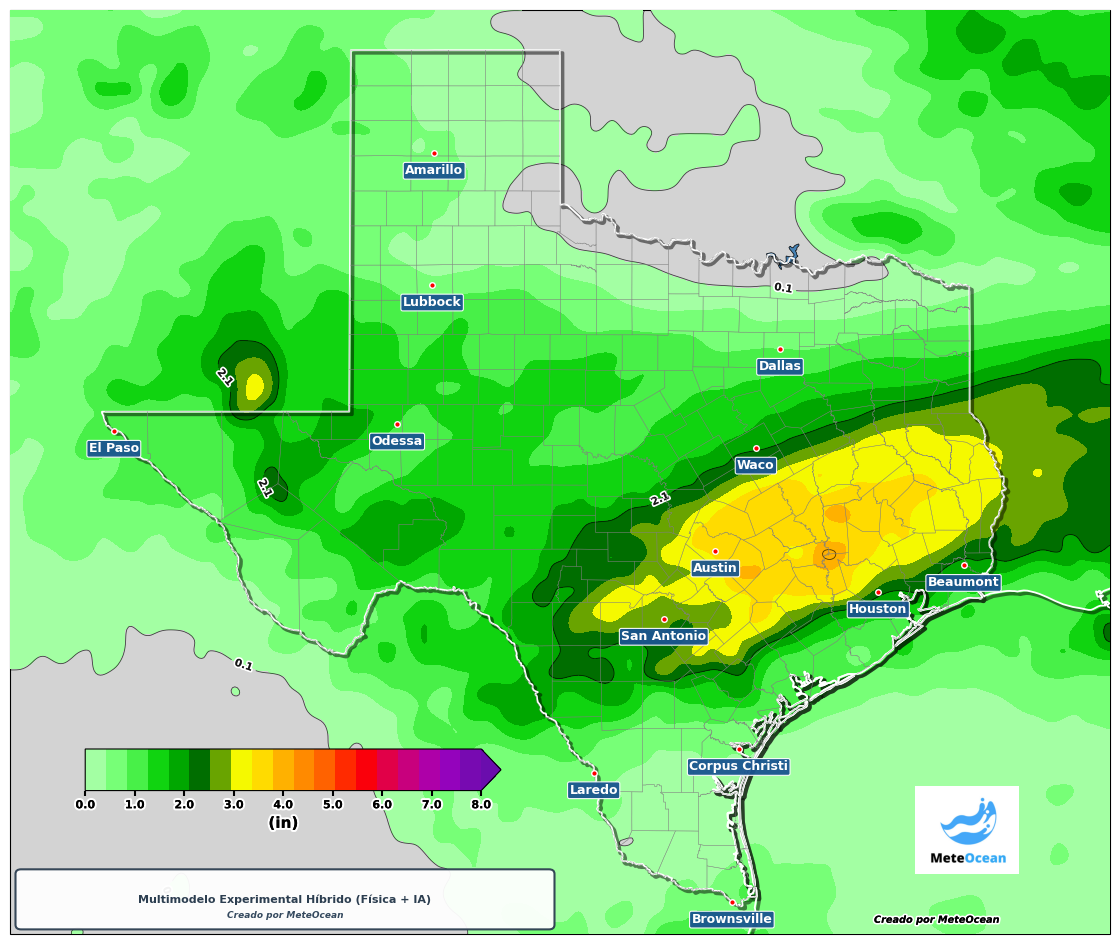

In [ ]:
#-----TEXAS - PRECIPITACIÓN MULTIMODELO----#
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import geopandas as gpd
import pandas as pd
from shapely.geometry import Point
from scipy.interpolate import griddata
from scipy.spatial import KDTree
import matplotlib.patheffects as PathEffects
import matplotlib.colors as mcolors
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.image as mpimg
from scipy.ndimage import gaussian_filter
import os
from matplotlib.patches import FancyBboxPatch

def graficar_precipitacion_texas(precip_dataarray, gdf_estados=None, condados_texas=None, mostrar_logo=True):
    """
    Grafica precipitación acumulada para Texas en PULGADAS.
    Ajusta dinámicamente el rango de colores según el valor máximo de precipitación.
    La precipitación se muestra tanto sobre tierra como sobre el mar.

    Parámetros:
    -----------
    precip_dataarray : xarray.DataArray
        DataArray con precipitación en mm con coordenadas 'longitude' y 'latitude'
    gdf_estados : GeoDataFrame
        GeoDataFrame con todos los estados
    condados_texas : GeoDataFrame
        GeoDataFrame con condados de Texas (opcional)
    mostrar_logo : bool
        Si se muestra el logo (default: True)
    """
    if gdf_estados is None:
        raise ValueError("Debe proporcionar 'gdf_estados'")

    # Filtrar Texas
    gdf_texas = gdf_estados[
        (gdf_estados['admin'] == 'United States of America') &
        (gdf_estados['name'] == 'Texas')
    ].copy()

    # --- PARÁMETROS DE ÁREA (TEXAS) ---
    lon_min_deg = -108
    lon_max_deg = -92
    lat_min = 25.5
    lat_max = 37

    # --- VERIFICAR COORDENADAS ---
    if 'longitude' not in precip_dataarray.coords or 'latitude' not in precip_dataarray.coords:
        raise ValueError("Input DataArray must have 'longitude' and 'latitude' coordinates.")

    # --- EXTRAER COORDENADAS ---
    lon_orig = precip_dataarray.longitude.values
    lat_orig = precip_dataarray.latitude.values

    print(f"Coordenadas originales:")
    print(f"  LON: [{lon_orig.min():.2f}, {lon_orig.max():.2f}] - {len(lon_orig)} puntos")
    print(f"  LAT: [{lat_orig.min():.2f}, {lat_orig.max():.2f}] - {len(lat_orig)} puntos")
    print(f"  Orden LAT: {'Descendente (N→S)' if lat_orig[0] > lat_orig[-1] else 'Ascendente (S→N)'}")

    precip_corrected = precip_dataarray

    # --- SELECCIONAR ÁREA (EXTENDER 1 GRADO) ---
    if lat_orig[0] > lat_orig[-1]:
        precip_area = precip_corrected.sel(
            latitude=slice(lat_max+1, lat_min-1),
            longitude=slice(lon_min_deg, lon_max_deg)
        )
    else:
        precip_area = precip_corrected.sel(
            latitude=slice(lat_min-1, lat_max+1),
            longitude=slice(lon_min_deg, lon_max_deg)
        )

    lat = precip_area.latitude.values
    lon = precip_area.longitude.values

    print(f"\nÁrea seleccionada:")
    print(f"  LON: [{lon.min():.2f}, {lon.max():.2f}] - {len(lon)} puntos")
    print(f"  LAT: [{lat.min():.2f}, {lat.max():.2f}] - {len(lat)} puntos")

    if len(lon) == 0 or len(lat) == 0:
        raise ValueError(f"El área seleccionada está vacía. Verifica los límites: LON[{lon_min_deg},{lon_max_deg}], LAT[{lat_min},{lat_max}]")

    precip_vals = precip_area.values[0, :, :] if precip_area.values.ndim == 3 else precip_area.values

    # --- CONVERTIR DE MILÍMETROS A PULGADAS ---
    precip_vals_inches = precip_vals / 25.4
    print(f"  Precipitación: Min={precip_vals_inches.min():.2f}, Max={precip_vals_inches.max():.2f}, Mean={precip_vals_inches.mean():.2f} in")

    # --- MALLA ORIGINAL ---
    lon2d, lat2d = np.meshgrid(lon, lat)

    # --- INTERPOLACIÓN A REJILLA MÁS FINA ---
    lon_fine = np.linspace(lon.min(), lon.max(), 500)
    lat_fine = np.linspace(lat.min(), lat.max(), 500)
    lon2d_fine, lat2d_fine = np.meshgrid(lon_fine, lat_fine)
    points_orig = np.column_stack((lon2d.ravel(), lat2d.ravel()))
    values_orig = precip_vals_inches.ravel()
    precip_fine = griddata(points_orig, values_orig, (lon2d_fine, lat2d_fine), method='cubic')

    # --- SUAVIZADO GAUSSIANO ---
    precip_fine_smooth = gaussian_filter(precip_fine, sigma=2)

    # --- MÁSCARA SOLO POR UMBRAL (sin restringir a tierra) ---
    umbral_precip = 0.1  # 0.1 pulgadas
    precip_masked_fine = np.where(precip_fine_smooth > umbral_precip, precip_fine_smooth, np.nan)

    # --- RANGO DE COLOR DINÁMICO EN PULGADAS ---
    precip_max = np.nanmax(precip_masked_fine)
    print(f"Precipitación máxima: {precip_max:.2f} in")

    if precip_max < 2:
        vmin_colorbar, vmax_colorbar = 0, 2
    elif 2 <= precip_max < 4:
        vmin_colorbar, vmax_colorbar = 0, 4
    else:
        vmin_colorbar, vmax_colorbar = 0, 8

    levels = np.linspace(vmin_colorbar, vmax_colorbar, 20)

    # --- CREAR FIGURA ---
    fig = plt.figure(figsize=(18, 12))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.set_extent([lon_min_deg, lon_max_deg, lat_min, lat_max], crs=ccrs.PlateCarree())

    # --- TERRITORIO ---
    ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=1)
    ax.add_feature(cfeature.OCEAN, facecolor='steelblue', zorder=1)

    # AGREGAR LAGOS
    lakes_feature = cfeature.NaturalEarthFeature('physical', 'lakes', '10m',
                                                   edgecolor='black', facecolor='steelblue')
    ax.add_feature(lakes_feature, linewidth=0.5, zorder=2)

    # --- COLORES DE PRECIPITACIÓN ---
    colors_precip = [
        '#b6ffb6', '#66ff66', '#00cc00', '#006400', '#ffff00', '#ffb300',
        '#ff6600', '#ff0000', '#d00070', '#a000c0', '#6a0dad'
    ]
    cmap_precip = mcolors.LinearSegmentedColormap.from_list('precipitacion', colors_precip)

    # --- CONTORNO DE PRECIPITACIÓN (SOBRE TIERRA Y MAR) ---
    cf = ax.contourf(
        lon2d_fine, lat2d_fine, precip_masked_fine,
        levels=levels, cmap=cmap_precip, extend='max',
        transform=ccrs.PlateCarree(), zorder=3
    )

    # --- ISOLÍNEAS ---
    contour_levels = np.unique(np.round(np.linspace(max(umbral_precip, vmin_colorbar), vmax_colorbar, 5), 1))
    cs = ax.contour(
        lon2d_fine, lat2d_fine, precip_fine_smooth,
        levels=contour_levels, colors='black', linewidths=0.6,
        alpha=0.7, transform=ccrs.PlateCarree(), zorder=4
    )
    labels = ax.clabel(cs, inline=True, fontsize=7.5, fmt='%.1f', inline_spacing=8)
    for label in labels:
        label.set_fontweight('bold')
        label.set_path_effects([
            PathEffects.withStroke(linewidth=2.5, foreground='white'),
            PathEffects.Normal()
        ])

    # --- COSTAS CON SOMBRA 3D ---
    coastline_feature = cfeature.NaturalEarthFeature('physical', 'coastline', '10m')
    coastline_geoms = list(coastline_feature.geometries())
    ax.add_geometries(coastline_geoms, crs=ccrs.PlateCarree(),
                      edgecolor='black', facecolor='none', linewidth=2.5, alpha=0.3,
                      path_effects=[PathEffects.SimpleLineShadow(offset=(2, -2), alpha=0.5)],
                      zorder=6)
    ax.add_geometries(coastline_geoms, crs=ccrs.PlateCarree(),
                      edgecolor='white', facecolor='none', linewidth=1.3,
                      path_effects=[PathEffects.Normal()], zorder=7)

    # --- FRONTERA DE TEXAS CON EFECTO 3D ---
    if len(gdf_texas) > 0:
        fronteras = gdf_texas.unary_union.boundary
        ax.add_geometries([fronteras], crs=ccrs.PlateCarree(),
                          edgecolor='black', facecolor='none', linewidth=2.5, alpha=0.3,
                          path_effects=[PathEffects.SimpleLineShadow(offset=(2, -2), alpha=0.5)],
                          zorder=6)
        ax.add_geometries([fronteras], crs=ccrs.PlateCarree(),
                          edgecolor='white', facecolor='none', linewidth=1.3,
                          path_effects=[PathEffects.Normal()], zorder=7)

    # --- CONDADOS DE TEXAS ---
    if condados_texas is not None:
        print(f"✅ Dibujando {len(condados_texas)} condados de Texas")
        condados_texas.boundary.plot(ax=ax, edgecolor='grey', linewidth=0.3, alpha=0.8,
                                       zorder=8, transform=ccrs.PlateCarree())
    else:
        print("⚠️ No se proporcionaron condados de Texas")

    # --- BARRA DE COLOR (HORIZONTAL) CON TICKS CADA 0.5 ---
    cax = inset_axes(ax, width="42%", height="5%", loc='lower left',
                     bbox_to_anchor=(-0.02, 0.05, 0.9, 0.9),
                     bbox_transform=ax.transAxes, borderpad=7)
    cbar = plt.colorbar(cf, cax=cax, orientation='horizontal')
    cbar.set_label("(in)", fontsize=11, weight='bold')
    label_obj = cbar.ax.xaxis.get_label()
    label_obj.set_path_effects([
        PathEffects.withStroke(linewidth=3, foreground='white'),
        PathEffects.Normal()
    ])
    # Configurar ticks cada 1 pulgada
    tick_values = np.arange(0, vmax_colorbar + 0.5, 1)
    cbar.set_ticks(tick_values)
    cbar.ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1f}'))
    cbar.ax.tick_params(labelsize=8, colors='black', width=1.5)
    for label in cbar.ax.get_xticklabels():
        label.set_fontweight('bold')
        label.set_path_effects([
            PathEffects.withStroke(linewidth=3, foreground='white'),
            PathEffects.Normal()
        ])

    # --- CIUDADES PRINCIPALES DE TEXAS ---
    ciudades_principales = {
        "Houston": {'lat': 29.76, 'lon': -95.37},
        "San Antonio": {'lat': 29.42, 'lon': -98.49},
        "Dallas": {'lat': 32.78, 'lon': -96.80},
        "Austin": {'lat': 30.27, 'lon': -97.74},
        "El Paso": {'lat': 31.76, 'lon': -106.49},
        "Corpus Christi": {'lat': 27.80, 'lon': -97.40},
        "Laredo": {'lat': 27.51, 'lon': -99.51},
        "Lubbock": {'lat': 33.58, 'lon': -101.86},
        "Amarillo": {'lat': 35.22, 'lon': -101.83},
        "Brownsville": {'lat': 25.90, 'lon': -97.50},
        "Odessa": {'lat': 31.85, 'lon': -102.37},
        "Beaumont": {'lat': 30.09, 'lon': -94.13},
        "Waco": {'lat': 31.55, 'lon': -97.15},
    }

    flat_points = np.column_stack((lat2d_fine.ravel(), lon2d_fine.ravel()))
    tree = KDTree(flat_points)
    precip_values = precip_fine_smooth.ravel()

    for nombre, datos in ciudades_principales.items():
        lat_ci, lon_ci = datos['lat'], datos['lon']
        _, idx = tree.query([lat_ci, lon_ci])
        precip = precip_values[idx]

        ax.plot(lon_ci, lat_ci, 'o',
                color='red', markersize=4,
                markeredgecolor='white', markeredgewidth=1,
                transform=ccrs.PlateCarree(), zorder=12)

        # BANNER AZUL AJUSTADO PARA EL NOMBRE DE LA CIUDAD
        ax.text(
            lon_ci, lat_ci - 0.14, nombre,
            fontsize=9, color='white', weight='bold',
            ha='center', va='top', zorder=15,
            transform=ccrs.PlateCarree(),
            bbox=dict(boxstyle="round,pad=0.15", facecolor='#1a5490',
                      edgecolor='white', linewidth=0.8, alpha=0.95)
        )

    # --- LOGO ---
    if mostrar_logo:
        try:
            logo_img = mpimg.imread("/content/drive/My Drive/Logo.png")
            axins_logo = inset_axes(ax, width="9.5%", height="9.5%", loc='lower right',
                                    bbox_to_anchor=(-0.07, 0.05, 1, 1),
                                    bbox_transform=ax.transAxes, borderpad=1)
            axins_logo.imshow(logo_img)
            axins_logo.axis('off')
        except:
            print("⚠️ Logo no encontrado en /content/drive/My Drive/Logo.png")

    # Crédito
    ax.text(0.90, 0.01, 'Creado por MeteOcean',
            transform=ax.transAxes, fontsize=7, ha='right', va='bottom',
            color='black', fontstyle='italic', fontweight='bold',
            path_effects=[
                PathEffects.withStroke(linewidth=2.5, foreground='white'),
                PathEffects.Normal()
            ])

    # --- BANNER ---
    banner_box = FancyBboxPatch(
        (0.01, 0.01), 0.48, 0.055,
        boxstyle="round,pad=0.005",
        transform=ax.transAxes,
        facecolor='white',
        edgecolor='#2C3E50',
        linewidth=1.5,
        alpha=0.95,
        zorder=20
    )
    ax.add_patch(banner_box)
    ax.text(0.25, 0.0375, 'Multimodelo Experimental Híbrido (Física + IA)',
            transform=ax.transAxes, fontsize=8, ha='center', va='center',
            color='#2C3E50', fontweight='bold', zorder=21)
    ax.text(0.25, 0.02, 'Creado por MeteOcean',
            transform=ax.transAxes, fontsize=6.5, ha='center', va='center',
            color='#34495E', fontstyle='italic', fontweight='semibold', zorder=21)

    # --- GUARDAR ---
    output_dir = "/content/drive/My Drive/Colab Notebooks/mapas/precipitacion"
    os.makedirs(output_dir, exist_ok=True)
    plt.savefig(f"{output_dir}/texas_mapa_precipitacion_multimodelo.png",
                dpi=800, bbox_inches='tight')
    print(f"✅ Mapa guardado: {output_dir}/texas_mapa_precipitacion_multimodelo.png")

    # --- MOSTRAR AUTOMÁTICAMENTE EN COLAB ---
    plt.show()

    return fig, ax

# --- CARGAR CONDADOS DE TEXAS ---
try:
    condados_texas = gpd.read_file("/content/drive/MyDrive/Colab Notebooks/cb_2018_us_county_500k/cb_2018_us_county_500k.shp")
    condados_texas = condados_texas[condados_texas['STATEFP'] == '48']  # FIPS code 48 = Texas
    print(f"✅ {len(condados_texas)} condados de Texas cargados")
except:
    print("⚠️ Condados no encontrados, se continuará sin ellos")
    condados_texas = None

# --- USO ---
print("🌧️ Generando mapa de PRECIPITACIÓN para Texas...")
fig, ax = graficar_precipitacion_texas(ds_multi, gdf_estados=gdf_estados, condados_texas=condados_texas)

📊 Generando mapa de precipitación para México...


/tmp/ipykernel_8442/230268607.py:187: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  mexico_geom = mexico.unary_union
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_1_states_provinces_lakes.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


Mapa guardado: /content/drive/My Drive/Colab Notebooks/mapas/precipitacion/mexico_mapa_precipitacion.png


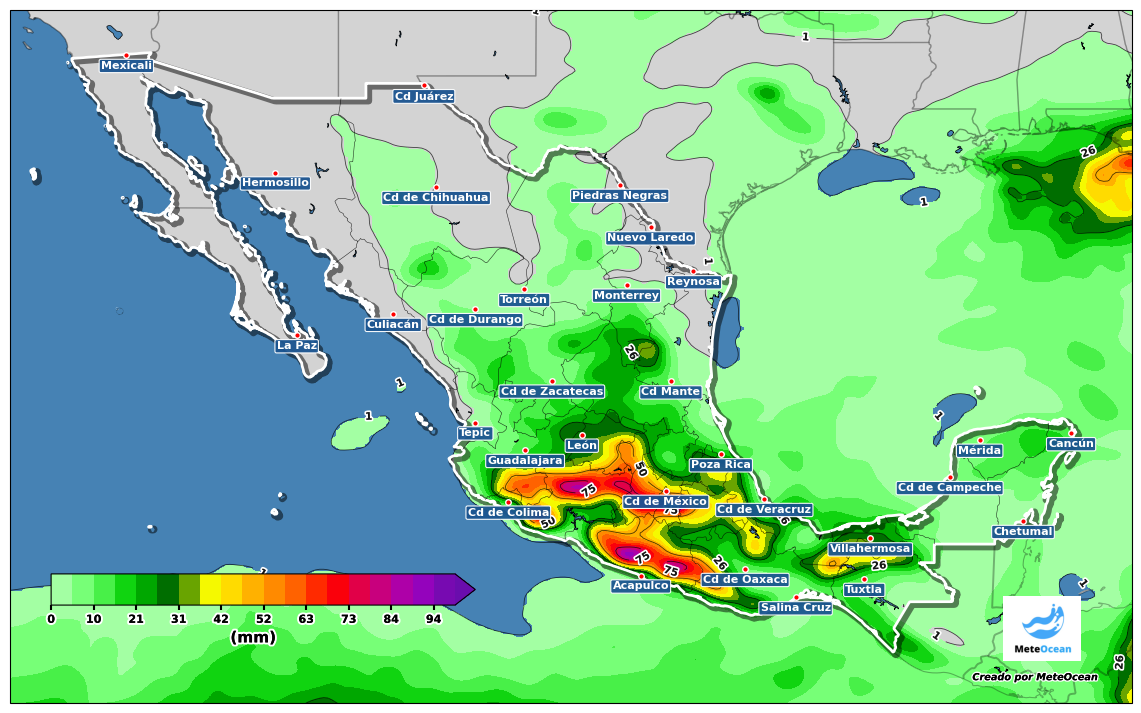

(<Figure size 1500x900 with 3 Axes>, <GeoAxes: >)

In [ ]:
#-----MÉXICO - PRECIPITACIÓN----#
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import geopandas as gpd
from shapely.geometry import Point
from scipy.interpolate import griddata
from scipy.spatial import KDTree
import matplotlib.patheffects as PathEffects
import matplotlib.colors as mcolors
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.image as mpimg
from shapely.ops import unary_union
from shapely.geometry import LineString, MultiLineString
from scipy.ndimage import gaussian_filter

def graficar_precipitacion_mexico(precip_dataarray, gdf_estados=None):
    """
    Grafica precipitación acumulada para México en PULGADAS.

    Parámetros:
    -----------
    precip_dataarray : xarray.DataArray
        DataArray con precipitación en mm con coordenadas 'longitude' y 'latitude'
    gdf_estados : GeoDataFrame
        GeoDataFrame con todos los estados
    """

    # --- VALIDACIÓN DE PARÁMETROS ---
    if gdf_estados is None:
        raise ValueError("Debe proporcionar 'gdf_estados'")

    # --- PARÁMETROS DE ÁREA ---
    lon_min_deg = -119
    lon_max_deg = -86
    lat_min = 14
    lat_max = 33

    # --- FILTRAR MÉXICO ---
    mexico = gdf_estados[gdf_estados['admin'] == 'Mexico'].copy()

    # --- VERIFICAR COORDENADAS ---
    if 'longitude' not in precip_dataarray.coords or 'latitude' not in precip_dataarray.coords:
        raise ValueError("Input DataArray must have 'longitude' and 'latitude' coordinates.")

    # --- EXTRAER Y CORREGIR COORDENADAS ---
    lon_orig = precip_dataarray.longitude.values
    lat_orig = precip_dataarray.latitude.values

    lon_corrected = np.where(lon_orig > 180, lon_orig - 360, lon_orig)
    precip_corrected = precip_dataarray.assign_coords(longitude=lon_corrected)

    # --- SELECCIONAR ÁREA ---
    # --- SELECCIONAR ÁREA (con margen adicional SOLO para los datos) ---
    margen_lon = 2  # grados extra a cada lado en longitud
    margen_lat = 2  # grados extra a cada lado en latitud

    if lat_orig[0] > lat_orig[-1]:
      precip_area = precip_corrected.sel(
      latitude=slice(lat_max + margen_lat, lat_min - margen_lat),
      longitude=slice(lon_min_deg - margen_lon, lon_max_deg + margen_lon)
    )
    else:
      precip_area = precip_corrected.sel(
      latitude=slice(lat_min - margen_lat, lat_max + margen_lat),
      longitude=slice(lon_min_deg - margen_lon, lon_max_deg + margen_lon)
    )


    lat = precip_area.latitude.values
    lon = precip_area.longitude.values

    if precip_area.values.ndim == 3:
        precip_vals = precip_area.values[0, :, :]
    else:
        precip_vals = precip_area.values

    # --- CONVERTIR DE MILÍMETROS A PULGADAS ---
    precip_vals_inches = precip_vals

    # --- MALLA ORIGINAL ---
    lon2d, lat2d = np.meshgrid(lon, lat)

    # --- INTERPOLACIÓN A REJILLA FINA ---
    lon_fine = np.linspace(lon.min(), lon.max(), 300)
    lat_fine = np.linspace(lat.min(), lat.max(), 300)
    lon2d_fine, lat2d_fine = np.meshgrid(lon_fine, lat_fine)

    points_orig = np.column_stack((lon2d.ravel(), lat2d.ravel()))
    values_orig = precip_vals_inches.ravel()
    precip_fine = griddata(points_orig, values_orig, (lon2d_fine, lat2d_fine), method='cubic')

    # --- SUAVIZADO GAUSSIANO ---
    precip_fine_smooth = gaussian_filter(precip_fine, sigma=2)

    # --- APLICAR MÁSCARA SOLO POR UMBRAL (sin restringir a tierra) ---
    umbral_precip = 1  # mm
    precip_masked_fine = np.where(precip_fine_smooth > umbral_precip, precip_fine_smooth, np.nan)

    # --- RANGO DE COLOR DINÁMICO ---
    precip_max = np.nanmax(precip_masked_fine)

    if precip_max < 50:
        vmin_colorbar, vmax_colorbar = 1, 50
    elif 50 <= precip_max < 100:
        vmin_colorbar, vmax_colorbar = 0, 100
    elif 100 <= precip_max < 150:
        vmin_colorbar, vmax_colorbar = 0, 200
    else:
        vmin_colorbar, vmax_colorbar = 1, 300

    levels = np.linspace(vmin_colorbar, vmax_colorbar, 20)

    # --- PLOTEO ---
    fig = plt.figure(figsize=(15, 9))
    ax = plt.axes(projection=ccrs.PlateCarree())

    buffer_lat = 1
    ax.set_extent([lon_min_deg, lon_max_deg + buffer_lat, lat_min - buffer_lat, lat_max + buffer_lat],
                  crs=ccrs.PlateCarree())

    ax.add_feature(cfeature.LAND, facecolor='lightgray')
    ax.add_feature(cfeature.OCEAN, facecolor='steelblue')

    lakes_feature = cfeature.NaturalEarthFeature('physical', 'lakes', '10m',
                                                   edgecolor='black', facecolor='steelblue')
    ax.add_feature(lakes_feature, linewidth=0.5, zorder=5)

    # --- COLORES DE PRECIPITACIÓN ---
    colors_precip = [
        '#b6ffb6', '#66ff66', '#00cc00', '#006400', '#ffff00', '#ffb300',
        '#ff6600', '#ff0000', '#d00070', '#a000c0', '#6a0dad'
    ]
    cmap_precip = mcolors.LinearSegmentedColormap.from_list('precipitacion', colors_precip)

    cf = ax.contourf(
        lon2d_fine, lat2d_fine, precip_masked_fine,
        levels=levels,
        cmap=cmap_precip,
        extend='max',
        transform=ccrs.PlateCarree()
    )


    # --- ISOLÍNEAS ---
    contour_levels = np.unique(np.round(np.linspace(max(umbral_precip, vmin_colorbar), vmax_colorbar, 5)).astype(int))
    cs = ax.contour(
        lon2d_fine, lat2d_fine, precip_fine_smooth,
        levels=contour_levels, colors='black', linewidths=0.6,
        alpha=0.7, transform=ccrs.PlateCarree(), zorder=4
    )

    labels = ax.clabel(cs, inline=True, fontsize=7.5, fmt='%d', inline_spacing=8)
    for label in labels:
        label.set_fontweight('bold')
        label.set_path_effects([
            PathEffects.withStroke(linewidth=2.5, foreground='white'),
            PathEffects.Normal()
        ])
 # --- BARRA DE COLOR (HORIZONTAL) ---
    cax = inset_axes(ax, width="42%", height="5%", loc='lower left',
                     bbox_to_anchor=(-0.05, 0.001, 0.9, 0.9),
                     bbox_transform=ax.transAxes, borderpad=7)
    cbar = plt.colorbar(cf, cax=cax, orientation='horizontal')
    cbar.set_label("(mm)", fontsize=11, weight='bold')

    label_obj = cbar.ax.xaxis.get_label()
    label_obj.set_path_effects([
        PathEffects.withStroke(linewidth=3, foreground='white'),
        PathEffects.Normal()
    ])

    cbar.ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x)}'))
    cbar.ax.tick_params(labelsize=8, colors='black', width=1.5)



    for label in cbar.ax.get_xticklabels():
        label.set_fontweight('bold')
        label.set_path_effects([
            PathEffects.withStroke(linewidth=3, foreground='white'),
            PathEffects.Normal()
        ])

    # Frontera principal de México
    mexico_geom = mexico.unary_union
    ax.add_geometries([mexico_geom], crs=ccrs.PlateCarree(),
                      facecolor='none', edgecolor='black', linewidth=5, alpha=0.8, zorder=5,
                      path_effects=[PathEffects.SimpleLineShadow(offset=(2, -2), alpha=0.5)])
    ax.add_geometries([mexico_geom], crs=ccrs.PlateCarree(),
                      facecolor='none', edgecolor='white', linewidth=2, zorder=8,
                      path_effects=[PathEffects.Normal()])

    # Líneas estatales interiores
    try:
        mexico_boundary = mexico_geom.boundary
        all_state_lines = []
        for geometry in mexico.geometry:
            if hasattr(geometry, 'boundary'):
                boundary = geometry.boundary
                if isinstance(boundary, LineString):
                    all_state_lines.append(boundary)
                elif isinstance(boundary, MultiLineString):
                    all_state_lines.extend(boundary.geoms)

        if all_state_lines:
            all_lines = unary_union(all_state_lines)
            interior_lines = all_lines.difference(mexico_boundary.buffer(0.01))
            if not interior_lines.is_empty:
                ax.add_geometries([interior_lines], crs=ccrs.PlateCarree(),
                                  facecolor='none', edgecolor='black', linewidth=0.4,
                                  alpha=0.8, zorder=9)
    except Exception as e:
        print(f"Error dibujando líneas interiores: {e}")

    # --- CIUDADES PRINCIPALES ---
    ciudades_principales = {
        'Mexicali': {'estado': 'Baja California', 'lat': 32.636, 'lon': -115.475},
        'La Paz': {'estado': 'Baja California Sur', 'lat': 24.142, 'lon': -110.313},
        'Hermosillo': {'estado': 'Sonora', 'lat': 29.075, 'lon': -110.958},
        'Culiacán': {'estado': 'Sinaloa', 'lat': 24.79, 'lon': -107.387},
        'Tepic': {'estado': 'Nayarit', 'lat': 21.5, 'lon': -104.9},
        'Guadalajara': {'estado': 'Jalisco', 'lat': 20.666, 'lon': -103.391},
        'Cd de Colima': {'estado': 'Colima', 'lat': 19.1, 'lon': -103.9},
        'Acapulco': {'estado': 'Guerrero', 'lat': 16.862, 'lon': -99.887},
        'Cd de Oaxaca': {'estado': 'Oaxaca', 'lat': 17.06, 'lon': -96.723},
        'Salina Cruz': {'estado': 'Oaxaca', 'lat': 16.2, 'lon': -95.195},
        'Tuxtla': {'estado': 'Chiapas', 'lat': 16.759, 'lon': -93.113},
        'Villahermosa': {'estado': 'Tabasco', 'lat': 17.986, 'lon': -92.93},
        'Cd de Campeche': {'estado': 'Campeche', 'lat': 19.843, 'lon': -90.525},
        'Mérida': {'estado': 'Yucatán', 'lat': 20.975, 'lon': -89.616},
        'Cancún': {'estado': 'Quintana Roo', 'lat': 21.174, 'lon': -86.846},
        'Chetumal': {'estado': 'Quintana Roo', 'lat': 18.514, 'lon': -88.303},
        'Cd de Veracruz': {'estado': 'Veracruz', 'lat': 19.1809, 'lon': -96.142},
        'Poza Rica': {'estado': 'Veracruz', 'lat': 20.533, 'lon': -97.459},
        'Cd de México': {'estado': 'Ciudad de México', 'lat': 19.428, 'lon': -99.127},
        'León': {'estado': 'Guanajuato', 'lat': 21.129, 'lon': -101.673},
        'Cd de Zacatecas': {'estado': 'Zacatecas', 'lat': 22.768, 'lon': -102.581},
        'Cd Mante': {'estado': 'Tamaulipas', 'lat': 22.743, 'lon': -98.973},
        'Reynosa': {'estado': 'Tamaulipas', 'lat': 26.08, 'lon': -98.288},
        'Nuevo Laredo': {'estado': 'Tamaulipas', 'lat': 27.410, 'lon': -99.59},
        'Monterrey': {'estado': 'Nuevo León', 'lat': 25.675, 'lon': -100.318},
        'Piedras Negras': {'estado': 'Coahuila', 'lat': 28.7, 'lon': -100.523},
        'Torreón': {'estado': 'Durango', 'lat': 25.543, 'lon': -103.418},
        'Cd de Durango': {'estado': 'Durango', 'lat': 24.934, 'lon': -104.911},
        'Cd Juárez': {'estado': 'Chihuahua', 'lat': 31.72, 'lon': -106.46},
        'Cd de Chihuahua': {'estado': 'Chihuahua', 'lat': 28.635, 'lon': -106.088}
    }

    # --- Árbol KD para encontrar precipitación más cercana ---
    flat_points = np.column_stack((lat2d_fine.ravel(), lon2d_fine.ravel()))
    tree = KDTree(flat_points)
    precip_values = precip_fine_smooth.ravel()

    # --- DIBUJAR CIUDADES CON ETIQUETAS AZULES ---
    for nombre, datos in ciudades_principales.items():
        lat_ci = datos['lat']
        lon_ci = datos['lon']

        _, idx = tree.query([lat_ci, lon_ci])
        precip = precip_values[idx]

        # Puntos
        ax.plot(lon_ci, lat_ci, 'o',
                color='red', markersize=4,
                markeredgecolor='white', markeredgewidth=1,
                transform=ccrs.PlateCarree(), zorder=12)

        # Nombre ciudad con banner azul
        ax.text(
            lon_ci, lat_ci - 0.18, nombre,
            fontsize=8, color='white', weight='bold',
            ha='center', va='top', zorder=15,
            transform=ccrs.PlateCarree(),
            bbox=dict(boxstyle="round,pad=0.15", facecolor='#1a5490',
                      edgecolor='white', linewidth=0.8, alpha=0.95)
        )

    # Capas adicionales
    ax.add_feature(cfeature.NaturalEarthFeature('physical', 'coastline', '10m',
                                                edgecolor='black', facecolor='none'),
                   linewidth=0.8, alpha=0.3, zorder=6)
    ax.add_feature(cfeature.BORDERS, linestyle='-', linewidth=1.4, edgecolor='black', alpha=0.3, zorder=5)
    ax.add_feature(cfeature.STATES, linewidth=1, edgecolor='black', alpha=0.2, zorder=5)

    # --- LOGO ---
    try:
        logo_img = mpimg.imread("/content/drive/My Drive/Logo.png")
        axins_logo = inset_axes(ax, width="9.5%", height="9.5%", loc='lower left',
                                bbox_to_anchor=(0.86, 0.04, 1, 1),
                                bbox_transform=ax.transAxes, borderpad=1)
        axins_logo.imshow(logo_img)
        axins_logo.axis('off')
    except:
        print("Logo no encontrado")

    ax.text(0.97, 0.03, 'Creado por MeteOcean',
            transform=ax.transAxes, fontsize=7, ha='right', va='bottom',
            color='black', fontstyle='italic', fontweight='bold', zorder=35,
            path_effects=[
                PathEffects.withStroke(linewidth=2, foreground='white'),
                PathEffects.Normal()
            ])

    # --- GUARDAR ---
    nombre_archivo = f"/content/drive/My Drive/Colab Notebooks/mapas/precipitacion/mexico_mapa_precipitacion.png"
    plt.savefig(nombre_archivo, dpi=800, bbox_inches='tight')
    print(f"Mapa guardado: {nombre_archivo}")
    plt.show()

    return fig, ax


# --- EJECUCIÓN ---
# Asegúrate de tener cargado gdf_estados y tu DataArray de precipitación
# ds_precip debe ser un xarray.DataArray con precipitación en mm
print("📊 Generando mapa de precipitación para México...")
graficar_precipitacion_mexico(ds_multi, gdf_estados=gdf_estados)

Coordenadas originales:
 LON: [-180.00, 179.75] - 1440 puntos
 LAT: [-90.00, 90.00] - 721 puntos
 Orden LAT: Ascendente (S→N)

Área seleccionada:
 LON: [-125.00, -58.00] - 269 puntos
 LAT: [-0.50, 51.00] - 207 puntos
 Precipitación: Min=0.00, Max=310.69, Mean=13.02 mm


/tmp/ipython-input-799/2061160348.py:185: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  fronteras = gdf_pais.unary_union.boundary
/tmp/ipython-input-799/2061160348.py:185: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  fronteras = gdf_pais.unary_union.boundary
/tmp/ipython-input-799/2061160348.py:185: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  fronteras = gdf_pais.unary_union.boundary
/tmp/ipython-input-799/2061160348.py:185: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  fronteras = gdf_pais.unary_union.boundary
/tmp/ipython-input-799/2061160348.py:185: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  fronteras = gdf_pais.unary_union.boundary
/tmp/ipython-input-799/2061160348.py:185: DeprecationWarning: The

✅ Mapa guardado: /content/drive/My Drive/Colab Notebooks/mapas/precipitacion/regional_mapa_precipitacion_multimodelo.png


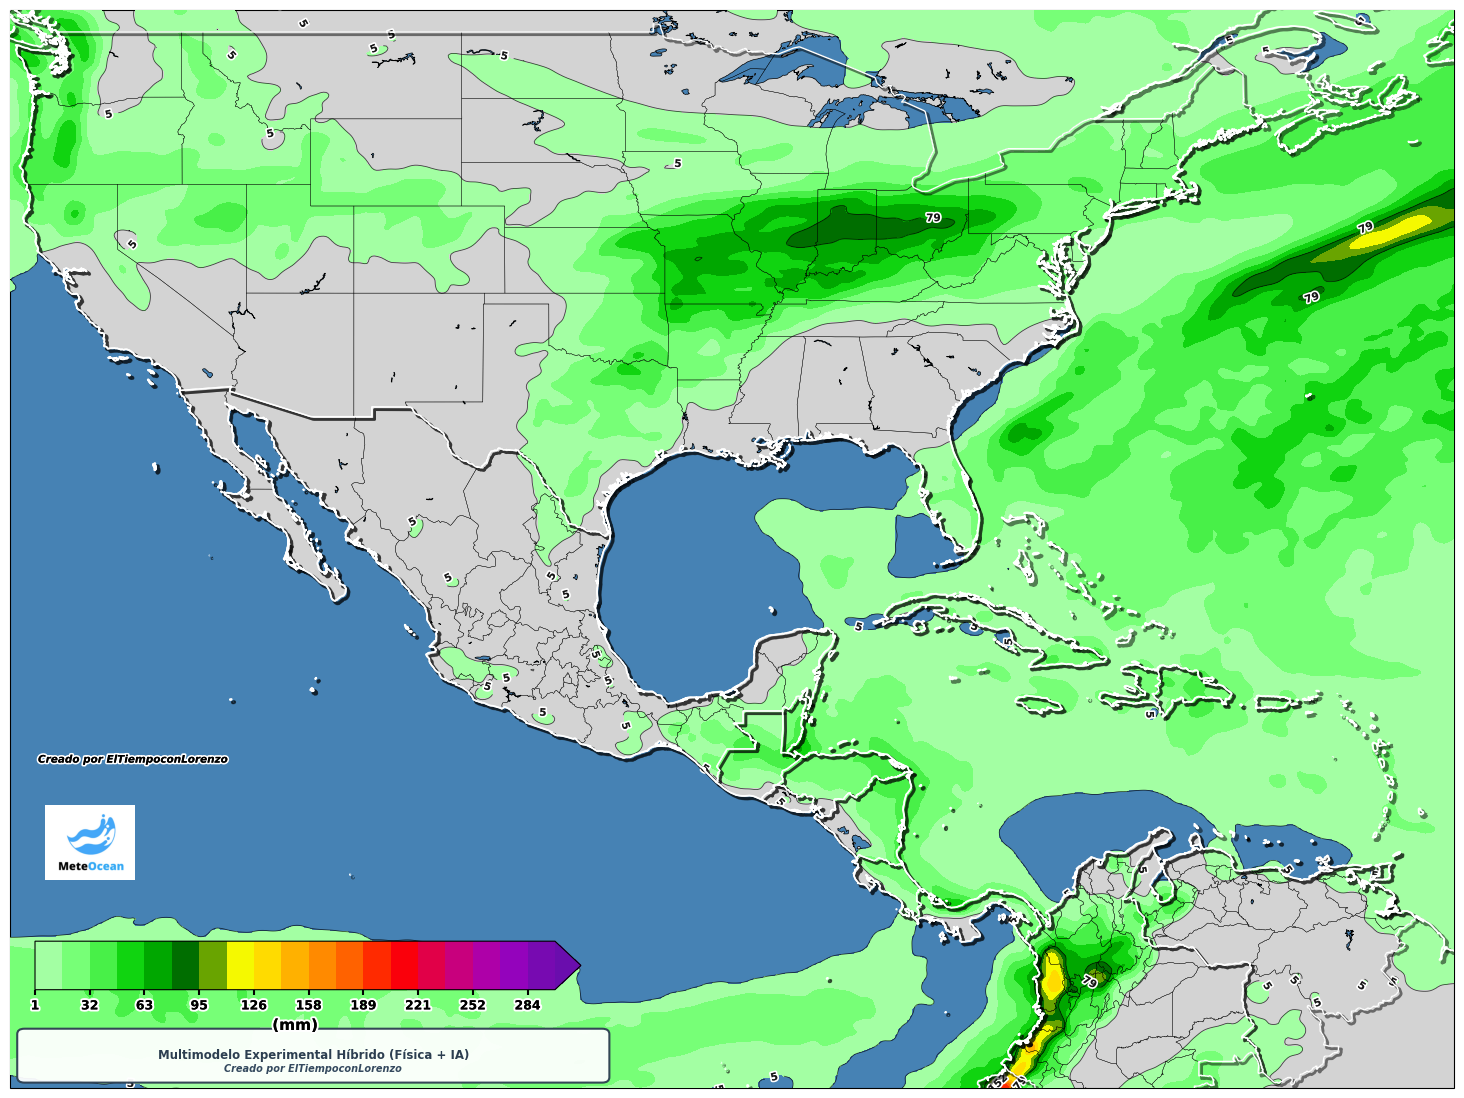

In [ ]:
#-----NORTEAMÉRICA Y CARIBE - PRECIPITACIÓN MULTIMODELO----#
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import geopandas as gpd
import pandas as pd
from shapely.geometry import Point
from scipy.interpolate import griddata
from scipy.spatial import KDTree
import matplotlib.patheffects as PathEffects
import matplotlib.colors as mcolors
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.image as mpimg
from scipy.ndimage import gaussian_filter
import os
from matplotlib.patches import FancyBboxPatch

def graficar_precipitacion_regional(precip_dataarray, gdf_estados=None, mostrar_logo=True):
    """
    Grafica precipitación acumulada para la región completa: Estados Unidos, México,
    Centroamérica, Caribe, Colombia y Venezuela.
    Ajusta dinámicamente el rango de colores según el valor máximo de precipitación.
    La precipitación se muestra tanto sobre tierra como sobre el mar.

    Parámetros:
    -----------
    precip_dataarray : xarray.DataArray
        DataArray con precipitación en mm con coordenadas 'longitude' y 'latitude'
    gdf_estados : GeoDataFrame
        GeoDataFrame con todos los estados
    mostrar_logo : bool
        Si se muestra el logo (default: True)
    """

    if gdf_estados is None:
        raise ValueError("Debe proporcionar 'gdf_estados'")

    # Filtrar todos los países de la región
    paises = [
        'United States of America', 'Mexico', 'Guatemala', 'Belize', 'Honduras',
        'El Salvador', 'Nicaragua', 'Costa Rica', 'Panama', 'Colombia', 'Venezuela',
        'Cuba', 'Haiti', 'Dominican Republic', 'Jamaica', 'Puerto Rico',
        'Trinidad and Tobago', 'Bahamas'
    ]
    gdf_regional = gdf_estados[gdf_estados['admin'].isin(paises)].copy()

    # --- PARÁMETROS DE ÁREA (REGIÓN COMPLETA) ---
    lon_min_deg = -125
    lon_max_deg = -58
    lat_min = 0.5
    lat_max = 50

    # --- VERIFICAR COORDENADAS ---
    if 'longitude' not in precip_dataarray.coords or 'latitude' not in precip_dataarray.coords:
        raise ValueError("Input DataArray must have 'longitude' and 'latitude' coordinates.")

    # --- EXTRAER COORDENADAS ---
    lon_orig = precip_dataarray.longitude.values
    lat_orig = precip_dataarray.latitude.values

    print(f"Coordenadas originales:")
    print(f" LON: [{lon_orig.min():.2f}, {lon_orig.max():.2f}] - {len(lon_orig)} puntos")
    print(f" LAT: [{lat_orig.min():.2f}, {lat_orig.max():.2f}] - {len(lat_orig)} puntos")
    print(f" Orden LAT: {'Descendente (N→S)' if lat_orig[0] > lat_orig[-1] else 'Ascendente (S→N)'}")

    precip_corrected = precip_dataarray

    # --- SELECCIONAR ÁREA ---
    if lat_orig[0] > lat_orig[-1]:
        precip_area = precip_corrected.sel(
            latitude=slice(lat_max+1, lat_min-1),
            longitude=slice(lon_min_deg, lon_max_deg)
        )
    else:
        precip_area = precip_corrected.sel(
            latitude=slice(lat_min-1, lat_max+1),
            longitude=slice(lon_min_deg, lon_max_deg)
        )

    lat = precip_area.latitude.values
    lon = precip_area.longitude.values

    print(f"\nÁrea seleccionada:")
    print(f" LON: [{lon.min():.2f}, {lon.max():.2f}] - {len(lon)} puntos")
    print(f" LAT: [{lat.min():.2f}, {lat.max():.2f}] - {len(lat)} puntos")

    if len(lon) == 0 or len(lat) == 0:
        raise ValueError(f"El área seleccionada está vacía. Verifica los límites: LON[{lon_min_deg},{lon_max_deg}], LAT[{lat_min},{lat_max}]")

    precip_vals = precip_area.values[0, :, :] if precip_area.values.ndim == 3 else precip_area.values
    print(f" Precipitación: Min={precip_vals.min():.2f}, Max={precip_vals.max():.2f}, Mean={precip_vals.mean():.2f} mm")

    # --- MALLA ORIGINAL ---
    lon2d, lat2d = np.meshgrid(lon, lat)

    # --- INTERPOLACIÓN A REJILLA MÁS FINA ---
    lon_fine = np.linspace(lon.min(), lon.max(), 600)
    lat_fine = np.linspace(lat.min(), lat.max(), 600)
    lon2d_fine, lat2d_fine = np.meshgrid(lon_fine, lat_fine)

    points_orig = np.column_stack((lon2d.ravel(), lat2d.ravel()))
    values_orig = precip_vals.ravel()
    precip_fine = griddata(points_orig, values_orig, (lon2d_fine, lat2d_fine), method='cubic')

    # --- SUAVIZADO GAUSSIANO ---
    precip_fine_smooth = gaussian_filter(precip_fine, sigma=2)

    # --- MÁSCARA SOLO POR UMBRAL (sin restringir a tierra) ---
    umbral_precip = 5
    precip_masked_fine = np.where(precip_fine_smooth > umbral_precip, precip_fine_smooth, np.nan)

    # --- RANGO DE COLOR DINÁMICO ---
    precip_max = np.nanmax(precip_masked_fine)

    if precip_max < 50:
        vmin_colorbar, vmax_colorbar = 1, 50
    elif 50 <= precip_max < 100:
        vmin_colorbar, vmax_colorbar = 0, 100
    elif 100 <= precip_max < 150:
        vmin_colorbar, vmax_colorbar = 0, 200
    else:
        vmin_colorbar, vmax_colorbar = 1, 300

    levels = np.linspace(vmin_colorbar, vmax_colorbar, 20)

    # --- CREAR FIGURA ---
    fig = plt.figure(figsize=(22, 14))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.set_extent([lon_min_deg, lon_max_deg, lat_min, lat_max], crs=ccrs.PlateCarree())

    # --- TERRITORIO ---
    ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=1)
    ax.add_feature(cfeature.OCEAN, facecolor='steelblue', zorder=1)

    lakes_feature = cfeature.NaturalEarthFeature('physical', 'lakes', '10m',
                                                   edgecolor='black', facecolor='steelblue')
    ax.add_feature(lakes_feature, linewidth=0.5, zorder=2)

    # --- COLORES DE PRECIPITACIÓN ---
    colors_precip = [
        '#b6ffb6', '#66ff66', '#00cc00', '#006400', '#ffff00', '#ffb300',
        '#ff6600', '#ff0000', '#d00070', '#a000c0', '#6a0dad'
    ]
    cmap_precip = mcolors.LinearSegmentedColormap.from_list('precipitacion', colors_precip)

    # --- CONTORNO DE PRECIPITACIÓN (SOBRE TIERRA Y MAR) ---
    cf = ax.contourf(
        lon2d_fine, lat2d_fine, precip_masked_fine,
        levels=levels, cmap=cmap_precip, extend='max',
        transform=ccrs.PlateCarree(), zorder=3
    )

    # --- ISOLÍNEAS ---
    contour_levels = np.unique(np.round(np.linspace(max(umbral_precip, vmin_colorbar), vmax_colorbar, 5)).astype(int))
    cs = ax.contour(
        lon2d_fine, lat2d_fine, precip_fine_smooth,
        levels=contour_levels, colors='black', linewidths=0.6,
        alpha=0.7, transform=ccrs.PlateCarree(), zorder=4
    )

    labels = ax.clabel(cs, inline=True, fontsize=7.5, fmt='%d', inline_spacing=8)
    for label in labels:
        label.set_fontweight('bold')
        label.set_path_effects([
            PathEffects.withStroke(linewidth=2.5, foreground='white'),
            PathEffects.Normal()
        ])

    # --- COSTAS CON SOMBRA 3D ---
    coastline_feature = cfeature.NaturalEarthFeature('physical', 'coastline', '10m')
    coastline_geoms = list(coastline_feature.geometries())
    ax.add_geometries(coastline_geoms, crs=ccrs.PlateCarree(),
                      edgecolor='black', facecolor='none', linewidth=2.5, alpha=0.3,
                      path_effects=[PathEffects.SimpleLineShadow(offset=(2, -2), alpha=0.5)],
                      zorder=6)
    ax.add_geometries(coastline_geoms, crs=ccrs.PlateCarree(),
                      edgecolor='white', facecolor='none', linewidth=1.3,
                      path_effects=[PathEffects.Normal()], zorder=7)

    # --- FRONTERAS PAÍSES CON EFECTO 3D ---
    for pais in paises:
        gdf_pais = gdf_regional[gdf_regional['admin'] == pais]
        if len(gdf_pais) > 0:
            fronteras = gdf_pais.unary_union.boundary
            ax.add_geometries([fronteras], crs=ccrs.PlateCarree(),
                              edgecolor='black', facecolor='none', linewidth=2.0, alpha=0.3,
                              path_effects=[PathEffects.SimpleLineShadow(offset=(2, -2), alpha=0.5)],
                              zorder=6)
            ax.add_geometries([fronteras], crs=ccrs.PlateCarree(),
                              edgecolor='white', facecolor='none', linewidth=1.0,
                              path_effects=[PathEffects.Normal()], zorder=7)

    # --- ESTADOS/PROVINCIAS INTERNAS (solo para países principales) ---
    paises_con_estados = ['United States of America', 'Mexico', 'Colombia', 'Venezuela']
    for pais in paises_con_estados:
        estados = gdf_regional[(gdf_regional['admin'] == pais) & (gdf_regional['type'] != 'Country')]
        if len(estados) > 0:
            estados.boundary.plot(ax=ax, edgecolor='black', linewidth=0.25,
                                      zorder=4, transform=ccrs.PlateCarree())

    ## --- BARRA DE COLOR (HORIZONTAL) ---
    cax = inset_axes(ax, width="42%", height="5%", loc='lower left',
                     bbox_to_anchor=(-0.05, 0.001, 0.9, 0.9),
                     bbox_transform=ax.transAxes, borderpad=7)
    cbar = plt.colorbar(cf, cax=cax, orientation='horizontal')
    cbar.set_label("(mm)", fontsize=11, weight='bold')

    label_obj = cbar.ax.xaxis.get_label()
    label_obj.set_path_effects([
        PathEffects.withStroke(linewidth=3, foreground='white'),
        PathEffects.Normal()
    ])

    cbar.ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x)}'))
    cbar.ax.tick_params(labelsize=9, colors='black', width=1.5)

    for label in cbar.ax.get_xticklabels():
        label.set_fontweight('bold')
        label.set_path_effects([
            PathEffects.withStroke(linewidth=3, foreground='white'),
            PathEffects.Normal()
        ])

    # --- CIUDADES PRINCIPALES DE LA REGIÓN ---
    ciudades_principales = {
        # Estados Unidos (selección)
        #"New York": {'lat': 40.71, 'lon': -74.01},

    }

    flat_points = np.column_stack((lat2d_fine.ravel(), lon2d_fine.ravel()))
    tree = KDTree(flat_points)
    precip_values = precip_fine_smooth.ravel()

    for nombre, datos in ciudades_principales.items():
        lat_ci, lon_ci = datos['lat'], datos['lon']
        _, idx = tree.query([lat_ci, lon_ci])
        precip = precip_values[idx]

        ax.plot(lon_ci, lat_ci, 'o',
                color='red', markersize=3.5,
                markeredgecolor='white', markeredgewidth=1,
                transform=ccrs.PlateCarree(), zorder=12)

        ax.text(
            lon_ci, lat_ci - 0.25, nombre,
            fontsize=6.5, color='white', weight='bold',
            ha='center', va='top', zorder=15,
            transform=ccrs.PlateCarree(),
            bbox=dict(boxstyle="round,pad=0.15", facecolor='#1a5490',
                      edgecolor='white', linewidth=0.8, alpha=0.95)
        )

    # --- LOGO ---
    if mostrar_logo:
        try:
            logo_img = mpimg.imread("/content/drive/My Drive/Logo.png")
            axins_logo = inset_axes(ax, width="7%", height="7%", loc='lower right',
                                    bbox_to_anchor=(-0.9, 0.18, 1, 1),
                                    bbox_transform=ax.transAxes, borderpad=1)
            axins_logo.imshow(logo_img)
            axins_logo.axis('off')
        except:
            print("⚠️ Logo no encontrado en /content/drive/My Drive/Logo.png")

    # Crédito
    ax.text(0.15, 0.3, 'Creado por MeteOcean',
            transform=ax.transAxes, fontsize=7.5, ha='right', va='bottom',
            color='black', fontstyle='italic', fontweight='bold',
            path_effects=[
                PathEffects.withStroke(linewidth=2.5, foreground='white'),
                PathEffects.Normal()
            ])

    # --- BANNER ---
    banner_box = FancyBboxPatch(
        (0.01, 0.01), 0.4, 0.04,
        boxstyle="round,pad=0.005",
        transform=ax.transAxes,
        facecolor='white',
        edgecolor='#2C3E50',
        linewidth=1.5,
        alpha=0.95,
        zorder=20
    )
    ax.add_patch(banner_box)

    ax.text(0.21, 0.03, 'Multimodelo Experimental Híbrido (Física + IA)',
            transform=ax.transAxes, fontsize=8.5, ha='center', va='center',
            color='#2C3E50', fontweight='bold', zorder=21)

    ax.text(0.21, 0.018, 'Creado por ElTiempoconLorenzo',
            transform=ax.transAxes, fontsize=7, ha='center', va='center',
            color='#34495E', fontstyle='italic', fontweight='semibold', zorder=21)

    # --- GUARDAR ---
    output_dir = "/content/drive/My Drive/Colab Notebooks/mapas/precipitacion"
    os.makedirs(output_dir, exist_ok=True)
    plt.savefig(f"{output_dir}/regional_mapa_precipitacion_multimodelo.png",
                dpi=800, bbox_inches='tight')
    print(f"✅ Mapa guardado: {output_dir}/regional_mapa_precipitacion_multimodelo.png")

    # --- MOSTRAR AUTOMÁTICAMENTE EN COLAB ---
    plt.show()

    return fig, ax


# --- USO ---
# Asegúrate de tener cargado gdf_estados y ds_multimodelo de tu clase MultiModeloMeteorologico
fig, ax = graficar_precipitacion_regional(ds_multi, gdf_estados=gdf_estados)

📊 Generando mapa de precipitación para la Península Ibérica...


/tmp/ipykernel_4407/22795107.py:188: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  espana_geom = espana.unary_union
/tmp/ipykernel_4407/22795107.py:197: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  portugal_geom = portugal.unary_union


Mapa guardado: /content/drive/My Drive/Colab Notebooks/mapas/precipitacion/iberia_mapa_precipitacion.png


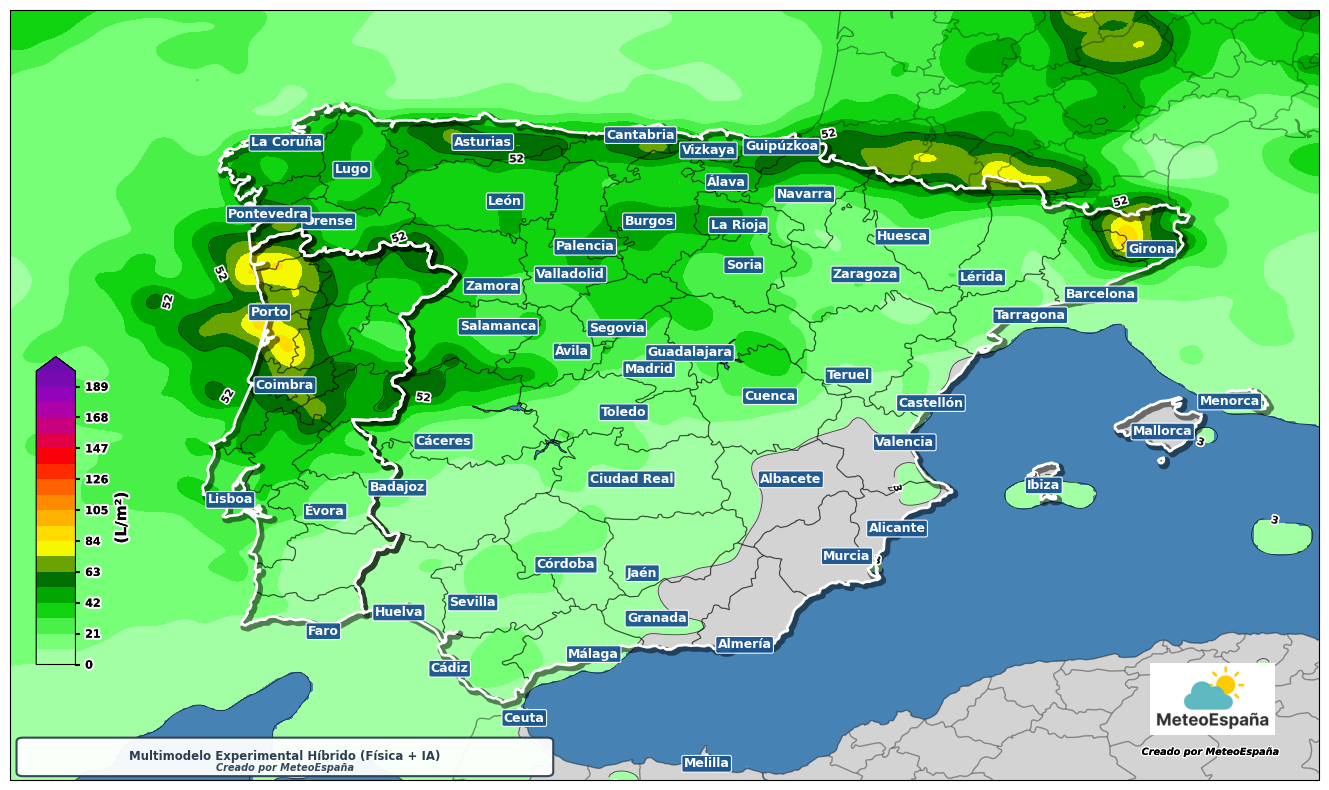

(<Figure size 1800x1000 with 3 Axes>, <GeoAxes: >)

In [ ]:
#-----PENÍNSULA IBÉRICA - PRECIPITACIÓN----#
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import geopandas as gpd
from shapely.geometry import Point
from scipy.interpolate import griddata
from scipy.spatial import KDTree
import matplotlib.patheffects as PathEffects
import matplotlib.colors as mcolors
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.image as mpimg
from shapely.ops import unary_union
from shapely.geometry import LineString, MultiLineString
from scipy.ndimage import gaussian_filter
from matplotlib.patches import FancyBboxPatch

def graficar_precipitacion_iberia(precip_dataarray, gdf_estados=None):
    """
    Grafica precipitación acumulada para la Península Ibérica (España y Portugal) en mm.

    Parámetros:
    -----------
    precip_dataarray : xarray.DataArray
        DataArray con precipitación en mm con coordenadas 'longitude' y 'latitude'
    gdf_estados : GeoDataFrame
        GeoDataFrame con comunidades autónomas de España y regiones de Portugal
    """

    # --- VALIDACIÓN DE PARÁMETROS ---
    if gdf_estados is None:
        raise ValueError("Debe proporcionar 'gdf_estados'")

    # --- PARÁMETROS DE ÁREA (PENÍNSULA IBÉRICA) ---
    lon_min_deg = -12
    lon_max_deg = 5
    lat_min = 35
    lat_max = 45

    # --- FILTRAR ESPAÑA Y PORTUGAL POR SEPARADO ---
    espana = gdf_estados[gdf_estados['admin'] == 'Spain'].copy()
    portugal = gdf_estados[gdf_estados['admin'] == 'Portugal'].copy()
    iberia = pd.concat([espana, portugal])

    # --- VERIFICAR COORDENADAS ---
    if 'longitude' not in precip_dataarray.coords or 'latitude' not in precip_dataarray.coords:
        raise ValueError("Input DataArray must have 'longitude' and 'latitude' coordinates.")

    # --- EXTRAER Y CORREGIR COORDENADAS ---
    lon_orig = precip_dataarray.longitude.values
    lat_orig = precip_dataarray.latitude.values

    lon_corrected = np.where(lon_orig > 180, lon_orig - 360, lon_orig)
    precip_corrected = precip_dataarray.assign_coords(longitude=lon_corrected)

    # --- SELECCIONAR ÁREA (con margen adicional SOLO para los datos) ---
    margen_lon = 2
    margen_lat = 2

    if lat_orig[0] > lat_orig[-1]:
        precip_area = precip_corrected.sel(
            latitude=slice(lat_max + margen_lat, lat_min - margen_lat),
            longitude=slice(lon_min_deg - margen_lon, lon_max_deg + margen_lon)
        )
    else:
        precip_area = precip_corrected.sel(
            latitude=slice(lat_min - margen_lat, lat_max + margen_lat),
            longitude=slice(lon_min_deg - margen_lon, lon_max_deg + margen_lon)
        )

    lat = precip_area.latitude.values
    lon = precip_area.longitude.values

    if precip_area.values.ndim == 3:
        precip_vals = precip_area.values[0, :, :]
    else:
        precip_vals = precip_area.values

    # --- VALORES EN MM ---
    precip_vals_mm = precip_vals

    # --- MALLA ORIGINAL ---
    lon2d, lat2d = np.meshgrid(lon, lat)

    # --- INTERPOLACIÓN A REJILLA FINA ---
    lon_fine = np.linspace(lon.min(), lon.max(), 400)
    lat_fine = np.linspace(lat.min(), lat.max(), 400)
    lon2d_fine, lat2d_fine = np.meshgrid(lon_fine, lat_fine)

    points_orig = np.column_stack((lon2d.ravel(), lat2d.ravel()))
    values_orig = precip_vals_mm.ravel()
    precip_fine = griddata(points_orig, values_orig, (lon2d_fine, lat2d_fine), method='cubic')

    # --- SUAVIZADO GAUSSIANO ---
    precip_fine_smooth = gaussian_filter(precip_fine, sigma=2)

    # --- APLICAR MÁSCARA SOLO POR UMBRAL ---
    umbral_precip = 3  # mm
    precip_masked_fine = np.where(precip_fine_smooth > umbral_precip, precip_fine_smooth, np.nan)

    # --- RANGO DE COLOR DINÁMICO ---
    precip_max = np.nanmax(precip_masked_fine)

    if precip_max < 50:
        vmin_colorbar, vmax_colorbar = 1, 50
    elif 50 <= precip_max < 100:
        vmin_colorbar, vmax_colorbar = 0, 100
    elif 100 <= precip_max < 150:
        vmin_colorbar, vmax_colorbar = 0, 200
    else:
        vmin_colorbar, vmax_colorbar = 1, 300

    levels = np.linspace(vmin_colorbar, vmax_colorbar, 20)

    # --- PLOTEO ---

    fig = plt.figure(figsize=(18, 10))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.set_extent([lon_min_deg, lon_max_deg, lat_min, lat_max], crs=ccrs.PlateCarree())

    ax.add_feature(cfeature.LAND, facecolor='lightgray')
    ax.add_feature(cfeature.OCEAN, facecolor='steelblue')

    lakes_feature = cfeature.NaturalEarthFeature('physical', 'lakes', '10m',
                                                   edgecolor='black', facecolor='steelblue')
    ax.add_feature(lakes_feature, linewidth=0.5, zorder=5)

    # --- COLORES DE PRECIPITACIÓN ---
    colors_precip = [
        '#b6ffb6', '#66ff66', '#00cc00', '#006400', '#ffff00', '#ffb300',
        '#ff6600', '#ff0000', '#d00070', '#a000c0', '#6a0dad'
    ]
    cmap_precip = mcolors.LinearSegmentedColormap.from_list('precipitacion', colors_precip)

    cf = ax.contourf(
        lon2d_fine, lat2d_fine, precip_masked_fine,
        levels=levels,
        cmap=cmap_precip,
        extend='max',
        transform=ccrs.PlateCarree()
    )

    # --- ISOLÍNEAS ---
    contour_levels = np.unique(np.round(np.linspace(max(umbral_precip, vmin_colorbar), vmax_colorbar, 5)).astype(int))
    cs = ax.contour(
        lon2d_fine, lat2d_fine, precip_fine_smooth,
        levels=contour_levels, colors='black', linewidths=0.6,
        alpha=0.7, transform=ccrs.PlateCarree(), zorder=4
    )

    labels = ax.clabel(cs, inline=True, fontsize=7.5, fmt='%d', inline_spacing=8)
    for label in labels:
        label.set_fontweight('bold')
        label.set_path_effects([
            PathEffects.withStroke(linewidth=2.5, foreground='white'),
            PathEffects.Normal()
        ])

    # --- BARRA DE COLOR (VERTICAL) ---
    cax = inset_axes(ax, width="3%", height="40%", loc='lower left',
                 bbox_to_anchor=(0.02, 0.15, 1, 1),
                 bbox_transform=ax.transAxes, borderpad=0)

    cbar = plt.colorbar(cf, cax=cax, orientation='vertical')
    cbar.set_label("(L/m²)", fontsize=11, weight='bold')

    label_obj = cbar.ax.yaxis.get_label()
    label_obj.set_path_effects([
    PathEffects.withStroke(linewidth=3, foreground='white'),
    PathEffects.Normal()
        ])

    cbar.ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x)}'))
    cbar.ax.tick_params(labelsize=8, colors='black', width=1.5)

    for label in cbar.ax.get_yticklabels():
      label.set_fontweight('bold')
      label.set_path_effects([
      PathEffects.withStroke(linewidth=3, foreground='white'),
      PathEffects.Normal()
      ])


    # --- FRONTERAS: ESPAÑA Y PORTUGAL POR SEPARADO ---
    # España
    espana_geom = espana.unary_union
    ax.add_geometries([espana_geom], crs=ccrs.PlateCarree(),
                      facecolor='none', edgecolor='black', linewidth=5, alpha=0.8, zorder=5,
                      path_effects=[PathEffects.SimpleLineShadow(offset=(2, -2), alpha=0.5)])
    ax.add_geometries([espana_geom], crs=ccrs.PlateCarree(),
                      facecolor='none', edgecolor='white', linewidth=2, zorder=8,
                      path_effects=[PathEffects.Normal()])

    # Portugal
    portugal_geom = portugal.unary_union
    ax.add_geometries([portugal_geom], crs=ccrs.PlateCarree(),
                      facecolor='none', edgecolor='black', linewidth=5, alpha=0.8, zorder=5,
                      path_effects=[PathEffects.SimpleLineShadow(offset=(2, -2), alpha=0.5)])
    ax.add_geometries([portugal_geom], crs=ccrs.PlateCarree(),
                      facecolor='none', edgecolor='white', linewidth=2, zorder=8,
                      path_effects=[PathEffects.Normal()])

    # --- LÍNEAS INTERIORES: COMUNIDADES AUTÓNOMAS (ESPAÑA) Y REGIONES (PORTUGAL) ---
    try:
        # Líneas de comunidades autónomas de España
        espana_boundary = espana_geom.boundary
        all_comunidades_lines = []
        for geometry in espana.geometry:
            if hasattr(geometry, 'boundary'):
                boundary = geometry.boundary
                if isinstance(boundary, LineString):
                    all_comunidades_lines.append(boundary)
                elif isinstance(boundary, MultiLineString):
                    all_comunidades_lines.extend(boundary.geoms)

        if all_comunidades_lines:
            all_lines_esp = unary_union(all_comunidades_lines)
            interior_lines_esp = all_lines_esp.difference(espana_boundary.buffer(0.01))
            if not interior_lines_esp.is_empty:
                ax.add_geometries([interior_lines_esp], crs=ccrs.PlateCarree(),
                                  facecolor='none', edgecolor='black', linewidth=0.4,
                                  alpha=0.8, zorder=9)

        # Líneas de regiones de Portugal
        portugal_boundary = portugal_geom.boundary
        all_portugal_lines = []
        for geometry in portugal.geometry:
            if hasattr(geometry, 'boundary'):
                boundary = geometry.boundary
                if isinstance(boundary, LineString):
                    all_portugal_lines.append(boundary)
                elif isinstance(boundary, MultiLineString):
                    all_portugal_lines.extend(boundary.geoms)

        if all_portugal_lines:
            all_lines_pt = unary_union(all_portugal_lines)
            interior_lines_pt = all_lines_pt.difference(portugal_boundary.buffer(0.01))
            if not interior_lines_pt.is_empty:
                ax.add_geometries([interior_lines_pt], crs=ccrs.PlateCarree(),
                                  facecolor='none', edgecolor='black', linewidth=0.4,
                                  alpha=0.8, zorder=9)

    except Exception as e:
        print(f"Error dibujando líneas interiores: {e}")

    # --- CAPITALES DE COMUNIDADES AUTÓNOMAS ---
    capitales_autonomas = {
        # ESPAÑA
        'Ceuta': {'lat': 35.8894, 'lon': -5.3213},
        'Melilla': {'lat': 35.2943, 'lon': -2.9526},
        'Álava': {'lat': 42.85, 'lon': -2.69},  # País Vasco
        'Albacete': {'lat': 38.99, 'lon': -1.86},  # Castilla-La Mancha
        'Alicante': {'lat': 38.35, 'lon': -0.48},  # Comunidad Valenciana
        'Almería': {'lat': 36.84, 'lon': -2.46},  # Andalucía
        'Asturias': {'lat': 43.37, 'lon': -5.86},  # Asturias
        'Ávila': {'lat': 40.65, 'lon': -4.70},  # Castilla y León
        'Badajoz': {'lat': 38.88, 'lon': -6.97},  # Extremadura
        'Barcelona': {'lat': 41.39, 'lon': 2.17},  # Cataluña
        'Burgos': {'lat': 42.34, 'lon': -3.70},  # Castilla y León
        'Cáceres': {'lat': 39.48, 'lon': -6.37},  # Extremadura
        'Cádiz': {'lat': 36.53, 'lon': -6.29},  # Andalucía
        'Cantabria': {'lat': 43.46, 'lon': -3.81},  # Cantabria
        'Castellón': {'lat': 39.98, 'lon': -0.04},  # Comunidad Valenciana
        'Ciudad Real': {'lat': 38.99, 'lon': -3.93},  # Castilla-La Mancha
        'Córdoba': {'lat': 37.88, 'lon': -4.78},  # Andalucía
        'Cuenca': {'lat': 40.07, 'lon': -2.13},  # Castilla-La Mancha
        'Girona': {'lat': 41.98, 'lon': 2.82},  # Cataluña
        'Granada': {'lat': 37.18, 'lon': -3.60},  # Andalucía
        'Guadalajara': {'lat': 40.63, 'lon': -3.17},  # Castilla-La Mancha
        'Guipúzkoa': {'lat': 43.31, 'lon': -1.98},  # País Vasco
        'Huelva': {'lat': 37.26, 'lon': -6.95},  # Andalucía
        'Huesca': {'lat': 42.14, 'lon': -0.41},  # Aragón
        'Ibiza': {'lat': 38.9105, 'lon': 1.4247},  # Illes Balears
        'Mallorca': {'lat': 39.61, 'lon': 2.97},  # Illes Balears
        'Menorca': {'lat': 40.0002, 'lon': 3.84},  # Illes Balears
        'Jaén': {'lat': 37.77, 'lon': -3.79},  # Andalucía
        'La Coruña': {'lat': 43.36, 'lon': -8.41},  # Galicia
        'La Rioja': {'lat': 42.29, 'lon': -2.54},  # La Rioja
        'León': {'lat': 42.60, 'lon': -5.57},  # Castilla y León
        'Lérida': {'lat': 41.61, 'lon': 0.62},  # Cataluña
        'Lugo': {'lat': 43.01, 'lon': -7.56},  # Galicia
        'Madrid': {'lat': 40.42, 'lon': -3.70},  # Comunidad de Madrid
        'Málaga': {'lat': 36.72, 'lon': -4.42},  # Andalucía
        'Murcia': {'lat': 37.99, 'lon': -1.13},  # Región de Murcia
        'Navarra': {'lat': 42.69, 'lon': -1.68},  # Navarra
        'Orense': {'lat': 42.34, 'lon': -7.86},  # Galicia
        'Palencia': {'lat': 42.01, 'lon': -4.53},  # Castilla y León
        'Pontevedra': {'lat': 42.43, 'lon': -8.64},  # Galicia
        'Salamanca': {'lat': 40.97, 'lon': -5.66},  # Castilla y León
        'Segovia': {'lat': 40.95, 'lon': -4.12},  # Castilla y León
        'Sevilla': {'lat': 37.39, 'lon': -5.99},  # Andalucía
        'Soria': {'lat': 41.77, 'lon': -2.47},  # Castilla y León
        'Tarragona': {'lat': 41.12, 'lon': 1.25},  # Cataluña
        'Teruel': {'lat': 40.34, 'lon': -1.11},  # Aragón
        'Toledo': {'lat': 39.86, 'lon': -4.03},  # Castilla-La Mancha
        'Valencia': {'lat': 39.47, 'lon': -0.38},  # Comunidad Valenciana
        'Valladolid': {'lat': 41.65, 'lon': -4.72},  # Castilla y León
        'Vizkaya': {'lat': 43.26, 'lon': -2.93},  # País Vasco
        'Zamora': {'lat': 41.50, 'lon': -5.74},  # Castilla y León
        'Zaragoza': {'lat': 41.65, 'lon': -0.89},  # Aragón



        # PORTUGAL
        'Lisboa': {'lat': 38.722, 'lon': -9.139},  # Lisboa
        'Porto': {'lat': 41.158, 'lon': -8.629},  # Norte
        'Coimbra': {'lat': 40.211, 'lon': -8.429},  # Centro
        'Évora': {'lat': 38.571, 'lon': -7.907},  # Alentejo
        'Faro': {'lat': 37.017, 'lon': -7.930},  # Algarve
    }

    # --- Árbol KD para encontrar precipitación más cercana ---
    flat_points = np.column_stack((lat2d_fine.ravel(), lon2d_fine.ravel()))
    tree = KDTree(flat_points)
    precip_values = precip_fine_smooth.ravel()

    # --- DIBUJAR CAPITALES CON ETIQUETAS AZULES ---
    for nombre, datos in capitales_autonomas.items():
        lat_ci = datos['lat']
        lon_ci = datos['lon']

        # Verificar si está dentro del área visible
        if not (lon_min_deg <= lon_ci <= lon_max_deg and lat_min <= lat_ci <= lat_max):
            continue

        _, idx = tree.query([lat_ci, lon_ci])
        precip = precip_values[idx]

        # Puntos
        #ax.plot(lon_ci, lat_ci, 'o',
                #color='red', markersize=4,
                #markeredgecolor='white', markeredgewidth=1,
                #transform=ccrs.PlateCarree(), zorder=12)

        # Nombre ciudad con banner azul
        ax.text(
            lon_ci, lat_ci, nombre,
            fontsize=9, color='white', weight='bold',
            ha='center', va='top', zorder=15,
            transform=ccrs.PlateCarree(),
            bbox=dict(boxstyle="round,pad=0.15", facecolor='#1a5490',
                      edgecolor='white', linewidth=0.8, alpha=0.95)
        )

    # --- CAPAS ADICIONALES ---
    ax.add_feature(cfeature.NaturalEarthFeature('physical', 'coastline', '10m',
                                                edgecolor='black', facecolor='none'),
                   linewidth=0.8, alpha=0.3, zorder=6)
    ax.add_feature(cfeature.BORDERS, linestyle='-', linewidth=1.4, edgecolor='black', alpha=0.3, zorder=5)
    ax.add_feature(cfeature.STATES, linewidth=1, edgecolor='black', alpha=0.2, zorder=5)

    # --- LOGO (OPCIONAL) ---
    try:
        logo_img = mpimg.imread("/content/drive/My Drive/Logo_Spain.png")
        axins_logo = inset_axes(ax, width="9.5%", height="9.5%", loc='lower left',
                                bbox_to_anchor=(0.86, 0.04, 1, 1),
                                bbox_transform=ax.transAxes, borderpad=1)
        axins_logo.imshow(logo_img)
        axins_logo.axis('off')
    except:
        print("Logo no encontrado (opcional)")

    ax.text(0.97, 0.03, 'Creado por MeteoEspaña',
            transform=ax.transAxes, fontsize=7, ha='right', va='bottom',
            color='black', fontstyle='italic', fontweight='bold', zorder=35,
            path_effects=[
                PathEffects.withStroke(linewidth=2, foreground='white'),
                PathEffects.Normal()
            ])

    # --- BANNER ---
    banner_box = FancyBboxPatch(
        (0.01, 0.01), 0.4, 0.04,
        boxstyle="round,pad=0.005",
        transform=ax.transAxes,
        facecolor='white',
        edgecolor='#2C3E50',
        linewidth=1.5,
        alpha=0.95,
        zorder=20
    )
    ax.add_patch(banner_box)
    ax.text(0.21, 0.03, 'Multimodelo Experimental Híbrido (Física + IA)',
            transform=ax.transAxes, fontsize=8.5, ha='center', va='center',
            color='#2C3E50', fontweight='bold', zorder=21)

    ax.text(0.21, 0.015, 'Creado por MeteoEspaña',
            transform=ax.transAxes, fontsize=7, ha='center', va='center',
            color='#34495E', fontstyle='italic', fontweight='semibold', zorder=21)

    # --- GUARDAR ---
    nombre_archivo = f"/content/drive/My Drive/Colab Notebooks/mapas/precipitacion/iberia_mapa_precipitacion.png"
    plt.savefig(nombre_archivo, dpi=800, bbox_inches='tight')
    print(f"Mapa guardado: {nombre_archivo}")
    plt.show()

    return fig, ax


# --- EJECUCIÓN ---
# Asegúrate de tener cargado gdf_estados y tu DataArray de precipitación
# ds_precip debe ser un xarray.DataArray con precipitación en mm
print("📊 Generando mapa de precipitación para la Península Ibérica...")
graficar_precipitacion_iberia(ds_multi, gdf_estados=gdf_estados)

Coordenadas originales:
  LON: [-180.00, 179.75] - 1440 puntos
  LAT: [-90.00, 90.00] - 721 puntos
  Orden LAT: Ascendente (S→N)

Área seleccionada:
  LON: [-19.50, -12.00] - 31 puntos
  LAT: [26.50, 30.50] - 17 puntos
  Precipitación: Min=0.05, Max=24.86, Mean=1.48 mm
23.52769643735508


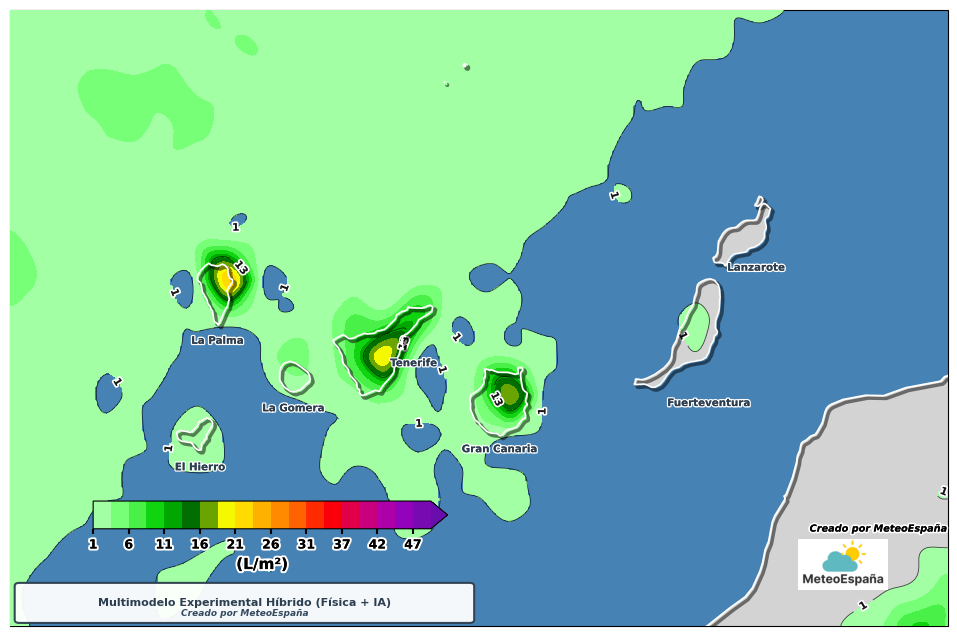

In [ ]:
#-----ISLAS CANARIAS - PRECIPITACIÓN MULTIMODELO - REJILLA COMÚN ----#
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import geopandas as gpd
from shapely.geometry import Point
from scipy.interpolate import griddata
from scipy.spatial import KDTree
import matplotlib.patheffects as PathEffects
import matplotlib.colors as mcolors
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.image as mpimg
from scipy.ndimage import gaussian_filter
import os
import xarray as xr
from matplotlib.patches import FancyBboxPatch
from IPython.display import display

def graficar_precipitacion_dataarray(precip_dataarray, canarias=None, gdf_estados=None, mostrar_logo=True):
    """
    Grafica precipitación acumulada para Islas Canarias y muestra automáticamente la figura en Colab.
    Ajusta dinámicamente el rango de colores según el valor máximo de precipitación.
    """
    # --- PARÁMETROS DE ÁREA ---
    lon_min_deg, lon_max_deg = -19.5, -12
    lat_min, lat_max = 26.5, 30.5

    # --- VERIFICAR COORDENADAS ---
    if 'longitude' not in precip_dataarray.coords or 'latitude' not in precip_dataarray.coords:
        raise ValueError("Input DataArray must have 'longitude' and 'latitude' coordinates.")

    # --- EXTRAER COORDENADAS ---
    lon_orig = precip_dataarray.longitude.values
    lat_orig = precip_dataarray.latitude.values

    print(f"Coordenadas originales:")
    print(f"  LON: [{lon_orig.min():.2f}, {lon_orig.max():.2f}] - {len(lon_orig)} puntos")
    print(f"  LAT: [{lat_orig.min():.2f}, {lat_orig.max():.2f}] - {len(lat_orig)} puntos")
    print(f"  Orden LAT: {'Descendente (N→S)' if lat_orig[0] > lat_orig[-1] else 'Ascendente (S→N)'}")

    precip_corrected = precip_dataarray

    # --- SELECCIONAR ÁREA ---
    if lat_orig[0] > lat_orig[-1]:
        precip_area = precip_corrected.sel(latitude=slice(lat_max, lat_min),
                                           longitude=slice(lon_min_deg, lon_max_deg))
    else:
        precip_area = precip_corrected.sel(latitude=slice(lat_min, lat_max),
                                           longitude=slice(lon_min_deg, lon_max_deg))

    lat = precip_area.latitude.values
    lon = precip_area.longitude.values

    print(f"\nÁrea seleccionada:")
    print(f"  LON: [{lon.min():.2f}, {lon.max():.2f}] - {len(lon)} puntos")
    print(f"  LAT: [{lat.min():.2f}, {lat.max():.2f}] - {len(lat)} puntos")

    if len(lon) == 0 or len(lat) == 0:
        raise ValueError(f"El área seleccionada está vacía. Verifica los límites: LON[{lon_min_deg},{lon_max_deg}], LAT[{lat_min},{lat_max}]")

    precip_vals = precip_area.values[0, :, :] if precip_area.values.ndim == 3 else precip_area.values
    print(f"  Precipitación: Min={precip_vals.min():.2f}, Max={precip_vals.max():.2f}, Mean={precip_vals.mean():.2f} mm")

    # --- MALLA ORIGINAL ---
    lon2d, lat2d = np.meshgrid(lon, lat)

    # --- INTERPOLACIÓN A REJILLA MÁS FINA ---
    lon_fine = np.linspace(lon.min(), lon.max(), 400)
    lat_fine = np.linspace(lat.min(), lat.max(), 400)
    lon2d_fine, lat2d_fine = np.meshgrid(lon_fine, lat_fine)
    points_orig = np.column_stack((lon2d.ravel(), lat2d.ravel()))
    values_orig = precip_vals.ravel()
    precip_fine = griddata(points_orig, values_orig, (lon2d_fine, lat2d_fine), method='cubic')

    # --- SUAVIZADO GAUSSIANO ---
    precip_fine_smooth = gaussian_filter(precip_fine, sigma=2)

    # --- MÁSCARA ---
    umbral_precip = 1
    precip_masked_fine = np.where(precip_fine_smooth > umbral_precip, precip_fine_smooth, np.nan)

    # --- RANGO DE COLOR DINÁMICO ---
    precip_max = np.nanmax(precip_fine_smooth)
    print(precip_max)
    if precip_max < 50:
        vmin_colorbar, vmax_colorbar = 1, 50
    elif 50 <= precip_max < 100:
        vmin_colorbar, vmax_colorbar = 0, 100
    else:
        vmin_colorbar, vmax_colorbar = 0, 150

    levels = np.linspace(vmin_colorbar, vmax_colorbar, 20)

    # --- CREAR FIGURA ---
    fig = plt.figure(figsize=(16, 8))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.set_extent([lon_min_deg, lon_max_deg, lat_min, lat_max], crs=ccrs.PlateCarree())

    # --- TERRITORIO ---
    ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=1)
    ax.add_feature(cfeature.OCEAN, facecolor='steelblue', zorder=1)
    lakes_feature = cfeature.NaturalEarthFeature('physical', 'lakes', '10m', edgecolor='black', facecolor='steelblue')
    ax.add_feature(lakes_feature, linewidth=0.5, zorder=2)

    if canarias is None and gdf_estados is not None:
        canarias = gdf_estados[gdf_estados['admin'] == 'Spain'].copy()
    elif canarias is None:
        raise ValueError("Debe proporcionar 'canarias' o 'gdf_estados'")

    canarias.boundary.plot(ax=ax, edgecolor='black', linewidth=0.7, zorder=5)

    # --- COLORES ---
    colors_precip = [
        '#b6ffb6', '#66ff66', '#00cc00', '#006400', '#ffff00', '#ffb300',
        '#ff6600', '#ff0000', '#d00070', '#a000c0', '#6a0dad'
    ]
    cmap_precip = mcolors.LinearSegmentedColormap.from_list('precipitacion', colors_precip)

    # --- CONTORNO DE PRECIPITACIÓN ---
    cf = ax.contourf(
        lon2d_fine, lat2d_fine, precip_masked_fine,
        levels=levels, cmap=cmap_precip, extend='max',
        transform=ccrs.PlateCarree(), zorder=3
    )

    # --- ISOLÍNEAS ---
    contour_levels = np.unique(np.round(np.linspace(max(umbral_precip, vmin_colorbar), vmax_colorbar, 5)).astype(int))
    cs = ax.contour(
        lon2d_fine, lat2d_fine, precip_fine_smooth,
        levels=contour_levels, colors='black', linewidths=0.6,
        alpha=0.7, transform=ccrs.PlateCarree(), zorder=4
    )
    labels = ax.clabel(cs, inline=True, fontsize=7.5, fmt='%d', inline_spacing=8)
    for label in labels:
        label.set_fontweight('bold')
        label.set_path_effects([
            PathEffects.withStroke(linewidth=2.5, foreground='white'),
            PathEffects.Normal()
        ])

    # --- COSTA CON SOMBRA ---
    coastline_feature = cfeature.NaturalEarthFeature('physical', 'coastline', '10m')
    coastline_geoms = list(coastline_feature.geometries())
    ax.add_geometries(coastline_geoms, crs=ccrs.PlateCarree(),
                      edgecolor='black', facecolor='none', linewidth=2.5, alpha=0.3,
                      path_effects=[PathEffects.SimpleLineShadow(offset=(2, -2), alpha=0.5)],
                      zorder=6)
    ax.add_geometries(coastline_geoms, crs=ccrs.PlateCarree(),
                      edgecolor='white', facecolor='none', linewidth=1.3,
                      path_effects=[PathEffects.Normal()], zorder=7)

    # --- BARRA DE COLOR ---
    cax = inset_axes(ax, width="42%", height="5%", loc='lower left',
                     bbox_to_anchor=(-0.015, 0.0, 0.9, 0.9),
                     bbox_transform=ax.transAxes, borderpad=7)
    cbar = plt.colorbar(cf, cax=cax, orientation='horizontal')
    cbar.set_label("(L/m²)", fontsize=11, weight='bold')
    label_obj = cbar.ax.xaxis.get_label()
    label_obj.set_path_effects([
        PathEffects.withStroke(linewidth=3, foreground='white'),
        PathEffects.Normal()
    ])
    cbar.ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x)}'))
    cbar.ax.tick_params(labelsize=9, colors='black', width=1.5)
    for label in cbar.ax.get_xticklabels():
        label.set_fontweight('bold')
        label.set_path_effects([
            PathEffects.withStroke(linewidth=3, foreground='white'),
            PathEffects.Normal()
        ])

    # --- CIUDADES ---
    ciudades_principales = {
        # Tenerife
        "Tenerife": {'lat': 28.3191, 'lon': -16.27},

        # Gran Canaria
        "Gran Canaria": {'lat': 27.7605, 'lon': -15.5838},

        # Lanzarote
        "Lanzarote": {'lat': 28.9394, 'lon': -13.5316},

        # Fuerteventura
        "Fuerteventura": {'lat': 28.06, 'lon': -13.9113},

        # La Palma
        "La Palma": {'lat': 28.4647, 'lon': -17.8391},

        # La Gomera
        "La Gomera": {'lat': 28.0263, 'lon': -17.2322},

        # El Hierro
        "El Hierro": {'lat': 27.6433, 'lon': -17.9783},
    }

    flat_points = np.column_stack((lat2d_fine.ravel(), lon2d_fine.ravel()))
    tree = KDTree(flat_points)
    precip_values = precip_fine_smooth.ravel()

    for nombre, datos in ciudades_principales.items():
        lat_ci, lon_ci = datos['lat'], datos['lon']
        _, idx = tree.query([lat_ci, lon_ci])
        precip = precip_values[idx]

        #ax.plot(lon_ci, lat_ci, 'o',
                #color='red', markersize=4,
                #markeredgecolor='white', markeredgewidth=1,
                #transform=ccrs.PlateCarree(), zorder=12)

        ax.text(
            lon_ci, lat_ci - 0.08, nombre,
            fontsize=7.4, color='#2C3E50', weight='bold',
            ha='center', va='top', zorder=15,
            transform=ccrs.PlateCarree(),
            path_effects=[
                PathEffects.withStroke(linewidth=2, foreground='white'),
                PathEffects.SimpleLineShadow(offset=(1, -1), alpha=0.3),
                PathEffects.Normal()
            ]
        )

    # --- LOGO ---
    if mostrar_logo:
        try:
            logo_img = mpimg.imread("/content/drive/My Drive/Logo_Spain.png")
            axins_logo = inset_axes(ax, width="9.5%", height="9.5%", loc='lower right',
                                    bbox_to_anchor=(-0.05, 0.03, 1, 1),
                                    bbox_transform=ax.transAxes, borderpad=1)
            axins_logo.imshow(logo_img)
            axins_logo.axis('off')
        except:
            print("Logo no encontrado")

    # Crédito
    ax.text(1.0, 0.15, 'Creado por MeteoEspaña',
            transform=ax.transAxes, fontsize=7, ha='right', va='bottom',
            color='black', fontstyle='italic', fontweight='bold',
            path_effects=[
                PathEffects.withStroke(linewidth=2.5, foreground='white'),
                PathEffects.Normal()
            ])

    # --- BANNER ---
    banner_box = FancyBboxPatch(
        (0.01, 0.01), 0.48, 0.055,
        boxstyle="round,pad=0.005",
        transform=ax.transAxes,
        facecolor='white',
        edgecolor='#2C3E50',
        linewidth=1.5,
        alpha=0.95,
        zorder=20
    )
    ax.add_patch(banner_box)
    ax.text(0.25, 0.0375, 'Multimodelo Experimental Híbrido (Física + IA)',
            transform=ax.transAxes, fontsize=8, ha='center', va='center',
            color='#2C3E50', fontweight='bold', zorder=21)
    ax.text(0.25, 0.02, 'Creado por MeteoEspaña',
            transform=ax.transAxes, fontsize=6.5, ha='center', va='center',
            color='#34495E', fontstyle='italic', fontweight='semibold', zorder=21)

    # --- GUARDAR ---
    output_dir = "/content/drive/My Drive/Colab Notebooks/mapas/precipitacion"
    os.makedirs(output_dir, exist_ok=True)
    plt.savefig(f"{output_dir}/canarias_mapa_precipitacion_multimodelo.png", dpi=800, bbox_inches='tight')

    # --- MOSTRAR AUTOMÁTICAMENTE EN COLAB ---
    plt.show()

    return fig, ax

# --- USO ---
canarias = gdf_estados[gdf_estados['admin'] == 'Spain'].copy()
fig, ax = graficar_precipitacion_dataarray(ds_multi, canarias=canarias)

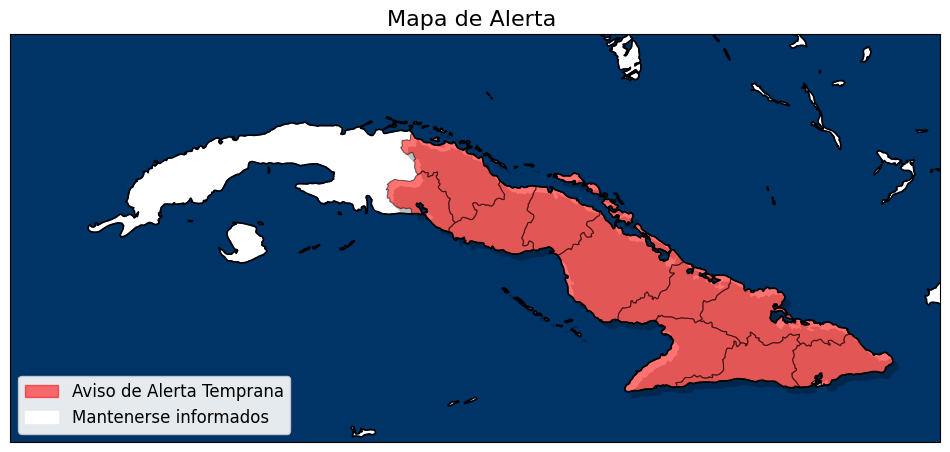

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from shapely.affinity import translate
import matplotlib.patches as mpatches
import os

# --- CARGAR SHAPEFILES ---
ruta_estados = "/content/drive/MyDrive/Colab Notebooks/ne_10m_admin_1_states_provinces/ne_10m_admin_1_states_provinces.shp"
gdf_estados = gpd.read_file(ruta_estados)

ruta_paises = "/content/drive/MyDrive/Colab Notebooks/ne_110m_admin_0_countries/ne_110m_admin_0_countries.shp"
countries = gpd.read_file(ruta_paises)

# --- SELECCIONAR CUBA ---
cuba = countries[countries['ADMIN'] == 'Cuba'].copy()

# --- INTERSECTAR CON PROVINCIAS ---
provincias_cuba = gdf_estados[gdf_estados.intersects(cuba.geometry.iloc[0])].copy()

# --- PROVINCIAS CENTRALES Y ORIENTALES ---

provincias_centrales_orientales = [
    "Sancti Spíritus", "Cienfuegos", "Villa Clara",
    "Ciego de Ávila", "Camagüey",
    "Las Tunas", "Holguín", "Granma", "Santiago de Cuba", "Guantánamo"
]
provincias_resaltadas = provincias_cuba[
    provincias_cuba['name'].isin(provincias_centrales_orientales)
]

provincias_resaltadas = provincias_cuba[
    provincias_cuba['name'].isin(provincias_centrales_orientales)
]

# --- CREAR MAPA ---
fig, ax = plt.subplots(figsize=(12, 10), subplot_kw={'projection': ccrs.PlateCarree()})
ax.set_extent([-86, -73.5, 19.2, 24.3])

# --- BASE Y COSTA 10m ---
ax.add_feature(cfeature.LAND, color='white', zorder=0)
ax.add_feature(cfeature.OCEAN, color='#003366', zorder=0)

# Línea de costa detallada
coastline_10m = cfeature.NaturalEarthFeature(
    'physical', 'coastline', '10m',
    edgecolor='black', facecolor='none', linewidth=1.2
)
ax.add_feature(coastline_10m, zorder=3)

# Bordes de países
ax.add_feature(cfeature.BORDERS, linewidth=0.5, zorder=2)

# --- EFECTO 3D EN PROVINCIAS RESALTADAS ---
provincias_sombra = provincias_resaltadas.copy()
provincias_sombra['geometry'] = provincias_sombra['geometry'].apply(lambda g: translate(g, xoff=0.08, yoff=-0.08))
provincias_sombra.plot(ax=ax, color='black', alpha=0.25, linewidth=0, zorder=1)

# Capa principal roja
provincias_resaltadas.plot(ax=ax, color='red', alpha=0.55, edgecolor='black', linewidth=0.8, zorder=2)

# --- LEYENDA ---
rojo_patch = mpatches.Patch(color='red', alpha=0.55, label='Aviso de Alerta Temprana')
blanco_patch = mpatches.Patch(color='white', label='Mantenerse informados')
plt.legend(handles=[rojo_patch, blanco_patch], loc='lower left', fontsize=12, frameon=True, framealpha=0.9)

# --- TÍTULO ---
plt.title("Mapa de Alerta ", fontsize=16)

# --- GUARDAR MAPA EN ALTA RESOLUCIÓN ---
output_dir = "/content/drive/MyDrive/Colab Notebooks/mapas/alertas"
os.makedirs(output_dir, exist_ok=True)
plt.savefig(f"{output_dir}/alerta_temprana_cuba_10m.png", dpi=1200, bbox_inches='tight')

# --- MOSTRAR MAPA ---
plt.show()


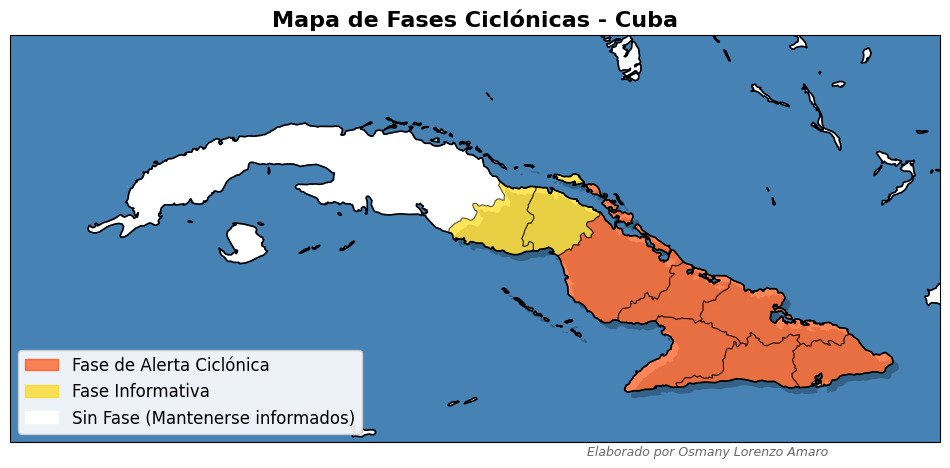

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from shapely.affinity import translate
import matplotlib.patches as mpatches
import os

# --- CARGAR SHAPEFILES ---
ruta_estados = "/content/drive/MyDrive/Colab Notebooks/ne_10m_admin_1_states_provinces/ne_10m_admin_1_states_provinces.shp"
gdf_estados = gpd.read_file(ruta_estados)

ruta_paises = "/content/drive/MyDrive/Colab Notebooks/ne_110m_admin_0_countries/ne_110m_admin_0_countries.shp"
countries = gpd.read_file(ruta_paises)

# --- SELECCIONAR CUBA ---
cuba = countries[countries['ADMIN'] == 'Cuba'].copy()

# --- INTERSECTAR CON PROVINCIAS ---
provincias_cuba = gdf_estados[gdf_estados.intersects(cuba.geometry.iloc[0])].copy()

# --- DEFINIR FASES ---
fase_informativa = ["Sancti Spíritus", "Ciego de Ávila"]
fase_alerta = ["Camagüey", "Las Tunas", "Granma", "Holguín", "Santiago de Cuba", "Guantánamo"]

# --- FILTRAR POR FASES ---
provincias_informativas = provincias_cuba[provincias_cuba['name'].isin(fase_informativa)]
provincias_alerta = provincias_cuba[provincias_cuba['name'].isin(fase_alerta)]

# --- CREAR MAPA ---
fig, ax = plt.subplots(figsize=(12, 10), subplot_kw={'projection': ccrs.PlateCarree()})
ax.set_extent([-86, -73.5, 19.2, 24.3])

# --- BASE Y COSTA 10m ---
ax.add_feature(cfeature.LAND, color='white', zorder=0)
ax.add_feature(cfeature.OCEAN, color='steelblue', zorder=0)

coastline_10m = cfeature.NaturalEarthFeature(
    'physical', 'coastline', '10m',
    edgecolor='black', facecolor='none', linewidth=1.2
)
ax.add_feature(coastline_10m, zorder=3)
ax.add_feature(cfeature.BORDERS, linewidth=0.5, zorder=2)

# --- FUNCIÓN PARA APLICAR SOMBRA (efecto 3D) ---
def aplicar_sombra(gdf, color):
    sombra = gdf.copy()
    sombra['geometry'] = sombra['geometry'].apply(lambda g: translate(g, xoff=0.08, yoff=-0.08))
    sombra.plot(ax=ax, color='black', alpha=0.25, linewidth=0, zorder=1)
    gdf.plot(ax=ax, color=color, alpha=0.65, edgecolor='black', linewidth=0.8, zorder=2)

# --- APLICAR COLORES ---
aplicar_sombra(provincias_informativas, '#FFD700')  # amarillo brillante
aplicar_sombra(provincias_alerta, '#FF4500')        # naranja intenso

# --- LEYENDA ---
amarillo_patch = mpatches.Patch(color='#FFD700', alpha=0.65, label='Fase Informativa')
naranja_patch = mpatches.Patch(color='#FF4500', alpha=0.65, label='Fase de Alerta Ciclónica')
blanco_patch = mpatches.Patch(color='white', label='Sin Fase (Mantenerse informados)')

plt.legend(handles=[naranja_patch, amarillo_patch, blanco_patch],
           loc='lower left', fontsize=12, frameon=True, framealpha=0.9)

# --- TÍTULO ---
plt.title("Mapa de Fases Ciclónicas - Cuba", fontsize=16, weight='bold')


# --- CRÉDITO (con banner) ---
from matplotlib.patches import Rectangle

# Agregar un banner semitransparente en la parte inferior
ax.add_patch(Rectangle(
    (-82, 18.5),  # esquina inferior izquierda (ajusta según tu mapa)
    15,  # ancho del banner
    0.6,  # alto del banner
    transform=ccrs.PlateCarree(),
    color='white',
    alpha=0.6,
    zorder=10
))

# Texto del crédito
plt.text(
    -75, 19, "Elaborado por Osmany Lorenzo Amaro",
    fontsize=9, color='dimgray', ha='right', va='bottom', fontstyle='italic',
    zorder=11
)



# --- GUARDAR MAPA EN ALTA RESOLUCIÓN ---
output_dir = "/content/drive/MyDrive/Colab Notebooks/mapas/alertas"
os.makedirs(output_dir, exist_ok=True)
plt.savefig(f"{output_dir}/fases_ciclonicas_cuba.png", dpi=1200, bbox_inches='tight')

# --- MOSTRAR MAPA ---
plt.show()


DESCARGANDO DATOS DE GEOPOTENCIAL Y VIENTO EN MÚLTIPLES NIVELES
📅 Configuración:
   Fecha de corrida: 20251027
   Hora de corrida: 00Z
   Lead time: 95 horas
   Pronóstico válido para: 2025-10-30 23:00 UTC
   Niveles: [850, 700, 500, 400, 200]

📥 Descargando pronóstico de geopotencial y viento...
   Intentando descargar desde ECMWF...


ERROR:cfgrib.messages:Can't create file './datos_ecmwf/ifs_pl_multi_wind_20251027_00z_lead95h.grib.5b7b6.idx'
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/cfgrib/messages.py", line 539, in from_indexpath_or_filestream
    self = cls.from_fieldset(filestream, index_keys, computed_keys)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/cfgrib/messages.py", line 379, in from_fieldset
    return cls.from_fieldset_and_iteritems(fieldset, iteritems, index_keys, computed_keys)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/cfgrib/messages.py", line 392, in from_fieldset_and_iteritems
    for field_id, raw_field in iteritems:
                               ^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/cfgrib/messages.py", line 292, in __iter__
    for message in self.itervalues():
        

❌ Error en descarga: 404 Client Error: Not Found for url: https://data.ecmwf.int/forecasts/20251027/00z/ifs/0p25/oper/20251027000000-95h-oper-fc.index

💡 GUÍA PARA OBTENER DATOS

📌 OPCIONES PARA DIFERENTES ESCENARIOS:

1️⃣  PRONÓSTICOS RECIENTES (últimos 2-3 días):
   - Usa la fecha de HOY o AYER como 'fecha'
   - Ajusta 'lead_time' para proyectar al futuro

💡 SUGERENCIA ACTUAL:
   - Usa fecha: 20251027
   - Con lead_time apropiado para tu fecha objetivo

CARGANDO GEOPOTENCIAL Y VIENTO EN TODOS LOS NIVELES
❌ Error cargando dataset: [Errno 2] No such file or directory: './datos_ecmwf/ifs_pl_multi_wind_20251027_00z_lead95h.grib'

PROCESANDO DATOS POR NIVEL

📊 Nivel 850 hPa:
   Geopotencial - Rango: [734, 1649] mgp
   Viento U - Rango: [-49.0, 47.2] m/s
   Viento V - Rango: [-31.9, 37.9] m/s
   Velocidad viento - Máx: 39.0 m/s, Media: 6.8 m/s

📊 Nivel 700 hPa:
   Geopotencial - Rango: [2255, 3230] mgp
   Viento U - Rango: [-40.9, 45.4] m/s
   Viento V - Rango: [-25.6, 37.7] m/s
   Velocid

/tmp/ipython-input-2210220687.py:344: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_unico)


   ✓ Nivel 850 hPa procesado (superficie + 273 vectores)
   ✓ Nivel 700 hPa procesado (superficie + 273 vectores)
   ✓ Nivel 500 hPa procesado (superficie + 273 vectores)
   ✓ Nivel 400 hPa procesado (superficie + 273 vectores)
   ✓ Nivel 200 hPa procesado (superficie + 273 vectores)
   ✓ Todas las capas generadas


/tmp/ipython-input-2210220687.py:473: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


✅ Gráfico 3D multi-nivel con vectores guardado: z_wind_multinivel_caribe_3d_20251027_00z_lead95h.png


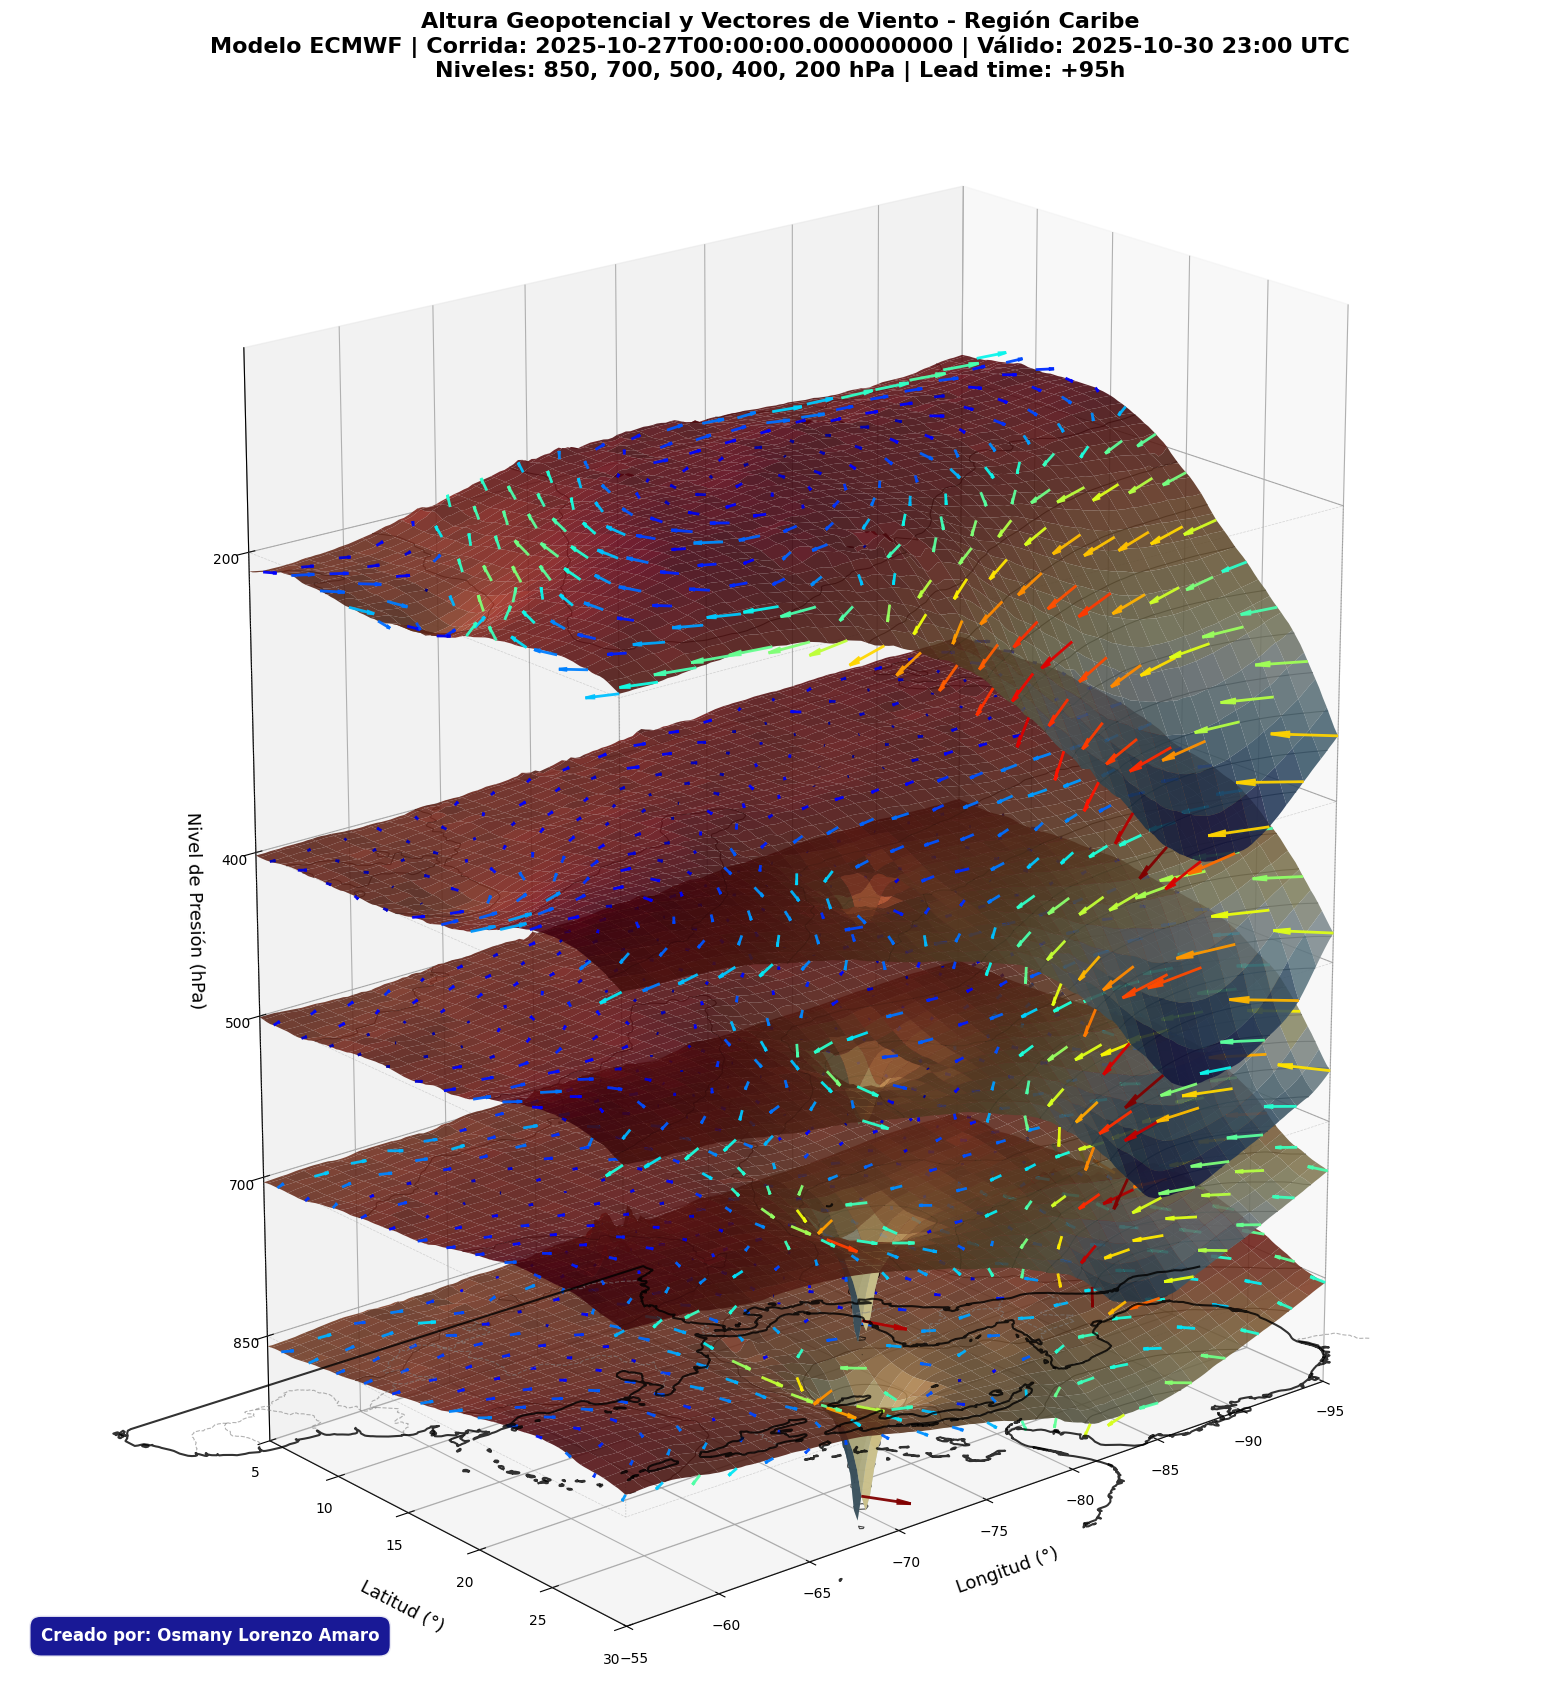


📊 ESTADÍSTICAS POR NIVEL

850 hPa:
  Geopotencial - Media: 1519 mgp
  Geopotencial - Rango: 1307 - 1571 mgp
  Viento - Máx: 39.0 m/s
  Viento - Media: 6.8 m/s

700 hPa:
  Geopotencial - Media: 3158 mgp
  Geopotencial - Rango: 2976 - 3196 mgp
  Viento - Máx: 37.2 m/s
  Viento - Media: 7.0 m/s

500 hPa:
  Geopotencial - Media: 5874 mgp
  Geopotencial - Rango: 5660 - 5915 mgp
  Viento - Máx: 46.2 m/s
  Viento - Media: 7.9 m/s

400 hPa:
  Geopotencial - Media: 7590 mgp
  Geopotencial - Rango: 7310 - 7640 mgp
  Viento - Máx: 54.1 m/s
  Viento - Media: 10.1 m/s

200 hPa:
  Geopotencial - Media: 12446 mgp
  Geopotencial - Rango: 12082 - 12504 mgp
  Viento - Máx: 52.4 m/s
  Viento - Media: 18.9 m/s

🎉 PROCESO COMPLETADO EXITOSAMENTE


In [ ]:
import os
import numpy as np
import xarray as xr
import cfgrib
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
from ecmwf.opendata import Client

# --- CONFIGURACIÓN ---
# IMPORTANTE: Para pronósticos futuros, ajusta estos parámetros
fecha = "20251027"  # YYYYMMDD - Fecha de la corrida del modelo
corrida = "00"  # Hora de corrida: 00 o 12
lead_time = 95  # Horas de pronóstico desde la corrida (0-240)

carpeta = "./datos_ecmwf"
os.makedirs(carpeta, exist_ok=True)

# --- LÍMITES DEL CARIBE ---
lon_min, lon_max = -95, -55
lat_min, lat_max = 5, 30

# --- NIVELES DE PRESIÓN A VISUALIZAR ---
niveles_presion = [850, 700, 500, 400, 200]  # hPa

# --- PARÁMETROS PARA VECTORES DE VIENTO ---
vector_density = 8  # Mostrar 1 de cada N puntos (Mayor = más espaciado)
# Ajusta estos valores si las flechas son muy grandes/pequeñas

# --- FUNCIÓN AUXILIAR PARA CALCULAR FECHA VÁLIDA ---
def calcular_fecha_valida(fecha_str, hora_str, lead_hours):
    """Calcula la fecha válida del pronóstico"""
    from datetime import datetime, timedelta

    year = int(fecha_str[:4])
    month = int(fecha_str[4:6])
    day = int(fecha_str[6:8])
    hour = int(hora_str)

    dt_corrida = datetime(year, month, day, hour)
    dt_valido = dt_corrida + timedelta(hours=lead_hours)

    return dt_valido.strftime("%Y-%m-%d %H:00 UTC")

print("=" * 70)
print("DESCARGANDO DATOS DE GEOPOTENCIAL Y VIENTO EN MÚLTIPLES NIVELES")
print("=" * 70)
print(f"📅 Configuración:")
print(f"   Fecha de corrida: {fecha}")
print(f"   Hora de corrida: {corrida}Z")
print(f"   Lead time: {lead_time} horas")
print(f"   Pronóstico válido para: {calcular_fecha_valida(fecha, corrida, lead_time)}")
print(f"   Niveles: {niveles_presion}")

archivo = f"ifs_pl_multi_wind_{fecha}_{corrida}z_lead{lead_time}h.grib"
ruta_local = os.path.join(carpeta, archivo)

if not os.path.exists(ruta_local):
    print(f"\n📥 Descargando pronóstico de geopotencial y viento...")

    try:
        client = Client(source="ecmwf")

        print(f"   Intentando descargar desde ECMWF...")

        # Descargar geopotencial (gh), componente U (u) y componente V (v) del viento
        client.retrieve(
            date=int(fecha),
            time=int(corrida),
            step=lead_time,
            stream="oper",
            type="fc",
            levtype="pl",
            param=["gh", "u", "v"],  # Geopotencial y componentes del viento
            levelist=niveles_presion,
            target=ruta_local
        )
        print(f"✅ Descarga completada: {ruta_local}")

    except Exception as e:
        print(f"❌ Error en descarga: {e}")
        print("\n" + "=" * 70)
        print("💡 GUÍA PARA OBTENER DATOS")
        print("=" * 70)
        print("\n📌 OPCIONES PARA DIFERENTES ESCENARIOS:")
        print("\n1️⃣  PRONÓSTICOS RECIENTES (últimos 2-3 días):")
        print("   - Usa la fecha de HOY o AYER como 'fecha'")
        print("   - Ajusta 'lead_time' para proyectar al futuro")

        print("\n💡 SUGERENCIA ACTUAL:")
        from datetime import datetime, timedelta
        hoy = datetime.now()
        ayer = hoy - timedelta(days=1)
        print(f"   - Usa fecha: {ayer.strftime('%Y%m%d')}")
        print(f"   - Con lead_time apropiado para tu fecha objetivo")
        print("=" * 70)

        exit(1)
else:
    print(f"✅ Archivo existente encontrado: {ruta_local}")

# --- CARGAR DATOS ---
print("\n" + "=" * 70)
print("CARGANDO GEOPOTENCIAL Y VIENTO EN TODOS LOS NIVELES")
print("=" * 70)

try:
    # Cargar todos los datasets
    datasets = cfgrib.open_datasets(ruta_local)
    print(f"✅ Número de datasets: {len(datasets)}")

    # Encontrar datasets de geopotencial y viento
    ds_gh = None
    ds_u = None
    ds_v = None

    for ds in datasets:
        if 'gh' in ds.data_vars:
            ds_gh = ds
            print(f"   ✓ Geopotencial encontrado")
        if 'u' in ds.data_vars:
            ds_u = ds
            print(f"   ✓ Componente U del viento encontrado")
        if 'v' in ds.data_vars:
            ds_v = ds
            print(f"   ✓ Componente V del viento encontrado")

    if ds_gh is None or ds_u is None or ds_v is None:
        print("❌ No se encontraron todas las variables necesarias")
        exit(1)

    if 'isobaricInhPa' in ds_gh.coords:
        niveles_disponibles = ds_gh.coords['isobaricInhPa'].values
        print(f"   Niveles disponibles: {niveles_disponibles} hPa")

except Exception as e:
    print(f"❌ Error cargando dataset: {e}")
    exit(1)

# --- EXTRAER DATOS POR NIVEL ---
print("\n" + "=" * 70)
print("PROCESANDO DATOS POR NIVEL")
print("=" * 70)

datos_niveles = {}

for nivel in niveles_presion:
    try:
        # Seleccionar nivel específico
        gh_nivel = ds_gh.sel(isobaricInhPa=nivel)
        u_nivel = ds_u.sel(isobaricInhPa=nivel)
        v_nivel = ds_v.sel(isobaricInhPa=nivel)

        z_raw = gh_nivel['gh']
        u_raw = u_nivel['u']
        v_raw = v_nivel['v']

        print(f"\n📊 Nivel {nivel} hPa:")
        print(f"   Geopotencial - Rango: [{z_raw.min().values:.0f}, {z_raw.max().values:.0f}] mgp")
        print(f"   Viento U - Rango: [{u_raw.min().values:.1f}, {u_raw.max().values:.1f}] m/s")
        print(f"   Viento V - Rango: [{v_raw.min().values:.1f}, {v_raw.max().values:.1f}] m/s")

        # Extraer coordenadas
        lons_full = gh_nivel['longitude'].values
        lats_full = gh_nivel['latitude'].values

        # Recortar al Caribe
        lon_mask = (lons_full >= lon_min) & (lons_full <= lon_max)
        lat_mask = (lats_full >= lat_min) & (lats_full <= lat_max)

        lons = lons_full[lon_mask]
        lats = lats_full[lat_mask]
        z_caribe = z_raw.values[np.ix_(lat_mask, lon_mask)]
        u_caribe = u_raw.values[np.ix_(lat_mask, lon_mask)]
        v_caribe = v_raw.values[np.ix_(lat_mask, lon_mask)]

        # Calcular magnitud del viento
        wind_speed = np.sqrt(u_caribe**2 + v_caribe**2)

        datos_niveles[nivel] = {
            'lons': lons,
            'lats': lats,
            'z': z_caribe,
            'u': u_caribe,
            'v': v_caribe,
            'speed': wind_speed,
            'z_min': z_caribe.min(),
            'z_max': z_caribe.max(),
            'z_media': z_caribe.mean(),
            'wind_max': wind_speed.max(),
            'wind_media': wind_speed.mean()
        }

        print(f"   Velocidad viento - Máx: {wind_speed.max():.1f} m/s, Media: {wind_speed.mean():.1f} m/s")

    except Exception as e:
        print(f"   ❌ Error procesando nivel {nivel} hPa: {e}")

if len(datos_niveles) == 0:
    print("\n❌ No se pudieron cargar datos")
    exit(1)

print(f"\n✅ {len(datos_niveles)} niveles procesados correctamente")

# --- ASIGNAR POSICIONES EN EJE Z ---
posiciones_z = {
    850: 10,
    700: 25,
    500: 40,
    400: 55,
    250: 70,
    200: 82,
    100: 95
}

# --- VISUALIZACIÓN 3D CON MÚLTIPLES CAPAS, MAPA BASE Y VECTORES ---
print("\n" + "=" * 70)
print("GENERANDO VISUALIZACIÓN 3D MULTI-NIVEL CON VECTORES DE VIENTO")
print("=" * 70)

fig = plt.figure(figsize=(24, 20))
ax = fig.add_subplot(111, projection='3d')

# Dibujar mapa base en Z=0
print("   Proyectando mapa base en Z=0...")

from cartopy.feature import COASTLINE, BORDERS

# Dibujar líneas de costa
for geom in COASTLINE.geometries():
    if geom.geom_type == 'LineString':
        coords = np.array(geom.coords)
        lons_costa = coords[:, 0]
        lats_costa = coords[:, 1]

        mask = ((lons_costa >= lon_min - 5) & (lons_costa <= lon_max + 5) &
                (lats_costa >= lat_min - 5) & (lats_costa <= lat_max + 5))

        if np.any(mask):
            lons_segmento = lons_costa[mask]
            lats_segmento = lats_costa[mask]
            z_segmento = np.zeros_like(lons_segmento) + 0.1

            ax.plot(lons_segmento, lats_segmento, z_segmento,
                   color='black', linewidth=1.5, alpha=0.8, zorder=10)
    elif geom.geom_type == 'MultiLineString':
        for line in geom.geoms:
            coords = np.array(line.coords)
            lons_costa = coords[:, 0]
            lats_costa = coords[:, 1]

            mask = ((lons_costa >= lon_min - 5) & (lons_costa <= lon_max + 5) &
                    (lats_costa >= lat_min - 5) & (lats_costa <= lat_max + 5))

            if np.any(mask):
                lons_segmento = lons_costa[mask]
                lats_segmento = lats_costa[mask]
                z_segmento = np.zeros_like(lons_segmento) + 0.1

                ax.plot(lons_segmento, lats_segmento, z_segmento,
                       color='black', linewidth=1.5, alpha=0.8, zorder=10)

# Dibujar fronteras
for geom in BORDERS.geometries():
    if geom.geom_type == 'LineString':
        coords = np.array(geom.coords)
        lons_frontera = coords[:, 0]
        lats_frontera = coords[:, 1]

        mask = ((lons_frontera >= lon_min - 5) & (lons_frontera <= lon_max + 5) &
                (lats_frontera >= lat_min - 5) & (lats_frontera <= lat_max + 5))

        if np.any(mask):
            lons_segmento = lons_frontera[mask]
            lats_segmento = lats_frontera[mask]
            z_segmento = np.zeros_like(lons_segmento) + 0.1

            ax.plot(lons_segmento, lats_segmento, z_segmento,
                   color='gray', linewidth=0.8, alpha=0.6, linestyle='--', zorder=9)
    elif geom.geom_type == 'MultiLineString':
        for line in geom.geoms:
            coords = np.array(line.coords)
            lons_frontera = coords[:, 0]
            lats_frontera = coords[:, 1]

            mask = ((lons_frontera >= lon_min - 5) & (lons_frontera <= lon_max + 5) &
                    (lats_frontera >= lat_min - 5) & (lats_frontera <= lat_max + 5))

            if np.any(mask):
                lons_segmento = lons_frontera[mask]
                lats_segmento = lats_frontera[mask]
                z_segmento = np.zeros_like(lons_segmento) + 0.1

                ax.plot(lons_segmento, lats_segmento, z_segmento,
                       color='gray', linewidth=0.8, alpha=0.6, linestyle='--', zorder=9)

# Grid de lat/lon en Z=0
for lon in range(int(lon_min), int(lon_max) + 1, 10):
    lat_line = np.linspace(lat_min, lat_max, 50)
    lon_line = np.full_like(lat_line, lon)
    z_line = np.zeros_like(lat_line) + 0.05
    ax.plot(lon_line, lat_line, z_line, color='gray', linewidth=0.5, alpha=0.3, zorder=2)

for lat in range(int(lat_min), int(lat_max) + 1, 5):
    lon_line = np.linspace(lon_min, lon_max, 50)
    lat_line = np.full_like(lon_line, lat)
    z_line = np.zeros_like(lat_line) + 0.05
    ax.plot(lon_line, lat_line, z_line, color='gray', linewidth=0.5, alpha=0.3, zorder=2)

print("   ✓ Mapa base proyectado")

# Paleta de colores
cmap_unico = 'RdYlBu_r'
factor_escala = 0.08

print("   Generando capas de geopotencial con vectores de viento...")

# Plotear cada nivel
for i, nivel in enumerate(sorted(niveles_presion, reverse=True)):
    if nivel not in datos_niveles:
        continue

    datos = datos_niveles[nivel]
    lons = datos['lons']
    lats = datos['lats']
    z_geo = datos['z']
    u = datos['u']
    v = datos['v']

    # Crear malla
    lon2d, lat2d = np.meshgrid(lons, lats)

    # Posición base en Z para este nivel
    z_base = posiciones_z[nivel]

    # Agregar ondulaciones escaladas
    z_desviacion = z_geo - z_geo.mean()
    z_superficie = z_base + (z_desviacion * factor_escala)

    # Normalizar colores
    norm = plt.Normalize(vmin=z_geo.min(), vmax=z_geo.max())
    cmap = cm.get_cmap(cmap_unico)
    colors = cmap(norm(z_geo))

    # Plotear superficie
    surf = ax.plot_surface(
        lon2d, lat2d, z_superficie,
        facecolors=colors,
        alpha=0.88,  # Restaurado al valor original
        edgecolor='none',
        antialiased=True,
        shade=True,
        lightsource=plt.matplotlib.colors.LightSource(azdeg=315, altdeg=45),
        zorder=100 + i
    )

    # Contornos sobre la superficie (más oscuros para contraste)
    contours = ax.contour(
        lon2d, lat2d, z_superficie,
        levels=12,
        colors='black',
        linewidths=0.8,
        alpha=0.7,  # Restaurado al valor original
        linestyles='solid',
        zorder=200 + i
    )

    # VECTORES DE VIENTO
    # Submuestrear los datos para evitar saturación
    lon2d_sub = lon2d[::vector_density, ::vector_density]
    lat2d_sub = lat2d[::vector_density, ::vector_density]
    z_sub = z_superficie[::vector_density, ::vector_density]
    u_sub = u[::vector_density, ::vector_density]
    v_sub = v[::vector_density, ::vector_density]

    # Aplanar arrays para usar con quiver
    lon_flat = lon2d_sub.flatten()
    lat_flat = lat2d_sub.flatten()
    z_flat = z_sub.flatten()
    u_flat = u_sub.flatten()
    v_flat = v_sub.flatten()

    # Calcular la magnitud del viento para colorear Y escalar
    wind_mag = np.sqrt(u_flat**2 + v_flat**2)

    # Normalizar para obtener colores (rojo = rápido, azul = lento)
    norm_wind = plt.Normalize(vmin=wind_mag.min(), vmax=wind_mag.max())
    wind_colors = plt.cm.jet(norm_wind(wind_mag))

    # ESCALAR las componentes U y V por la magnitud
    # Esto hace que vectores con más velocidad sean más largos
    # NO usar normalize=True para que respeten sus magnitudes reales
    scale_factor = 0.08  # Factor de escala global reducido para flechas más pequeñas
    u_scaled = u_flat * scale_factor
    v_scaled = v_flat * scale_factor

    # Dibujar TODOS los vectores de una vez con quiver
    # SIN normalize=True para que el tamaño refleje la intensidad
    quiv = ax.quiver(lon_flat, lat_flat, z_flat,
                     u_scaled, v_scaled, np.zeros_like(u_flat),  # dz = 0 (horizontal)
                     colors=wind_colors,
                     arrow_length_ratio=0.3,  # Reducido para flechas variables
                     linewidth=2.0,
                     alpha=0.95,
                     zorder=300 + i)

    print(f"   ✓ Nivel {nivel} hPa procesado (superficie + {len(lon_flat)} vectores)")

print("   ✓ Todas las capas generadas")

# Líneas de referencia
for lon_corner in [lon_min, lon_max]:
    for lat_corner in [lat_min, lat_max]:
        z_linea = [posiciones_z[n] for n in sorted(niveles_presion)]
        ax.plot([lon_corner]*len(z_linea), [lat_corner]*len(z_linea), z_linea,
               'gray', linestyle=':', linewidth=0.8, alpha=0.4)

for nivel in niveles_presion:
    z_nivel = posiciones_z[nivel]
    corners_lon = [lon_min, lon_max, lon_max, lon_min, lon_min]
    corners_lat = [lat_min, lat_min, lat_max, lat_max, lat_min]
    corners_z = [z_nivel] * 5
    ax.plot(corners_lon, corners_lat, corners_z,
           'gray', linestyle='--', linewidth=0.5, alpha=0.3)

# Configuración de ejes
ax.set_xlabel('Longitud (°)', fontsize=13, labelpad=12)
ax.set_ylabel('Latitud (°)', fontsize=13, labelpad=12)
ax.set_zlabel('Nivel de Presión (hPa)', fontsize=13, labelpad=12)

z_ticks = [posiciones_z[n] for n in sorted(niveles_presion)]
z_labels = [f'{n}' for n in sorted(niveles_presion)]
ax.set_zticks(z_ticks)
ax.set_zticklabels(z_labels)

# Título
tiempo = ds_gh.get('time', ds_gh.get('valid_time', fecha))
fecha_valida = calcular_fecha_valida(fecha, corrida, lead_time)

ax.set_title(
    f'Altura Geopotencial y Vectores de Viento - Región Caribe\n' +
    f'Modelo ECMWF | Corrida: {tiempo.values} | Válido: {fecha_valida}\n' +
    f'Niveles: {", ".join([str(n) for n in sorted(niveles_presion, reverse=True)])} hPa | Lead time: +{lead_time}h',
    fontsize=16,
    fontweight='bold',
    pad=40
)

# Vista óptima
ax.view_init(elev=20, azim=50)
ax.set_xlim(lon_min, lon_max)
ax.set_ylim(lat_min, lat_max)
ax.set_zlim(0, 100)

ax.set_box_aspect([
    (lon_max - lon_min),
    (lat_max - lat_min),
    50
])

# Crédito
ax.text2D(0.02, 0.02, 'Creado por: Osmany Lorenzo Amaro',
          transform=ax.transAxes,
          fontsize=12,
          fontweight='bold',
          color='white',
          bbox=dict(boxstyle='round,pad=0.7', facecolor='darkblue', alpha=0.9,
                    edgecolor='white', linewidth=2),
          zorder=1000)

plt.tight_layout()
archivo_3d = f'z_wind_multinivel_caribe_3d_{fecha}_{corrida}z_lead{lead_time}h.png'
plt.savefig(archivo_3d, dpi=300, bbox_inches='tight', facecolor='white')
print(f"✅ Gráfico 3D multi-nivel con vectores guardado: {archivo_3d}")
plt.show()

# --- ESTADÍSTICAS FINALES ---
print("\n" + "=" * 70)
print("📊 ESTADÍSTICAS POR NIVEL")
print("=" * 70)

for nivel in sorted(niveles_presion, reverse=True):
    if nivel in datos_niveles:
        datos = datos_niveles[nivel]
        print(f"\n{nivel} hPa:")
        print(f"  Geopotencial - Media: {datos['z_media']:.0f} mgp")
        print(f"  Geopotencial - Rango: {datos['z_min']:.0f} - {datos['z_max']:.0f} mgp")
        print(f"  Viento - Máx: {datos['wind_max']:.1f} m/s")
        print(f"  Viento - Media: {datos['wind_media']:.1f} m/s")

print("\n" + "=" * 70)
print("🎉 PROCESO COMPLETADO EXITOSAMENTE")
print("=" * 70)

In [ ]:
 pip install pyvista

In [ ]:
pip install mayavi

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 29.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 47.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 74.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 45.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 230.1/230.1 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 270.0/270.0 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 3.0 MB/s eta 0:00:00
  Created wheel for mayavi: filename=mayavi-4.8.3-cp312-cp312-linux_x86_64.whl size=19564121 sha256=79748ca1aa41cac933f6baa6b5a7321379438f0f0fe19406d91a5dd61a8538d6
  Stored in directory: /root/.cache/pip/wheels/14/f5/ee/dfed85e4c517b003b5b67c161378a1b5d1baa9f176749c7b6f
Successfully built mayavi


✅ PyVista disponible
✅ Modo: Google Colab
VISUALIZACIÓN 3D VOLUMÉTRICA: NUBES + TOPOGRAFÍA
📍 Región: Caribe (-95°E a -55°E, 5°N a 30°N)
📅 Fecha: 20251027, Corrida: 18Z, Lead time: +72h

☁️  DESCARGANDO DATOS DE NUBES...
⚠️  Error: 404 Client Error: Not Found for url: https://data.ecmwf.int/forecasts/20251027/18z/ifs/0p25/scda/20251027180000-72h-scda-fc.index
💡 Usando datos sintéticos...

🏔️  GENERANDO TOPOGRAFÍA DEL CARIBE...
   Grid: 101 x 64 puntos
   Elevación: min=-58m, max=4496m

☁️  PROCESANDO ESTRUCTURA DE NUBES...
   Generando nubes sintéticas realistas...
   ✅ Nubes sintéticas: min=1390m, max=19480m

🎨 GENERANDO VISUALIZACIÓN 3D VOLUMÉTRICA...
   Creando mapa base con países y océanos...
   Dibujando costas y fronteras...
   ✅ Costas y fronteras dibujadas
   Creando superficie del terreno con relieve...
   Creando estructura volumétrica de nubes...
   ✅ Nubes volumétricas creadas
   Configurando iluminación cinematográfica...
   Añadiendo elementos geográficos...
   Configuran

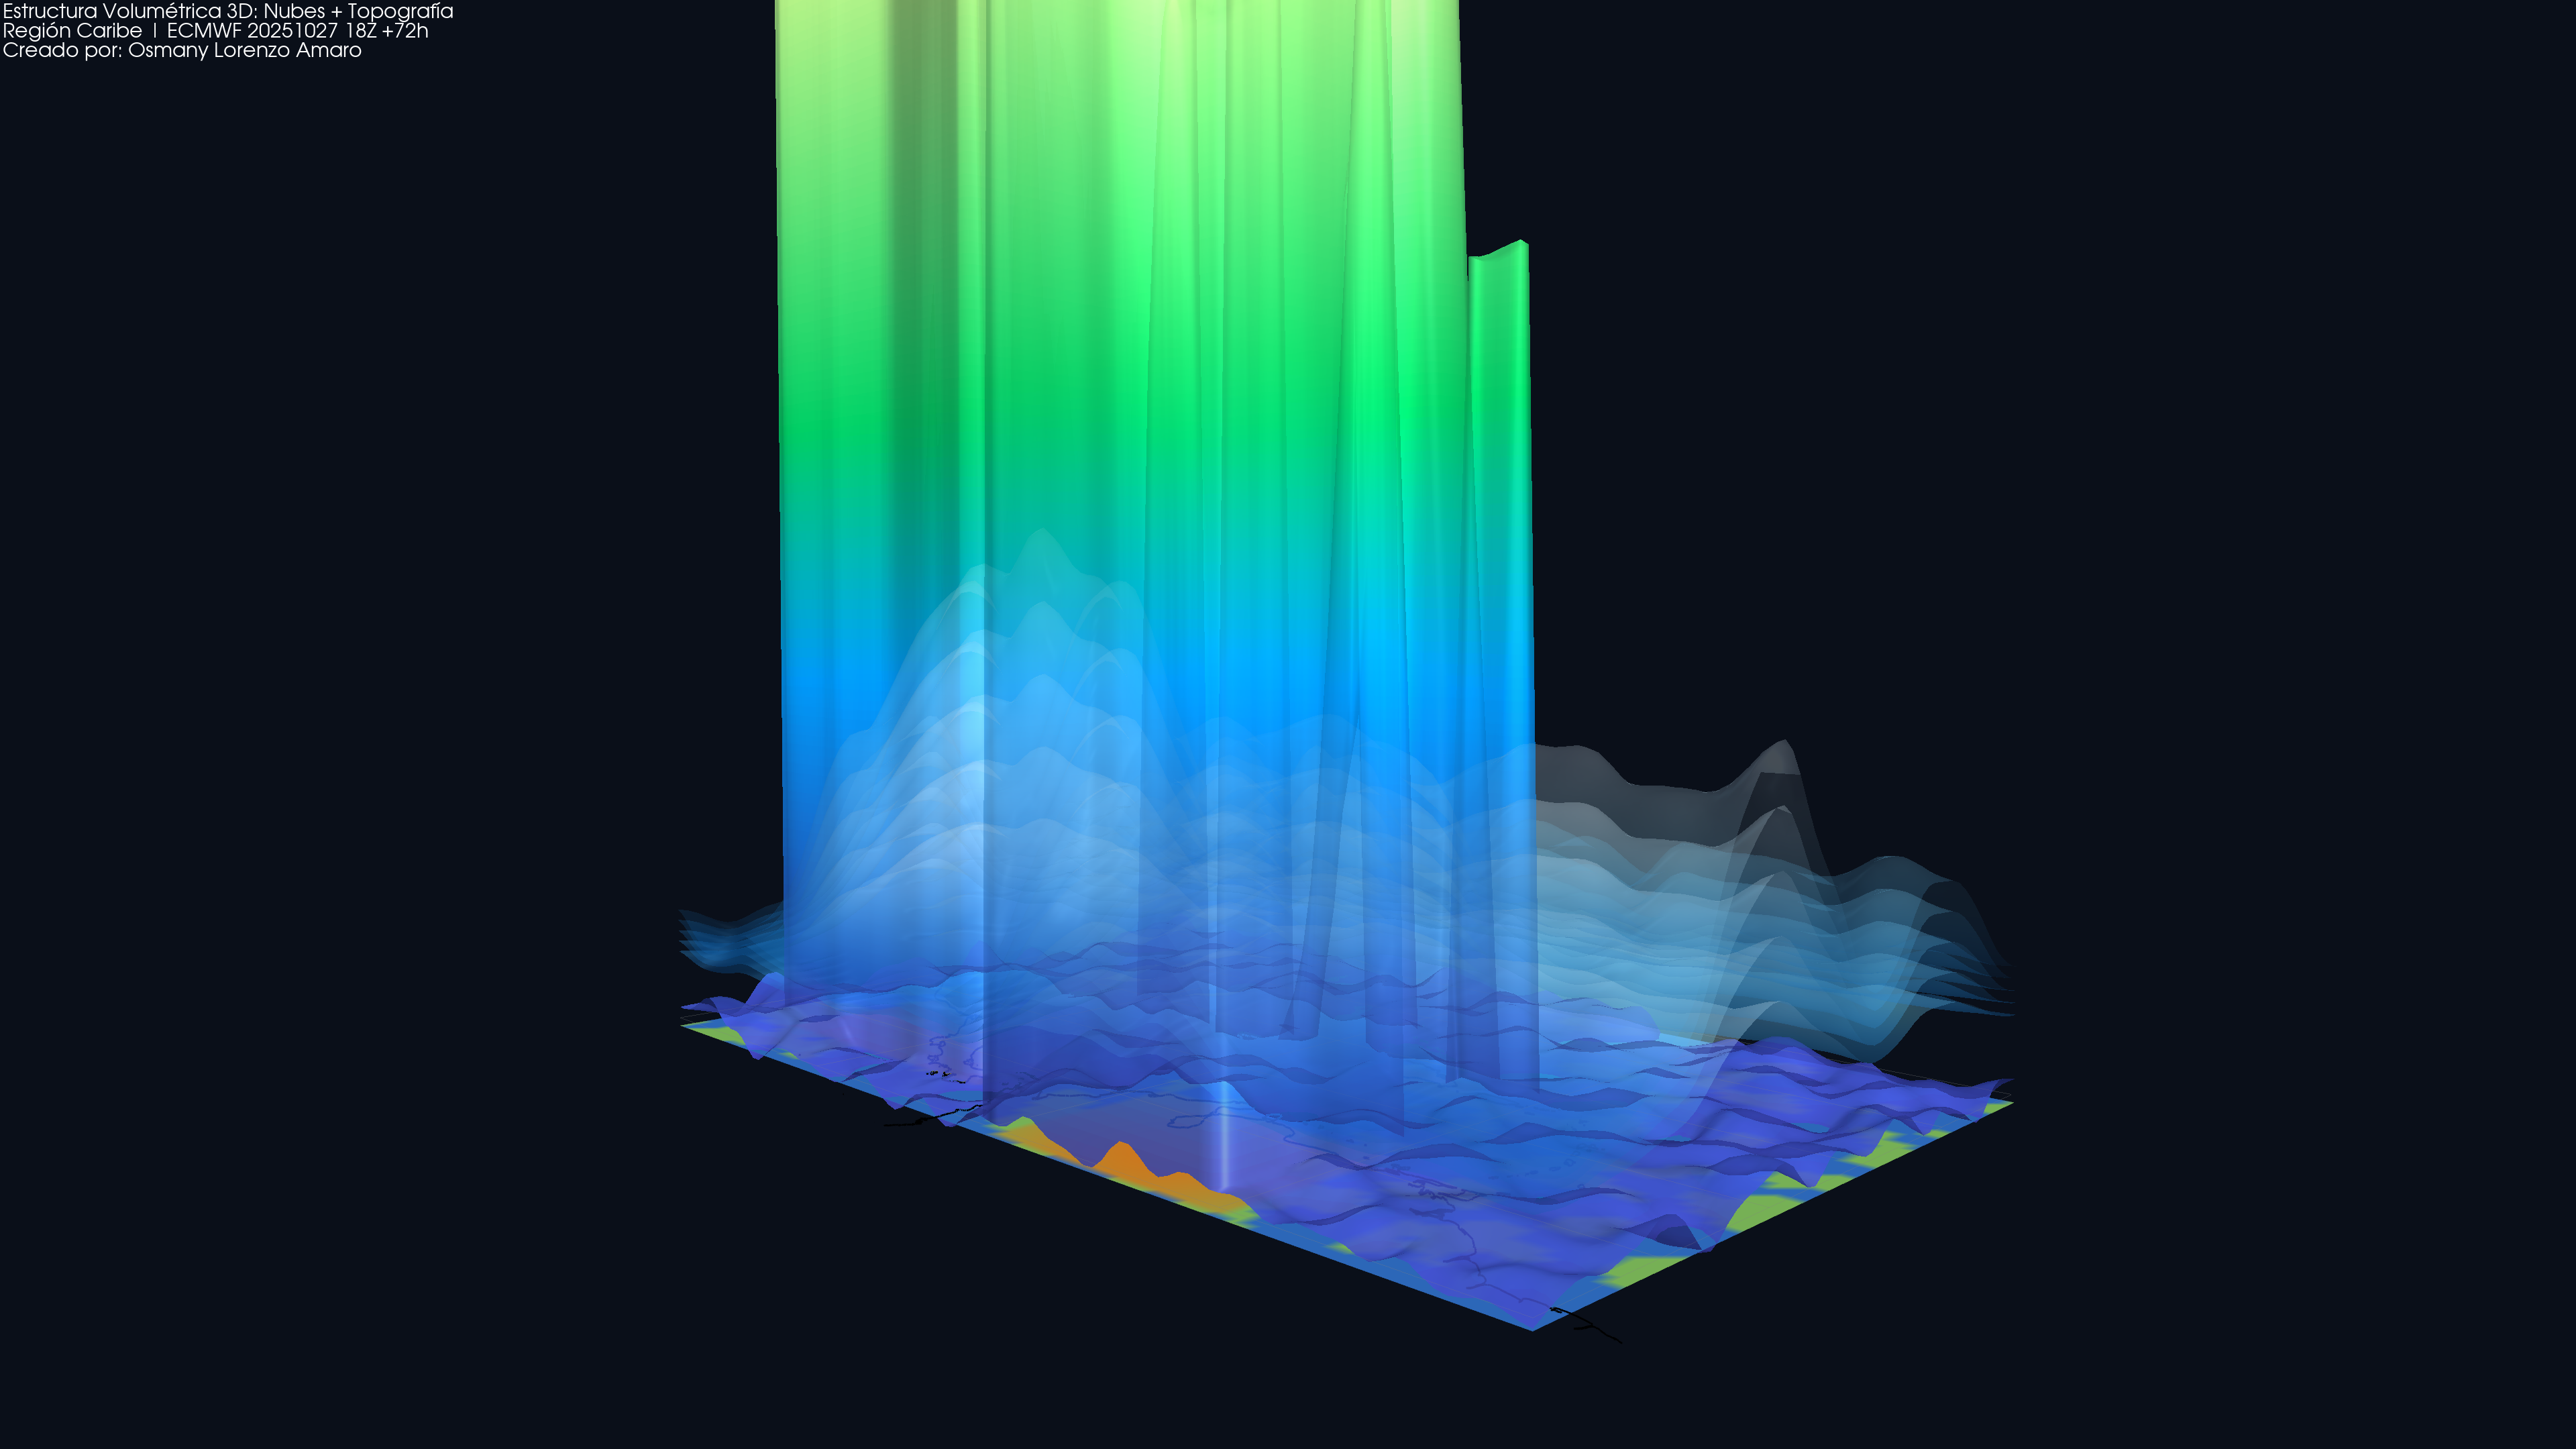


🖼️  Imagen mostrada en Colab

📊 ESTADÍSTICAS DE LA VISUALIZACIÓN

🏔️  Topografía:
   • Elevación máxima: 4496 m
   • Elevación mínima: -58 m
   • Rango: 4554 m

☁️  Nubes:
   • Altura máxima: 19480 m
   • Altura promedio: 6727 m
   • Cobertura nubosa: 100.0%

🎨 Parámetros de visualización:
   • z_scale_terrain = 0.02
   • z_scale_clouds = 0.001
   • z_offset_clouds = 1.5
   • resolution = 0.4°
   • Capas de nubes: 5

🎉 VISUALIZACIÓN COMPLETADA EXITOSAMENTE


In [ ]:
import os
import numpy as np
import xarray as xr
import cfgrib
from ecmwf.opendata import Client
from scipy.ndimage import zoom, gaussian_filter
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# Instalar PyVista si no está disponible
try:
    import pyvista as pv
    print("✅ PyVista disponible")
except ImportError:
    print("📦 Instalando PyVista...")
    import subprocess
    import sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'pyvista', 'trame'])
    import pyvista as pv
    print("✅ PyVista instalado")

# Detectar si estamos en Colab/Jupyter
try:
    import google.colab
    EN_COLAB = True
    pv.set_jupyter_backend('static')  # Mejor para Colab
    print("✅ Modo: Google Colab")
except:
    EN_COLAB = False
    try:
        get_ipython()
        pv.set_jupyter_backend('trame')  # Interactivo para Jupyter
        print("✅ Modo: Jupyter Notebook")
    except:
        pv.set_jupyter_backend('static')  # Estático para scripts
        print("✅ Modo: Script Python")

# --- CONFIGURACIÓN ---
fecha = "20251027"
corrida = "18"
lead_time = 72
carpeta = "./datos_ecmwf"
os.makedirs(carpeta, exist_ok=True)

# --- REGIÓN CARIBE ---
lon_min, lon_max = -95, -55
lat_min, lat_max = 5, 30

# --- PARÁMETROS DE VISUALIZACIÓN ---
z_scale_terrain = 0.020     # Exageración vertical del terreno (aumentado)
z_scale_clouds = 0.001      # Escala vertical de las nubes
z_offset_clouds = 1.5       # Altura base de las nubes (reducido para mejor vista)
resolution = 0.4            # Resolución en grados (menor = más detalle)

print("=" * 70)
print("VISUALIZACIÓN 3D VOLUMÉTRICA: NUBES + TOPOGRAFÍA")
print("=" * 70)
print(f"📍 Región: Caribe ({lon_min}°E a {lon_max}°E, {lat_min}°N a {lat_max}°N)")
print(f"📅 Fecha: {fecha}, Corrida: {corrida}Z, Lead time: +{lead_time}h")

# =============================================================================
# PASO 1: DESCARGAR DATOS DE NUBES
# =============================================================================
print("\n☁️  DESCARGANDO DATOS DE NUBES...")

archivo_nubes = f"ifs_sfc_clouds_{fecha}_{corrida}z_lead{lead_time}h.grib"
ruta_nubes = os.path.join(carpeta, archivo_nubes)

if not os.path.exists(ruta_nubes):
    try:
        client = Client(source="ecmwf")

        client.retrieve(
            date=int(fecha),
            time=int(corrida),
            step=lead_time,
            stream="oper",
            type="fc",
            levtype="sfc",
            param=["tcc", "lcc", "mcc", "hcc"],  # Total, Low, Medium, High cloud cover
            target=ruta_nubes
        )
        print(f"✅ Datos descargados: {ruta_nubes}")

    except Exception as e:
        print(f"⚠️  Error: {e}")
        print("💡 Usando datos sintéticos...")
        ruta_nubes = None
else:
    print(f"✅ Archivo encontrado: {ruta_nubes}")

# =============================================================================
# PASO 2: GENERAR TOPOGRAFÍA REALISTA
# =============================================================================
print("\n🏔️  GENERANDO TOPOGRAFÍA DEL CARIBE...")

def crear_topografia_caribe(lons, lats):
    """Genera topografía realista del Caribe con montañas y océano"""
    lon2d, lat2d = np.meshgrid(lons, lats)
    elevation = np.zeros_like(lon2d)

    # Cordillera de los Andes (Venezuela/Colombia)
    andes = ((lon2d > -75) & (lon2d < -65) & (lat2d > 5) & (lat2d < 12))
    elevation += andes * 4500 * np.exp(-((lon2d + 70)**2 + (lat2d - 8)**2) / 40)

    # Sierra Madre (México)
    mexico = ((lon2d > -105) & (lon2d < -95) & (lat2d > 15) & (lat2d < 25))
    elevation += mexico * 3500 * (1 + 0.4 * np.sin(lat2d * 1.5))

    # Centroamérica
    central = ((lon2d > -92) & (lon2d < -80) & (lat2d > 8) & (lat2d < 18))
    elevation += central * 2800 * (1 + 0.3 * np.cos(lon2d / 3))

    # Montañas de Cuba
    cuba = ((lon2d > -85) & (lon2d < -74) & (lat2d > 19.5) & (lat2d < 23))
    elevation += cuba * 2000 * np.exp(-((lat2d - 21)**2) / 3)

    # Hispaniola (Rep. Dominicana/Haití)
    hispaniola = ((lon2d > -75) & (lon2d < -68) & (lat2d > 17.5) & (lat2d < 20))
    elevation += hispaniola * 3100 * np.exp(-((lon2d + 71)**2 + (lat2d - 19)**2) / 5)

    # Jamaica
    jamaica = ((lon2d > -78.5) & (lon2d < -76) & (lat2d > 17.5) & (lat2d < 18.5))
    elevation += jamaica * 2200

    # Puerto Rico
    puerto_rico = ((lon2d > -67.5) & (lon2d < -65) & (lat2d > 17.8) & (lat2d < 18.6))
    elevation += puerto_rico * 1300

    # Textura/rugosidad
    np.random.seed(42)
    noise = np.random.randn(*elevation.shape) * 80
    elevation += gaussian_filter(noise, sigma=1.5)

    # Océano (ligeramente negativo)
    elevation = np.maximum(elevation, -200)

    return elevation

lons = np.arange(lon_min, lon_max + resolution, resolution)
lats = np.arange(lat_min, lat_max + resolution, resolution)

elevation = crear_topografia_caribe(lons, lats)
print(f"   Grid: {len(lons)} x {len(lats)} puntos")
print(f"   Elevación: min={elevation.min():.0f}m, max={elevation.max():.0f}m")

# =============================================================================
# PASO 3: PROCESAR DATOS DE NUBES
# =============================================================================
print("\n☁️  PROCESANDO ESTRUCTURA DE NUBES...")

cloud_height = None

if ruta_nubes and os.path.exists(ruta_nubes):
    try:
        ds_nubes = cfgrib.open_dataset(ruta_nubes)

        lcc = ds_nubes['lcc'].values if 'lcc' in ds_nubes else None
        mcc = ds_nubes['mcc'].values if 'mcc' in ds_nubes else None
        hcc = ds_nubes['hcc'].values if 'hcc' in ds_nubes else None

        lons_nubes = ds_nubes['longitude'].values
        lats_nubes = ds_nubes['latitude'].values

        lon_mask = (lons_nubes >= lon_min) & (lons_nubes <= lon_max)
        lat_mask = (lats_nubes >= lat_min) & (lats_nubes <= lat_max)

        cloud_height = np.zeros((len(lats), len(lons)))

        if lcc is not None:
            lcc_crop = lcc[np.ix_(lat_mask, lon_mask)]
            lcc_interp = zoom(lcc_crop, (len(lats)/lcc_crop.shape[0], len(lons)/lcc_crop.shape[1]))
            cloud_height += lcc_interp * 1500

        if mcc is not None:
            mcc_crop = mcc[np.ix_(lat_mask, lon_mask)]
            mcc_interp = zoom(mcc_crop, (len(lats)/mcc_crop.shape[0], len(lons)/mcc_crop.shape[1]))
            cloud_height += mcc_interp * 4000

        if hcc is not None:
            hcc_crop = hcc[np.ix_(lat_mask, lon_mask)]
            hcc_interp = zoom(hcc_crop, (len(lats)/hcc_crop.shape[0], len(lons)/hcc_crop.shape[1]))
            cloud_height += hcc_interp * 12000

        print(f"   ✅ Altura nubes: min={cloud_height.min():.0f}m, max={cloud_height.max():.0f}m")

    except Exception as e:
        print(f"   ⚠️  Error: {e}")
        cloud_height = None

# Generar nubes sintéticas si no hay datos reales
if cloud_height is None:
    print("   Generando nubes sintéticas realistas...")
    lon2d, lat2d = np.meshgrid(lons, lats)
    cloud_height = np.zeros_like(lon2d)

    # Nubes convectivas (torres sobre tierra caliente)
    convective = (elevation > 800) & (np.random.rand(*lon2d.shape) > 0.55)
    cloud_height += convective * (9000 + 6000 * np.random.rand(*lon2d.shape))

    # Nubes estratiformes (capas sobre océano)
    stratiform = (elevation < 100) & (np.random.rand(*lon2d.shape) > 0.4)
    cloud_height += stratiform * (2500 + 2000 * np.random.rand(*lon2d.shape))

    # Nubes orográficas (se forman en montañas)
    orographic = (elevation > 1500)
    cloud_height += orographic * (elevation * 0.6 + 3000 * np.random.rand(*lon2d.shape))

    # Sistemas frontales (bandas de nubes)
    for i in range(3):
        center_lat_cloud = np.random.uniform(lat_min + 5, lat_max - 5)
        frontal = np.exp(-((lat2d - center_lat_cloud)**2) / 10) * (np.random.rand(*lon2d.shape) > 0.3)
        cloud_height += frontal * (5000 + 4000 * np.random.rand(*lon2d.shape))

    cloud_height = gaussian_filter(cloud_height, sigma=2)
    print(f"   ✅ Nubes sintéticas: min={cloud_height.min():.0f}m, max={cloud_height.max():.0f}m")

# =============================================================================
# PASO 4: CREAR VISUALIZACIÓN 3D VOLUMÉTRICA CON PYVISTA
# =============================================================================
print("\n🎨 GENERANDO VISUALIZACIÓN 3D VOLUMÉTRICA...")

# Crear plotter
plotter = pv.Plotter(window_size=[1920, 1080], off_screen=True)
plotter.set_background('#0a0f19')  # Azul oscuro espacial

# Preparar datos
lon2d, lat2d = np.meshgrid(lons, lats)

# Calcular centro de la región
center_lon = np.mean([lon_min, lon_max])
center_lat = np.mean([lat_min, lat_max])

# Initialize center_z with a base value, to ensure it's always defined
center_z = z_offset_clouds

# Calculate center_z based on cloud_height, if available and valid
if cloud_height is not None and cloud_height.size > 0:
    center_z = z_offset_clouds + (cloud_height.max() * z_scale_clouds) / 2
else:
    print("⚠️  cloud_height is not valid or empty, using default center_z for camera.")
    # If no clouds, or invalid, set center_z to be a bit above the max terrain
    center_z = z_offset_clouds + (elevation.max() * z_scale_terrain) / 2 + 1

# --- CAPA 0: MAPA BASE PLANO (PAÍSES Y OCÉANOS) ---
print("   Creando mapa base con países y océanos...")

# Crear superficie plana en z=0 para el mapa base
z_base = np.zeros_like(lon2d) - 0.5  # Ligeramente debajo del nivel del mar

points_base = np.c_[lon2d.ravel(), lat2d.ravel(), z_base.ravel()]

# Crear malla de cuadrados
faces_base = []
for i in range(len(lats) - 1):
    for j in range(len(lons) - 1):
        idx = i * len(lons) + j
        faces_base.extend([4, idx, idx + 1, idx + len(lons) + 1, idx + len(lons)])

faces_base = np.array(faces_base)
base_mesh = pv.PolyData(points_base, faces_base)

# Crear textura de mapa base (océano/tierra)
map_colors = np.zeros((*elevation.shape, 3))

# Océanos en azul
ocean_mask = elevation < 10
map_colors[ocean_mask] = [0.15, 0.35, 0.65]  # Azul océano

# Tierra en verde/marrón según elevación
land_mask = ~ocean_mask
elevation_land = elevation[land_mask]
if len(elevation_land) > 0:
    elev_norm = (elevation_land - elevation_land.min()) / (elevation_land.max() - elevation_land.min() + 1e-10)
    map_colors[land_mask, 0] = 0.4 + 0.3 * elev_norm  # R
    map_colors[land_mask, 1] = 0.6 - 0.2 * elev_norm  # G
    map_colors[land_mask, 2] = 0.3 - 0.2 * elev_norm  # B

base_mesh['rgb'] = (map_colors.reshape(-1, 3) * 255).astype(np.uint8)

plotter.add_mesh(
    base_mesh,
    scalars='rgb',
    rgb=True,
    lighting=True,
    ambient=0.5,
    diffuse=0.5,
    show_scalar_bar=False,
    opacity=1.0
)

# --- AÑADIR LÍNEAS DE COSTA Y FRONTERAS ---
print("   Dibujando costas y fronteras...")

try:
    import cartopy.feature as cfeature
    from cartopy.feature import COASTLINE, BORDERS

    # Dibujar líneas de costa
    for geom in COASTLINE.geometries():
        try:
            if geom.geom_type == 'LineString':
                coords = np.array(geom.coords)
                lons_costa = coords[:, 0]
                lats_costa = coords[:, 1]

                mask = ((lons_costa >= lon_min - 2) & (lons_costa <= lon_max + 2) &
                        (lats_costa >= lat_min - 2) & (lats_costa <= lat_max + 2))

                if np.any(mask):
                    lons_seg = lons_costa[mask]
                    lats_seg = lats_costa[mask]
                    z_seg = np.zeros_like(lons_seg) - 0.3

                    points = np.c_[lons_seg, lats_seg, z_seg]
                    if len(points) > 1:
                        line = pv.lines_from_points(points)
                        plotter.add_mesh(line, color='black', line_width=3, opacity=1.0)

            elif geom.geom_type == 'MultiLineString':
                for subgeom in geom.geoms:
                    coords = np.array(subgeom.coords)
                    lons_costa = coords[:, 0]
                    lats_costa = coords[:, 1]

                    mask = ((lons_costa >= lon_min - 2) & (lons_costa <= lon_max + 2) &
                            (lats_costa >= lat_min - 2) & (lats_costa <= lat_max + 2))

                    if np.any(mask):
                        lons_seg = lons_costa[mask]
                        lats_seg = lats_costa[mask]
                        z_seg = np.zeros_like(lons_seg) - 0.3

                        points = np.c_[lons_seg, lats_seg, z_seg]
                        if len(points) > 1:
                            line = pv.lines_from_points(points)
                            plotter.add_mesh(line, color='black', line_width=3, opacity=1.0)
        except:
            continue

    # Dibujar fronteras
    for geom in BORDERS.geometries():
        try:
            if geom.geom_type == 'LineString':
                coords = np.array(geom.coords)
                lons_front = coords[:, 0]
                lats_front = coords[:, 1]

                mask = ((lons_front >= lon_min - 2) & (lons_front <= lon_max + 2) &
                        (lats_front >= lat_min - 2) & (lats_front <= lat_max + 2))

                if np.any(mask):
                    lons_seg = lons_front[mask]
                    lats_seg = lats_front[mask]
                    z_seg = np.zeros_like(lons_seg) - 0.3

                    points = np.c_[lons_seg, lats_seg, z_seg]
                    if len(points) > 1:
                        line = pv.lines_from_points(points)
                        plotter.add_mesh(line, color='darkgray', line_width=2,
                                       opacity=0.7, style='dashed')

            elif geom.geom_type == 'MultiLineString':
                for subgeom in geom.geoms:
                    coords = np.array(subgeom.coords)
                    lons_front = coords[:, 0]
                    lats_front = coords[:, 1]

                    mask = ((lons_front >= lon_min - 2) & (lons_front <= lon_max + 2) &
                            (lats_front >= lat_min - 2) & (lats_front <= lat_max + 2))

                    if np.any(mask):
                        lons_seg = lons_front[mask]
                        lats_seg = lats_front[mask]
                        z_seg = np.zeros_like(lons_seg) - 0.3

                        points = np.c_[lons_seg, lats_seg, z_seg]
                        if len(points) > 1:
                            line = pv.lines_from_points(points)
                            plotter.add_mesh(line, color='darkgray', line_width=2,
                                           opacity=0.7, style='dashed')
        except:
            continue

    print("   ✅ Costas y fronteras dibujadas")

except Exception as e:
    print(f"   ⚠️  Cartopy no disponible: {e}")
    print("   Continuando sin líneas de costa detalladas...")

# --- SUPERFICIE 1: TERRENO CON RELIEVE ---
print("   Creando superficie del terreno con relieve...")

z_terrain = elevation * z_scale_terrain
points_terrain = np.c_[lon2d.ravel(), lat2d.ravel(), z_terrain.ravel()]

# Estructura de malla
faces = []
for i in range(len(lats) - 1):
    for j in range(len(lons) - 1):
        idx = i * len(lons) + j
        faces.extend([4, idx, idx + 1, idx + len(lons) + 1, idx + len(lons)])

faces = np.array(faces)
terrain_mesh = pv.PolyData(points_terrain, faces)

# Colorear terreno por elevación con transparencia para ver el mapa base
terrain_mesh['elevation'] = elevation.ravel()

# Añadir terreno semitransparente sobre el mapa
plotter.add_mesh(
    terrain_mesh,
    scalars='elevation',
    cmap='terrain',  # Colormap topográfico
    lighting=True,
    smooth_shading=True,
    show_scalar_bar=False,
    ambient=0.4,
    diffuse=0.6,
    specular=0.2,
    specular_power=15,
    opacity=0.85  # Semitransparente para ver mapa base
)

# --- SUPERFICIE 2: NUBES VOLUMÉTRICAS ---
print("   Creando estructura volumétrica de nubes...")

# Máscara de nubes significativas
cloud_mask = cloud_height > 300

# Altura de nubes escalada
z_clouds = z_offset_clouds + cloud_height * z_scale_clouds
z_clouds_masked = np.where(cloud_mask, z_clouds, np.nan)

# Crear múltiples capas de nubes para efecto volumétrico
num_layers = 5
for layer_idx in range(num_layers):
    # Cada capa a diferente altura
    height_factor = 0.3 + (layer_idx / num_layers) * 0.7
    z_layer = z_offset_clouds + cloud_height * z_scale_clouds * height_factor

    # Solo donde hay nubes
    valid_mask = cloud_height > (300 * (1 + layer_idx * 0.5))
    z_layer_masked = np.where(valid_mask, z_layer, np.nan)

    points_layer = np.c_[lon2d.ravel(), lat2d.ravel(), z_layer_masked.ravel()]

    # Eliminar puntos inválidos
    valid_points = ~np.isnan(points_layer[:, 2])
    if not np.any(valid_points):
        continue

    points_layer = points_layer[valid_points]
    cloud_data = pv.PolyData(points_layer)

    # Crear superficie con Delaunay 2D
    try:
        cloud_surf = cloud_data.delaunay_2d()

        # Altura de nubes como escalar
        cloud_heights_layer = cloud_height.ravel()[valid_points]
        cloud_surf['cloud_height'] = cloud_heights_layer

        # Opacidad variable por capa y altura
        opacity_base = 0.3 - (layer_idx * 0.04)

        plotter.add_mesh(
            cloud_surf,
            scalars='cloud_height',
            cmap='Blues_r',  # Azul invertido (blanco arriba, azul abajo)
            clim=[0, 15000],
            opacity=opacity_base,
            lighting=True,
            smooth_shading=True,
            show_scalar_bar=False,
            ambient=0.4,
            diffuse=0.6,
            specular=0.8,
            specular_power=100
        )
    except:
        pass

print("   ✅ Nubes volumétricas creadas")

# --- AÑADIR ILUMINACIÓN DRAMÁTICA ---
print("   Configurando iluminación cinematográfica...")

# Luz principal (sol desde el lado)
light1 = pv.Light(position=(lon_max + 30, lat_min - 10, 40),
                  focal_point=(center_lon, center_lat, 5),
                  color='#FFF8DC', intensity=1.0)  # Luz cálida
plotter.add_light(light1)

# Luz de relleno (desde el frente)
light2 = pv.Light(position=(lon_min - 20, lat_max + 10, 25),
                  focal_point=(center_lon, center_lat, 3),
                  color='lightblue', intensity=0.4)
plotter.add_light(light2)

# Luz de respaldo (desde atrás, sutil)
light3 = pv.Light(position=(center_lon, center_lat - 40, 15),
                  focal_point=(center_lon, center_lat, 5),
                  color='white', intensity=0.2)
plotter.add_light(light3)

# --- GRID Y EJES ---
print("   Añadiendo elementos geográficos...")

# Grid de latitud
for lat in range(int(lat_min), int(lat_max) + 1, 5):
    lon_line = np.linspace(lon_min, lon_max, 100)
    lat_line = np.full(100, lat)
    z_line = np.zeros(100) - 0.2

    points = np.c_[lon_line, lat_line, z_line]
    line = pv.lines_from_points(points)
    plotter.add_mesh(line, color='gray', opacity=0.3, line_width=1)

# Grid de longitud
for lon in range(int(lon_min), int(lon_max) + 1, 10):
    lat_line = np.linspace(lat_min, lat_max, 100)
    lon_line = np.full(100, lon)
    z_line = np.zeros(100) - 0.2

    points = np.c_[lon_line, lat_line, z_line]
    line = pv.lines_from_points(points)
    plotter.add_mesh(line, color='gray', opacity=0.3, line_width=1)

# --- CONFIGURAR CÁMARA (VISTA MÁS HORIZONTAL) ---
print("   Configurando vista horizontal panorámica...")

# Vista más horizontal (elevación baja, mayor distancia)
# Posición de la cámara: más lejos y más baja para perspectiva horizontal
camera_distance = 60  # Distancia de la cámara
camera_elevation = 15  # Altura sobre el centro (más bajo = más horizontal)
camera_azimuth = -45  # Ángulo horizontal (grados)

# Calcular posición de la cámara
azimuth_rad = np.radians(camera_azimuth)
camera_x = center_lon + camera_distance * np.cos(azimuth_rad)
camera_y = center_lat + camera_distance * np.sin(azimuth_rad)
camera_z = camera_elevation

plotter.camera_position = [
    (camera_x, camera_y, camera_z),  # Posición de la cámara
    (center_lon, center_lat, center_z),  # Punto focal
    (0, 0, 1)  # Vector "arriba"
]

# Ajustar campo de visión para vista panorámica
plotter.camera.view_angle = 45  # Ángulo de visión amplio

# --- AÑADIR TÍTULO ---
plotter.add_text(
    f'Estructura Volumétrica 3D: Nubes + Topografía\n'
    f'Región Caribe | ECMWF {fecha} {corrida}Z +{lead_time}h\n'
    f'Creado por: Osmany Lorenzo Amaro',
    position='upper_left',
    font_size=12,
    color='white',
    font='arial'
)

# --- RENDERIZAR Y GUARDAR ---
print("\n💾 Renderizando imagen de alta calidad...")

output_file = f'clouds_terrain_volumetric_3d_{fecha}_{corrida}z_lead{lead_time}h.png'
plotter.screenshot(output_file, transparent_background=False, scale=2)  # scale=2 para mayor calidad

print(f"✅ Imagen guardada: {output_file}")

# Mostrar en notebook si es posible
if EN_COLAB:
    from IPython.display import Image, display
    display(Image(filename=output_file))
    print("\n🖼️  Imagen mostrada en Colab")

plotter.close()

# --- ESTADÍSTICAS FINALES ---
print("\n" + "=" * 70)
print("📊 ESTADÍSTICAS DE LA VISUALIZACIÓN")
print("=" * 70)
print(f"\n🏔️  Topografía:")
print(f"   • Elevación máxima: {elevation.max():.0f} m")
print(f"   • Elevación mínima: {elevation.min():.0f} m")
print(f"   • Rango: {elevation.max() - elevation.min():.0f} m")

print(f"\n☁️  Nubes:")
print(f"   • Altura máxima: {cloud_height.max():.0f} m")
print(f"   • Altura promedio: {cloud_height[cloud_mask].mean():.0f} m")
print(f"   • Cobertura nubosa: {(cloud_mask.sum() / cloud_mask.size * 100):.1f}%")

print(f"\n🎨 Parámetros de visualización:")
print(f"   • z_scale_terrain = {z_scale_terrain}")
print(f"   • z_scale_clouds = {z_scale_clouds}")
print(f"   • z_offset_clouds = {z_offset_clouds}")
print(f"   • resolution = {resolution}°")
print(f"   • Capas de nubes: {num_layers}")

print("\n" + "=" * 70)
print("🎉 VISUALIZACIÓN COMPLETADA EXITOSAMENTE")
print("=" * 70)


In [ ]:
from google.colab import files

# Ruta del archivo que quieres descargar
archivo_salida = f'nubes_estructura_3d_{fecha}_{corrida}z_lead{lead_time}h.png'

# Descargar
files.download(archivo_salida)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>